# 20.10 Электрический импеданс боковых электродных сборок: индивидуальная геометрия, обратная задача и обоснование упрощённых моделей

**Место в последовательности:** [карта проекта](00.00_Карта_проекта.md) →
[20.01–20.04: КТ и исходные свойства](20.10_КТ_FEM_локализация_боковых_матриц_МГТУ.md#входы-и-происхождение) → **20.10: данный отчёт** →
[20.11: чувствительность](20.11_КТ_FEM_чувствительность_боковых_сборок.ipynb) →
[20.12: применимость упрощённых моделей](20.12_Критерий_Lmax_плоскослоистой_модели.ipynb) →
[32: выбор размеров](32.02_Выбор_пары_при_известной_h.ipynb).
Аналитическая основа: [30.01](30.01_Прямая_двуслойная_модель_боковой_сборки.md)
и [30.04](30.04_Вычислительное_ядро_двуслойной_модели.ipynb).
[Паспорт этапа](20.10_КТ_FEM_локализация_боковых_матриц_МГТУ.md) определяет входы,
выходы и статус передачи результата. Нумерация задаёт порядок исследования;
численные результаты не становятся принятыми входами следующих этапов автоматически.

**Текущее состояние исследования.** В [разделе 20](#saved-scan-study) анализируется сохранённая часть многоразмерного перебора: 475 090 допустимых рассчитанных FEM-поз из 1 590 841 запрошенной позы. Обработаны 19 200 центров; 803 641 поза ещё не проверена. Минимум сохранённой части имеет RMSE 2,882 Ом и обозначен C01. Это дискретный численный кандидат при фиксированных сопротивлениях, а не независимо зарегистрированная фактическая установка; завершённость полного перебора и физическая валидация не установлены.

## Аннотация

Рассматривается связь между передаточным электрическим импедансом четырёхэлектродной боковой сборки, её размером и пространственным распределением тканей грудной клетки. Исходными данными служат индивидуальная компьютерная томография (КТ) на вдохе, полученные по ней поверхности анатомических областей и девять значений импеданса, зарегистрированных последовательно при разных размерах сборки. Исследование относится к этапу разработки методики эксперимента 2, выполненного на реокардиомониторе МГТУ. Рассматривается один доброволец; перенос результатов на другие сессии, приборы и испытуемых требует отдельной проверки.

Отчёт объединяет четыре связанные задачи. Первая состоит в построении прямой трёхмерной модели и описании локального кандидата совместной оценки двух удельных сопротивлений и общей позы сборок. Вторая состоит в проверке геометрических величин, которыми реальная анатомия может быть представлена в аналитической модели. Третья состоит в сравнении десяти вариантов прямого расчёта при фиксированных параметрах и в формулировке программы выбора вычислительно экономного приближения. Четвёртая состоит в локализации сборки по сохранённой части полного перебора при фиксированных сопротивлениях и в проверке общего двуслойного приближения для каждой готовой FEM-кривой.

В исходном конечноэлементном расчёте мягкие ткани и лёгкое имеют подбираемые сопротивления, а сердце и кости представлены отдельными областями с фиксированными проводимостями. В специальном сравнении раздела 11.3.1 по решению автора используются **ровно два материала**: лёгкое и объединённая область остальных тканей. В последнюю входят грудная стенка, кости, сердце и ткани ниже диафрагмы. Трёхслойное представление в этой постановке означает последовательность «мягкие ткани — лёгкое — мягкие ткани» с одинаковыми свойствами первого и третьего слоёв.

Полученный результат является вычислительным исследованием моделей. Для документированного примера усреднение глубины по парам электродов даёт среднеквадратичное расхождение с двухтканным трёхмерным расчётом около 5,68 Ом; включение конечной толщины первого лёгочного интервала в такую схему увеличивает его до 6,32 Ом. Следовательно, увеличение числа геометрических характеристик в эвристической формуле само по себе не обеспечивает повышения точности. В то же время контролируемое продолжение лёгочной области в трёхмерной модели изменяет импеданс на 0,47–3,43 Ом. Эти числа характеризуют конкретную геометрию и фиксированные параметры; оптимальное упрощение ещё не установлено.

**Назначение результата в общей методике.** Боковые сборки предназначены для исследования эффективных тканевых вкладов, которые в дальнейшем предполагается учитывать при интерпретации тетраполярной трансторакальной реокардиографии (ТТРКГ). В настоящем отчёте ударный объём и фракция выброса не рассчитываются. Выбор окончательного сокращённого протокола без индивидуальной КТ остаётся последующим этапом.

**Структура.** Разделы 1–6 задают физическую и геометрическую постановку; разделы 7–10 рассматривают обратную задачу и её ограничения; раздел 11 содержит аналитические модели и их численное сопоставление; разделы 12–17 описывают особенности размерного ряда, вычислительную историю и дыхательные состояния; разделы 18–19 формулируют программу редукции и критерии выбора; раздел 20 содержит результаты сохранённого многоразмерного перебора и проверку их устойчивости; разделы 21–22 — итоговые положения и методические источники. Идентификаторы расчётов и технические сведения сохраняются в сопроводительных таблицах для проверки происхождения чисел.

**Согласование с 20.16 от 14.09.2026.** Определения геометрии и прямое сравнение в 11.3.1–11.4 используют выбранный C01 и тот же повторно рассчитанный двухтканный набор, что и 20.16. Ранний пример другого положения сохранён отдельно в 11.5.

## Исследовательская постановка и происхождение входных данных

### Обозначения методов и форматов данных

В тексте используется метод конечных элементов (МКЭ); обозначение FEM в коде и таблицах соответствует английскому *finite element method*. Полная электродная модель обозначается CEM (*complete electrode model*), точечная — PEM (*point electrode model*). Это обозначения моделей контакта; они не задают самостоятельного типа ткани.

DICOM — формат исходных томографических изображений и метаданных; STL — формат треугольных поверхностей. HU обозначает единицы Хаунсфилда, в которых выражается рентгеновская плотность КТ. RMS или RMSE — среднеквадратичная величина остатка, MAE — среднее абсолютное значение остатка. SVD означает сингулярное разложение матрицы. Геометрические координаты в исходных данных заданы в миллиметрах, а уравнения проводимости решаются после перевода длин в метры.



Измеряемой величиной является разность потенциалов двух измерительных электродов, отнесённая к току через два токовых электрода. Для каждой сборки используется номинальный размер между токовыми электродами. Изменение этого размера меняет пространственное распределение чувствительности; оно не задаёт единственную глубину проникновения тока и не выделяет отдельную ткань без расчёта поля.

| Вход или параметр | Происхождение | Роль в расчёте и предел интерпретации |
|---|---|---|
| КТ на вдохе | Непосредственно зарегистрированная томографическая серия | Источник анатомической геометрии и, при доступности DICOM, значений рентгеновской плотности |
| Анатомические маски | Ручная сегментация автором в Inobitec и последующая вычислительная обработка | Геометрическая модель тканей; граница маски содержит неопределённость сегментации и обработки |
| Поверхности и объёмная сетка | Растеризация, восстановление замкнутых поверхностей и тетраэдрализация | Дискретное представление расчётной области; не дополнительное анатомическое измерение |
| Импеданс на задержке вдоха | Агрегированные уровни экспериментальных записей | Девять наблюдений для сравнения и подбора параметров |
| Границы дыхательных интервалов | Ретроспективная реконструкция по протоколу и сигналам | Экспертная разметка; приборные метки команд дыхания отсутствуют |
| Номинальные размеры сборок | Геометрия экспериментального монтажа и субъектный манифест | Размерный ряд 50, 60, 70, 80, 90, 110, 120, 130 и 140 мм |
| Общий центр и ориентация | Параметризация расчёта; уточнение по импедансу | Модельная оценка позы, а не независимая КТ-регистрация всех установок |
| Удельные сопротивления | Подбор в принятой прямой модели либо перенос из этого подбора в сравнение | Эффективные параметры конкретной постановки |
| Площадь и свойства контакта | Принятые параметры полной электродной модели | Неизмеренные индивидуально характеристики каждой установки |

Для данного добровольца запись 100 мм является поздней перезаписанной копией записи 90 мм. В анализ включена запись 90 мм. Под девятью самостоятельными записями далее понимается отсутствие указанного файлового дубликата; статистическая независимость ошибок из этого не следует. Другому добровольцу такое исключение автоматически не назначается.

Размеры регистрировались последовательно. Их объединение в одну зависимость импеданса от размера опирается на допущение сопоставимости физиологического состояния между записями. Межзаписная изменчивость состояния, повторное наложение электродов и индивидуальные особенности контакта могут быть связаны с порядком измерений. Одно агрегированное значение на размер не позволяет оценить все эти компоненты раздельно. Численные выходы прибора принимаются в указанных физических единицах согласно рабочему решению автора; дополнительные произвольные коэффициенты усиления или смещения в данном анализе не вводятся.

Для научной интерпретации различаются четыре уровня утверждений: **наблюдение** в исходных данных; **допущение** при построении модели; **результат математического расчёта**; **положение, требующее дальнейшей проверки**. Внутренняя согласованность уравнений и воспроизводимость чисел относятся к проверке расчёта. Экспериментальная пригодность тканевых оценок и возможность исключения КТ требуют независимых данных.

## 1. Физическая постановка и математическая модель

### 1.1. Квазистатическое приближение и материальные свойства

Расчётная область представляет проводящий объём тела, ограниченный наружной поверхностью. Предполагаются линейность электрического отклика, отсутствие внутренних источников задаваемого измерительного тока и кусочная однородность материальных свойств. Рабочая частота конфигурации составляет 50 кГц. Переход к квазистатике исключает необходимость моделировать распространение электромагнитной волны в рассматриваемой постановке, но сам по себе не устраняет диэлектрическую составляющую проводимости.

В общем гармоническом случае уравнение записывается через комплексную удельную проводимость:

$$
\nabla\cdot(\gamma\nabla\psi)=0,\qquad
\gamma=\sigma+\mathrm i\omega\varepsilon,\qquad \omega=2\pi f,
$$
где $\psi$ — комплексная амплитуда потенциала, В; $\gamma$ — комплексная удельная проводимость, См/м; $\sigma$ — её активная составляющая, См/м; $\varepsilon$ — абсолютная диэлектрическая проницаемость, Ф/м; $f$ — частота, Гц; $\omega$ — круговая частота, с$^{-1}$; $\mathrm i$ — мнимая единица; $\nabla$ — оператор пространственного дифференцирования.

В исполняемом расчёте принято дополнительное **скалярное вещественное приближение**: используется активная проводимость, равная обратному удельному сопротивлению. Фаза, частотная дисперсия и анизотропия не идентифицируются. Это ограничивает физический смысл найденных параметров условиями данного расчёта.

Двухтканное поле проводимости определяется следующим образом:

$$
\sigma(\mathbf x)=
\begin{cases}
1/\rho_2,&\mathbf x\in\Omega_{\mathrm{л}},\\
1/\rho_1,&\mathbf x\in\Omega\setminus\Omega_{\mathrm{л}},
\end{cases}
\qquad \rho_1>0,\quad\rho_2>0,
$$
где $\mathbf x$ — пространственная координата, м; $\Omega$ — весь расчётный объём тела; $\Omega_{\mathrm{л}}$ — лёгочная область; $\rho_1$ и $\rho_2$ — удельные сопротивления объединённой мягкотканной и лёгочной областей, Ом·м; $\sigma$ — удельная проводимость, См/м.

В исходной четырёхтканной модели поверх фонового распределения дополнительно назначаются фиксированные проводимости масок сердца и костей. Отдельная маска крови отсутствует. Эта модель используется для описания исходного кандидата обратной задачи. Основное сравнение упрощений в разделе 11.3.1 выполняется с указанной выше двухтканной моделью.

### 1.2. Условия на внутренних и наружной границах

На идеальном контакте двух тканевых областей непрерывны потенциал и нормальная составляющая проводимого тока:

$$
\psi_1=\psi_2,\qquad
\sigma_1\nabla\psi_1\cdot\mathbf n_{12}
=\sigma_2\nabla\psi_2\cdot\mathbf n_{12},
$$
где индексы 1 и 2 обозначают значения с двух сторон границы; $\psi_j$ — потенциал, В; $\sigma_j$ — проводимость, См/м; $\mathbf n_{12}$ — одна и та же выбранная единичная нормаль к границе. Использование общей нормали необходимо для согласования знака потока.

На поверхности тела вне электродов задаётся отсутствие нормального тока. На электродах используется полная электродная модель, учитывающая конечную площадь и контактное сопротивление [Staboulis и Dardé](https://arxiv.org/abs/1312.4202):

$$
\psi+z_\ell\sigma\frac{\partial\psi}{\partial n}=U_\ell
\quad\text{на }E_\ell,\qquad
\int_{E_\ell}\sigma\frac{\partial\psi}{\partial n}\,dS=I_\ell,
\qquad \sum_\ell I_\ell=0,
$$
где $E_\ell$ — поверхность электрода с номером $\ell$; $U_\ell$ — его постоянный потенциал, В; $z_\ell$ — удельный контактный импеданс, Ом·м²; $I_\ell$ — заданный ток, А, положительный при вводе в тело; $n$ — внешняя нормаль тела; $dS$ — элемент площади, м²; $\psi$ и $\sigma$ определены выше. Физическая плотность тока равна $-\sigma\nabla\psi$, поэтому выбранный знак $I_\ell$ согласован с током, входящим в область.

Потенциал определён с точностью до общей константы. Для единственности решения задаётся опорный потенциал либо условие нулевой суммы электродных потенциалов. Измеряемые разности не должны зависеть от допустимого выбора этой константы. Нулевой суммарный ток измерительного электрода не означает тождественно нулевой локальный ток в каждой точке его поверхности: металлический контакт остаётся эквипотенциальным.

### 1.3. Геометрия сборки и измеряемый функционал

Номинальное положение четырёх центров строится относительно общего центра и касательной оси, после чего точки проецируются на наружную поверхность:

$$
\widetilde{\mathbf r}_e=\mathbf c+q_eL\mathbf a_\varphi,
\qquad \mathbf r_e=\Pi_{\partial\Omega}(\widetilde{\mathbf r}_e),
\qquad (q_A,q_M,q_N,q_B)=(-1/2,-1/4,1/4,1/2),
$$
где $\mathbf c$ — общий центр, $L$ — номинальное расстояние между токовыми электродами, $\mathbf a_\varphi$ — единичная касательная ось после поворота на угол $\varphi$, $q_e$ — безразмерное смещение электрода, $\Pi_{\partial\Omega}$ — проекция на поверхность тела, $A,B$ — токовые, $M,N$ — измерительные электроды. Геометрия хранится в миллиметрах и переводится в метры перед решением уравнений.

Расчётный передаточный импеданс равен

$$
Z=\frac{U_M-U_N}{I},\qquad (I_A,I_M,I_N,I_B)=(I,0,0,-I),
$$
где $Z$ измеряется в омах; $U_M,U_N$ — потенциалы измерительных электродов, В; $I$ — амплитуда задаваемого тока, А. В линейном решателе используется нормировка на 1 А; она не является утверждением о токе экспериментального прибора.

Номинальная контактная площадь одного электрода составляет около 70,69 мм² и задана как 90 % площади диска диаметром 10 мм. Контактный импеданс принимается одинаковым для всех площадок. Фактическая площадь дискретного электрода определяется индуцированными граничными гранями и проверяется отдельно. Указанные контактные характеристики являются входными допущениями.

### 1.4. Слабая форма и контроль физических тождеств

При положительных проводимостях и контактных импедансах слабая форма имеет вид

$$
\int_\Omega\sigma\nabla\psi\cdot\nabla v\,dV
+\sum_\ell\frac1{z_\ell}\int_{E_\ell}(\psi-U_\ell)(v-V_\ell)\,dS
=\sum_\ell I_\ell V_\ell,
$$
где $v$ и $V_\ell$ — пробные объёмный и электродные потенциалы; $dV$ — элемент объёма, м³; остальные величины определены в предыдущих подпунктах. Совместная фиксация опорного уровня устраняет постоянную нулевую моду системы.

Подстановка решения в качестве пробной функции даёт неотрицательную суммарную мощность диссипации. Симметрия билинейной формы приводит к взаимности при перестановке токовой и измерительной пар. Эти свойства проверяют согласованность прямого оператора. Они не устанавливают точность сегментации и не доказывают, что найденные эффективные сопротивления являются истинными свойствами тканей. Знак отдельного передаточного импеданса определяется монтажом; его нельзя отождествлять со знаком полной рассеиваемой мощности.

In [ ]:
from pathlib import Path
import hashlib
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from IPython.display import display, HTML, Markdown
import plotly.graph_objects as go
import pydicom
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import least_squares
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from stl import mesh as stl_mesh

warnings.filterwarnings('ignore', category=UserWarning)
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.precision', 5)

# Store Plotly figures as ordinary HTML outputs.  The first figure embeds
# plotly.js, so the exported report remains interactive without internet.
_plotly_js_embedded = False
def show_plotly(figure):
    global _plotly_js_embedded
    display(HTML(figure.to_html(
        full_html=False,
        include_plotlyjs=True if not _plotly_js_embedded else False,
    )))
    _plotly_js_embedded = True

_working_dir = Path.cwd().resolve()
_model_candidates = (
    _working_dir / 'MATLAB_TRKG4_real_subjects',
    _working_dir.parent / 'MATLAB_TRKG4_real_subjects',
    _working_dir,
    _working_dir.parent,
)
ROOT = next((p for p in _model_candidates if (p / 'output').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Не найден расчётный каталог MATLAB_TRKG4_real_subjects/output')
OUT = ROOT / 'output'
STL = ROOT / 'data' / 'nik' / 'stl'
dicom_env = os.environ.get('KALMYKOV_DICOM_DIR', '').strip()
DICOM_DIR = Path(dicom_env) if dicom_env else None

# The report follows the result set selected by the executor.  Keep the
# current result as the default, but make a different validated result set
# selectable without editing this source.
result_tag = os.environ.get(
    'TRKG4_RESULT_TAG', 'auditfix_20260908').strip()
if not result_tag:
    raise ValueError('TRKG4_RESULT_TAG must be a non-empty result tag')
rejected_result_tag = 'v5_1mm_local2mm'
baseline_summary_file = OUT / 'nik_trkg4_inverse_inhale_fit_summary.csv'
baseline_comparison_file = OUT / 'nik_trkg4_inverse_inhale_comparison.csv'
baseline_available = baseline_summary_file.is_file() and baseline_comparison_file.is_file()
baseline_summary = pd.read_csv(baseline_summary_file).iloc[0] if baseline_available else None
baseline_comparison = pd.read_csv(baseline_comparison_file) if baseline_available else None
pre_rerun_dir = OUT / 'repro_check_20260901_before'
pre_rerun_summary_file = pre_rerun_dir / f'nik_trkg4_inverse_inhale_fit_summary_{rejected_result_tag}.csv'
pre_rerun_comparison_file = pre_rerun_dir / f'nik_trkg4_inverse_inhale_comparison_{rejected_result_tag}.csv'
pre_rerun_available = pre_rerun_summary_file.is_file() and pre_rerun_comparison_file.is_file()
pre_rerun_summary = (
    pd.read_csv(pre_rerun_summary_file).iloc[0] if pre_rerun_available else None)
pre_rerun_comparison = (
    pd.read_csv(pre_rerun_comparison_file) if pre_rerun_available else None)
legacy_patch_tags = {
    'earliest': 'repro_oldpoint_legacy_patch',
    'reconstructed_fast': 'repro_oldpoint_legacy_fast_patch',
}
legacy_patch_files = {
    key: {
        'summary': OUT / f'nik_trkg4_inverse_inhale_fit_summary_{tag}.csv',
        'comparison': OUT / f'nik_trkg4_inverse_inhale_comparison_{tag}.csv',
        'electrodes': OUT / f'nik_trkg4_inverse_inhale_electrodes_{tag}.csv',
        'history': OUT / f'nik_trkg4_inverse_inhale_history_{tag}.csv',
    }
    for key, tag in legacy_patch_tags.items()
}
pre_rerun_electrodes_file = pre_rerun_dir / (
    f'nik_trkg4_inverse_inhale_electrodes_{rejected_result_tag}.csv')
legacy_patch_available = (
    pre_rerun_electrodes_file.is_file()
    and all(path.is_file() for group in legacy_patch_files.values()
            for path in group.values()))
if legacy_patch_available:
    legacy_patch_summary = {
        key: pd.read_csv(paths['summary']).iloc[0]
        for key, paths in legacy_patch_files.items()}
    legacy_patch_comparison = {
        key: pd.read_csv(paths['comparison'])
        for key, paths in legacy_patch_files.items()}
    legacy_patch_electrodes = {
        key: pd.read_csv(paths['electrodes'])
        for key, paths in legacy_patch_files.items()}
    legacy_patch_history = {
        key: pd.read_csv(paths['history'])
        for key, paths in legacy_patch_files.items()}
primary_files = {
    'summary': OUT / f'nik_trkg4_inverse_inhale_fit_summary_{result_tag}.csv',
    'comparison': OUT / f'nik_trkg4_inverse_inhale_comparison_{result_tag}.csv',
    'depth': OUT / f'nik_trkg4_inverse_inhale_depth_curve_{result_tag}.csv',
    'electrodes': OUT / f'nik_trkg4_inverse_inhale_electrodes_{result_tag}.csv',
    'grid_geometry': OUT / f'nik_trkg4_inverse_inhale_grid_geometry_{result_tag}.csv',
    'parameter_sensitivity': OUT / f'nik_trkg4_inverse_inhale_parameter_sensitivity_{result_tag}.csv',
    'history': OUT / f'inverse_inhale_history_{result_tag}.csv',
    'matlab_history': OUT / f'nik_trkg4_inverse_inhale_history_{result_tag}.csv',
    'driver_history': OUT / f'nik_trkg4_inverse_direct_search_history_{result_tag}.csv',
    'direct_history': OUT / f'inverse_direct_search_history_{result_tag}.csv',
    'jacobian': OUT / f'nik_trkg4_inverse_inhale_jacobian_{result_tag}.csv',
    'jacobian_diagnostics': OUT / f'nik_trkg4_inverse_inhale_jacobian_diagnostics_{result_tag}.json',
    'contract': OUT / f'nik_trkg4_inverse_inhale_contract_{result_tag}.json',
}
missing_primary = [str(path) for key, path in primary_files.items()
                   if key not in ('history', 'matlab_history', 'driver_history', 'direct_history', 'jacobian',
                                  'jacobian_diagnostics', 'contract')
                   and not path.is_file()]
if missing_primary:
    raise FileNotFoundError(
        'У выбранного result_tag отсутствуют основные CSV: '
        + ', '.join(missing_primary))

summary = pd.read_csv(primary_files['summary']).iloc[0]
comparison = pd.read_csv(primary_files['comparison'])
depth = pd.read_csv(primary_files['depth'])
electrodes = pd.read_csv(primary_files['electrodes'])
grids = pd.read_csv(primary_files['grid_geometry'])
sensitivity = pd.read_csv(primary_files['parameter_sensitivity'])
history_file = None
history_available = False
history_source = None
history = pd.DataFrame(columns=['evaluation', 'objective'])


def _contract_bool(value, name):
    if isinstance(value, bool):
        return value
    if isinstance(value, (int, np.integer)) and value in (0, 1):
        return bool(value)
    raise ValueError(f'Поле contract.{name} должно иметь тип bool')


def _sha256(path):
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()


contract_available = primary_files['contract'].is_file()
if contract_available:
    result_contract = json.loads(
        primary_files['contract'].read_text(encoding='utf-8'))
    if result_contract.get('result_tag') != result_tag:
        raise ValueError(
            f'contract result_tag={result_contract.get("result_tag")!r} '
            f'не совпадает с выбранным {result_tag!r}')
    for field in ('parameters', 'inputs', 'patch_builder_mode',
                  'compute_jacobian', 'geometry_qc_passed', 'artifacts'):
        if field not in result_contract:
            raise ValueError(
                f'В nik_trkg4_inverse_inhale_contract_{result_tag}.json '
                f'отсутствует поле {field!r}')
    if not isinstance(result_contract['parameters'], dict):
        raise ValueError('contract.parameters должен быть объектом')
    if (not isinstance(result_contract['inputs'], list)
            or not result_contract['inputs']
            or not all(isinstance(record, dict)
                       for record in result_contract['inputs'])):
        raise ValueError('contract.inputs должен быть непустым массивом записей')
    if not isinstance(result_contract['patch_builder_mode'], str) or not result_contract['patch_builder_mode'].strip():
        raise ValueError('contract.patch_builder_mode должен быть непустой строкой')
    if result_contract.get('status') != 'numerical_candidate_not_validated':
        raise ValueError(
            'Основной контракт должен иметь status='
            'numerical_candidate_not_validated')
    compute_jacobian = _contract_bool(
        result_contract['compute_jacobian'], 'compute_jacobian')
    geometry_qc_passed = _contract_bool(
        result_contract['geometry_qc_passed'], 'geometry_qc_passed')

    parameter_contract_names = {
        'rho_soft_ohm_m', 'rho_lungs_ohm_m', 'centre_u_mm', 'centre_v_mm', 'phi_deg'}
    missing_parameters = sorted(
        parameter_contract_names - set(result_contract['parameters']))
    if missing_parameters:
        raise ValueError(
            'В contract.parameters отсутствуют: ' + ', '.join(missing_parameters))
    for name in parameter_contract_names:
        contract_value = float(result_contract['parameters'][name])
        summary_value = float(summary[name])
        if not np.isclose(contract_value, summary_value, rtol=0, atol=1e-10):
            raise ValueError(
                f'contract.parameters[{name!r}]={contract_value} не совпадает '
                f'с summary={summary_value}')

    artifact_records = result_contract['artifacts']
    if not isinstance(artifact_records, list) or not artifact_records:
        raise ValueError('contract.artifacts должен быть непустым массивом')
    verified_artifacts = set()
    for record in artifact_records:
        if not isinstance(record, dict) or not all(
                field in record for field in ('name', 'path', 'sha256')):
            raise ValueError('Каждый contract.artifacts должен иметь name/path/sha256')
        name = str(record['name'])
        relative_path = Path(str(record['path']))
        if (relative_path.is_absolute()
                or relative_path.as_posix() != f'output/{name}'):
            raise ValueError(
                f'Артефакт {name} должен иметь path=output/{name!s}')
        path = (ROOT / relative_path).resolve()
        if path.parent != OUT.resolve() or path.name != name:
            raise ValueError(f'Недопустимый путь артефакта {name}: {relative_path}')
        if not path.is_file():
            raise FileNotFoundError(f'Артефакт из contract.artifacts не найден: {path}')
        if not isinstance(record['sha256'], str) or len(record['sha256']) != 64:
            raise ValueError(f'Некорректный SHA-256 для {name}')
        if _sha256(path).lower() != record['sha256'].lower():
            raise ValueError(f'Хэш артефакта не совпал: {name}')
        verified_artifacts.add(name)
    required_artifact_names = {
        primary_files['summary'].name,
        primary_files['comparison'].name,
        primary_files['parameter_sensitivity'].name,
        primary_files['jacobian'].name,
        primary_files['jacobian_diagnostics'].name,
    }
    missing_artifacts = sorted(required_artifact_names - verified_artifacts)
    if missing_artifacts:
        raise ValueError(
            'В contract.artifacts отсутствуют обязательные файлы: '
            + ', '.join(missing_artifacts))

    if not primary_files['jacobian_diagnostics'].is_file():
        raise FileNotFoundError(
            f'Отсутствует обязательный jacobian_diagnostics для нового tag {result_tag}')
    jacobian_diagnostics = json.loads(
        primary_files['jacobian_diagnostics'].read_text(encoding='utf-8'))
    expected_diagnostics_status = (
        'finite_step_secants_not_pose_fisher_information'
        if compute_jacobian else 'not_computed')
    if jacobian_diagnostics.get('semantic_status') != expected_diagnostics_status:
        raise ValueError(
            'Некорректный semantic_status в nik_trkg4_inverse_inhale_jacobian_diagnostics')
    step_check_details = jacobian_diagnostics.get('step_check_details')
    step_check = jacobian_diagnostics.get('step_check')
    if compute_jacobian:
        if not isinstance(step_check_details, list) or not step_check_details:
            raise ValueError(
                'jacobian_diagnostics.step_check_details должен быть непустым массивом')
        if not isinstance(step_check, dict) or not isinstance(step_check.get('details'), list):
            raise ValueError(
                'jacobian_diagnostics.step_check.details должен быть массивом')
        for details in (step_check_details, step_check['details']):
            for detail in details:
                if not isinstance(detail, dict):
                    raise ValueError('Каждая проверка шага должна быть записью')
                if not any(name in detail for name in ('parameter', 'parameter_index')):
                    raise ValueError('Проверка шага не содержит parameter/parameter_index')
                if not any(name in detail for name in (
                        'signed_step', 'step', 'requested_step',
                        'finite_difference_step_requested')):
                    raise ValueError('Проверка шага не содержит сведения о шаге')
    jacobian_step_diagnostics_ok = True
    sensitivity_status = sensitivity.get('status')
    if sensitivity_status is None:
        raise ValueError('Новый parameter_sensitivity CSV обязан иметь колонку status')
    status_values = {str(value).strip().lower()
                     for value in sensitivity_status.dropna()}
    allowed_jacobian_statuses = {
        'valid', 'valid_after_step_reduction', 'valid_with_bound_clipping',
        'unavailable_bounds', 'unavailable_geometry'}
    if compute_jacobian and (
            not status_values or not status_values.issubset(allowed_jacobian_statuses)):
        raise ValueError(
            'Для compute_jacobian=true status parameter_sensitivity содержит '
            f'неподдерживаемые статусы: {sorted(status_values - allowed_jacobian_statuses)}')
    if not compute_jacobian:
        if status_values != {'not_computed'}:
            raise ValueError(
                'Для compute_jacobian=false status должен быть not_computed')
        numeric_diagnostics = sensitivity.drop(
            columns=['status', 'parameter', 'difference_scheme', 'plausible_scale'],
            errors='ignore').apply(pd.to_numeric, errors='coerce')
        if numeric_diagnostics.size and np.isfinite(
                numeric_diagnostics.to_numpy(float)).any():
            raise ValueError(
                'При compute_jacobian=false диагностические значения должны быть NaN')
else:
    # The preserved old tag is allowed as a visible historical/current snapshot.
    # It is never labelled as a new validated run and cannot satisfy the new
    # artifact contract by implication.
    result_contract = {
        'result_tag': result_tag,
        'status': 'legacy_current_snapshot_without_contract',
    }
    compute_jacobian = primary_files['jacobian'].is_file()
    geometry_qc_passed = None
    jacobian_diagnostics = None
    jacobian_step_diagnostics_ok = False
    sensitivity_status = sensitivity.get('status')
    status_values = ({str(value).strip().lower()
                      for value in sensitivity_status.dropna()}
                     if sensitivity_status is not None else {'legacy_unlabelled'})

if contract_available:
    # A verified driver history can include rejected proposals omitted by finalise.
    history_candidates = [primary_files[key] for key in (
        'driver_history', 'direct_history', 'matlab_history', 'history')
        if primary_files[key].name in verified_artifacts]
else:
    history_candidates = [primary_files['history'], primary_files['matlab_history']]

history_file = next((path for path in history_candidates if path.is_file()), None)
history_available = history_file is not None
history_source = history_file.name if history_available else None
history = (pd.read_csv(history_file) if history_available
           else pd.DataFrame(columns=['evaluation', 'objective']))
# Keep the unfiltered, verified rows for status counts; the plot uses finite candidates.
report_history_counts = None
if contract_available and history_available:
    report_history_counts = {'rows': len(history), 'valid': None, 'invalid': None}
    history_objective = pd.to_numeric(history.get(
        'objective', pd.Series(np.nan, index=history.index)), errors='coerce')
    if 'status' in history:
        row_status = history.status.fillna('').astype(str).str.strip()
        report_history_counts['valid'] = int((
            row_status.eq('evaluated') & np.isfinite(history_objective)).sum())
        report_history_counts['invalid'] = int(row_status.eq('invalid_geometry').sum())
    else:
        report_history_counts['finite_objective'] = int(np.isfinite(history_objective).sum())
if history_available and 'objective' in history:
    history = history[history.objective < 1e11].copy()

# A contract can legitimately publish a NaN Jacobian when the producer only
# wrote the compatibility columns.  All SVD/linear-fit cells must skip that
# case explicitly instead of reusing an older sensitivity result.
jacobian_numeric_available = False
if compute_jacobian and primary_files['jacobian'].is_file():
    _jacobian_probe = pd.read_csv(primary_files['jacobian'])
    _jacobian_values = _jacobian_probe.drop(
        columns=['L_mm'], errors='ignore').apply(pd.to_numeric, errors='coerce')
    jacobian_numeric_available = (
        not _jacobian_values.empty
        and _jacobian_values.shape[1] == 5
        and np.isfinite(_jacobian_values.to_numpy(float)).all())


# Visible status describes only the selected candidate and its verified artifacts.
expected_units = {'coordinates': 'mm', 'resistivity': 'ohm_m',
                  'transfer_impedance': 'ohm', 'contact_impedance': 'ohm_m2'}
if contract_available:
    qc_text = ('геометрический QC пройден по контракту'
               if geometry_qc_passed else 'геометрический QC не пройден по контракту')
    unit_records = result_contract.get('units', {})
    units_match = isinstance(unit_records, dict) and all(
        unit_records.get(key) == value for key, value in expected_units.items())
    units_text = ('единицы контракта согласованы: мм, Ом·м, Ом, Ом·м²'
                  if units_match else
                  'единицы в контракте отсутствуют или не совпадают с ожидаемыми мм, Ом·м, Ом, Ом·м²')
    candidate_text = ('numerical_candidate_not_validated — численный кандидат; '
                      'физическая и экспериментальная валидация не выполнена этим отчётом')
else:
    qc_text = ('исторический результат, не прошедший приёмку по новому QC; '
               'новый QC не подтверждён контрактом')
    units_text = 'единицы отчёта: мм, Ом·м, Ом, Ом·м²; контрактной проверки единиц нет'
    candidate_text = 'исторический снимок без нового контракта; физическая валидация не установлена'

if report_history_counts is None:
    history_status_text = 'hash-verified история отсутствует; valid/invalid не установлены'
elif report_history_counts['valid'] is None:
    history_status_text = (
        f"{history_source}: {report_history_counts['rows']} строк, "
        f"с конечным objective — {report_history_counts['finite_objective']}; "
        'valid/invalid_geometry не размечены, число отклонений неизвестно')
else:
    history_unknown = (report_history_counts['rows'] - report_history_counts['valid']
                       - report_history_counts['invalid'])
    history_status_text = (
        f"{history_source}: valid/evaluated={report_history_counts['valid']}, "
        f"invalid_geometry={report_history_counts['invalid']}, "
        f"не классифицировано={history_unknown}")

if not contract_available:
    secant_status_text = 'исторические секущие без новой шаговой диагностики; числовые разделы пропущены'
elif not compute_jacobian:
    secant_status_text = 'not_computed (compute_jacobian=false); SVD и дыхательная линейная подгонка пропущены'
else:
    available_secants = int(np.isfinite(_jacobian_values.to_numpy(float)).all(axis=0).sum())
    secant_status_text = (
        f"{jacobian_diagnostics['semantic_status']}; конечных столбцов {available_secants}/5; "
        f"статусы: {', '.join(sorted(status_values))}. "
        + ('SVD — диагностика линейной суррогатной модели по секущим.'
           if jacobian_numeric_available else
           'SVD и дыхательная линейная подгонка пропущены: секущие частично недоступны.'))
report_status_markdown = (
    f'### Статус выбранного расчёта `{result_tag}`\n\n'
    f'- QC: {qc_text}; {units_text}.\n'
    f'- История: {history_status_text}. Это сохранённые строки, а не счётчик FEM-решений.\n'
    f'- Секущие: {secant_status_text}\n'
    f'- Статус результата: {candidate_text}.')
display(Markdown(report_status_markdown))

rejected_files = {
    'summary': OUT / f'nik_trkg4_inverse_inhale_fit_summary_{rejected_result_tag}.csv',
    'comparison': OUT / f'nik_trkg4_inverse_inhale_comparison_{rejected_result_tag}.csv',
    'history': OUT / f'nik_trkg4_inverse_inhale_history_{rejected_result_tag}.csv',
}
rejected_available = all(path.is_file() for path in rejected_files.values())
if rejected_available:
    rejected_summary = pd.read_csv(rejected_files['summary']).iloc[0]
    rejected_comparison = pd.read_csv(rejected_files['comparison'])
    rejected_history = pd.read_csv(rejected_files['history'])

historical_pem_files = {
    'pem_summary': OUT / 'nik_trkg4_fast_pem_scan_summary.csv',
    'pem_all': OUT / 'nik_trkg4_fast_pem_scan_all.csv',
    'pem_validation': OUT / 'nik_trkg4_fast_pem_validation.csv',
    'cem_summary': OUT / f'nik_trkg4_fast_cem_refine_summary_{rejected_result_tag}.csv',
    'cem': OUT / f'nik_trkg4_fast_cem_refine_{rejected_result_tag}.csv',
}
historical_pem_available = all(path.is_file() for path in historical_pem_files.values())
if historical_pem_available:
    fast_pem_summary = pd.read_csv(historical_pem_files['pem_summary']).iloc[0]
    fast_pem_all = pd.read_csv(historical_pem_files['pem_all'])
    fast_pem_validation = pd.read_csv(historical_pem_files['pem_validation'])
    fast_cem_summary = pd.read_csv(historical_pem_files['cem_summary']).iloc[0]
    fast_cem = pd.read_csv(historical_pem_files['cem'])
ablation_tags = {
    'oldpoint_legacy': 'ablation_fixed_oldpoint_legacy100',
    'oldpoint_manifest': 'ablation_fixed_oldpoint_manifest90',
    'oldstart_manifest': 'ablation_opt_oldstart_manifest90',
}
ablation_files = {
    key: {
        'summary': OUT / f'nik_trkg4_inverse_inhale_fit_summary_{tag}.csv',
        'comparison': OUT / f'nik_trkg4_inverse_inhale_comparison_{tag}.csv',
        'history': OUT / f'nik_trkg4_inverse_inhale_history_{tag}.csv',
    }
    for key, tag in ablation_tags.items()
}
ablation_available = all(
    path.is_file() for group in ablation_files.values() for path in group.values())
if ablation_available:
    ablation_summary = {
        key: pd.read_csv(paths['summary']).iloc[0]
        for key, paths in ablation_files.items()
    }
    ablation_comparison = {
        key: pd.read_csv(paths['comparison'])
        for key, paths in ablation_files.items()
    }
    ablation_history = {
        key: pd.read_csv(paths['history'])
        for key, paths in ablation_files.items()
    }
restartable_tags = {
    'legacy_fast': 'legacy_fast_restartable_manifest90',
    'disjoint': 'disjoint_restartable_manifest90',
}
restartable_files = {
    key: {
        'summary': OUT / f'nik_trkg4_inverse_inhale_fit_summary_{tag}.csv',
        'comparison': OUT / f'nik_trkg4_inverse_inhale_comparison_{tag}.csv',
        'electrodes': OUT / f'nik_trkg4_inverse_inhale_electrodes_{tag}.csv',
        'history': OUT / f'inverse_direct_search_history_{tag}.csv',
        'search_summary': OUT / f'nik_trkg4_inverse_direct_search_summary_{tag}.json',
    }
    for key, tag in restartable_tags.items()
}
restartable_available = all(
    path.is_file() for group in restartable_files.values() for path in group.values())
if restartable_available:
    restartable_summary = {
        key: pd.read_csv(paths['summary']).iloc[0]
        for key, paths in restartable_files.items()}
    restartable_comparison = {
        key: pd.read_csv(paths['comparison'])
        for key, paths in restartable_files.items()}
    restartable_electrodes = {
        key: pd.read_csv(paths['electrodes'])
        for key, paths in restartable_files.items()}
    restartable_history = {
        key: pd.read_csv(paths['history'])
        for key, paths in restartable_files.items()}
    restartable_search = {
        key: json.loads(paths['search_summary'].read_text(encoding='utf-8'))
        for key, paths in restartable_files.items()}

print(f'Проект: {ROOT}')
print(f'Основной result_tag: {result_tag}')
print(f'FEM: {int(summary.mesh_nodes):,} узлов, {int(summary.mesh_tetrahedra):,} тетраэдров')
print(f'Происхождение результата: '
      f'{"новый contract-tag, контракт проверен" if contract_available else "сохранённый старый tag/history без нового контракта"}')
print(f'Контракт: статус={result_contract["status"]}; '
      f'geometry_qc_passed={geometry_qc_passed}; '
      f'compute_jacobian={compute_jacobian}')
print(f'История основного поиска: {history_source or "отсутствует; график поиска пропущен"}')
print(f'Jacobian diagnostics: шаговые проверки={jacobian_step_diagnostics_ok}')
print(f'DICOM: {DICOM_DIR}' if DICOM_DIR is not None else
      'DICOM: не задан; визуализация HU будет пропущена')
print('Историческая сетка v4: доступна' if baseline_available else
      'Историческая сетка v4: файлы отсутствуют, сравнение будет пропущено')
print('Снимок v5 до перепрогона: доступен' if pre_rerun_available else
      'Снимок v5 до перепрогона: отсутствует')
print('Причинные контрольные прогоны: доступны' if ablation_available else
      'Причинные контрольные прогоны: отсутствуют')
print('Расширенный прямой поиск: доступен' if restartable_available else
      'Расширенный прямой поиск: отсутствует')
print('Реконструкция прежних контактных функций: доступна' if legacy_patch_available else
      'Реконструкция прежних контактных функций: отсутствует')

## 2. Томографические данные и пространственное согласование

Для геометрической ветки принята томографическая серия лёгких на вдохе. Разведочные изображения и кардиальные фазовые реконструкции не объединяются с ней. В историческом паспорте серии указано пространственное разрешение 0,765625 × 0,765625 × 1,25 мм. Размер исходного вокселя ограничивает доступную анатомическую информацию; последующая интерполяция не является повышением фактического разрешения томографа.

Координаты DICOM определяются положением и ориентацией срезов в системе пациента. Поверхности STL предполагаются экспортированными в той же системе миллиметров. Ручная подгонка поверхностей к каждому изображению не выполняется. Это рабочее предположение о регистрации подлежит проверке по метаданным и наложению контуров на изображение; визуальное сходство отдельных границ не является количественной оценкой погрешности регистрации всего объёма.

Косое изображение получают трилинейной интерполяцией томографического объёма в точках заданной плоскости. Контуры STL строятся независимой геометрической операцией пересечения треугольников с этой плоскостью. Обе операции используют общую систему координат, но проверяют разные представления: исходное изображение и обработанную поверхность.

**Доступность данных.** DICOM загружается только при заданном локальном каталоге. В сохранённой редакции сравнения двух тканей DICOM не загружался; изображение рентгеновской плотности и повторная проверка наложения отсутствуют. Геометрические расчёты по STL и сохранённые FEM-результаты при этом доступны. Ранее выполненные наблюдения на DICOM рассматриваются как сведения истории подготовки, а не как заново проведённая проверка текущего запуска.

In [ ]:
def load_dicom_series(dicom_dir):
    if dicom_dir is None:
        return None
    dicom_files = list(dicom_dir.glob('*CT_NA.2.*.dcm'))
    if not dicom_files:
        return None

    headers = []
    for path in dicom_files:
        ds = pydicom.dcmread(str(path), stop_before_pixels=True)
        headers.append((path, ds))

    iop = np.asarray(headers[0][1].ImageOrientationPatient, float)
    direction_columns = iop[:3]
    direction_rows = iop[3:]
    direction_slices = np.cross(direction_columns, direction_rows)
    headers.sort(key=lambda item: np.dot(
        np.asarray(item[1].ImagePositionPatient, float), direction_slices))

    first = headers[0][1]
    rows, columns = int(first.Rows), int(first.Columns)
    pixel_spacing = np.asarray(first.PixelSpacing, float)
    volume_hu = np.empty((len(headers), rows, columns), dtype=np.float32)
    slice_coordinates = np.empty(len(headers))

    for index, (path, header) in enumerate(headers):
        ds = pydicom.dcmread(str(path))
        volume_hu[index] = (ds.pixel_array.astype(np.float32) *
                            float(ds.RescaleSlope) + float(ds.RescaleIntercept))
        slice_coordinates[index] = np.dot(
            np.asarray(ds.ImagePositionPatient, float), direction_slices)

    origin = np.asarray(headers[0][1].ImagePositionPatient, float)
    row_coordinates = np.dot(origin, direction_rows) + np.arange(rows) * pixel_spacing[0]
    column_coordinates = (np.dot(origin, direction_columns) +
                          np.arange(columns) * pixel_spacing[1])
    hu_interpolator = RegularGridInterpolator(
        (slice_coordinates, row_coordinates, column_coordinates),
        volume_hu, bounds_error=False, fill_value=np.nan
    )
    info = pd.DataFrame({
        'параметр': ['SeriesDescription', 'число срезов', 'матрица', 'pixel spacing, мм',
                     'шаг по z, мм', 'диапазон z, мм', 'HU slope/intercept'],
        'значение': [str(first.SeriesDescription), len(headers), f'{rows}×{columns}',
                     f'{pixel_spacing[0]:.6f} × {pixel_spacing[1]:.6f}',
                     f'{np.median(np.diff(slice_coordinates)):.6f}',
                     f'{slice_coordinates.min():.3f} … {slice_coordinates.max():.3f}',
                     f'{float(first.RescaleSlope):g} / {float(first.RescaleIntercept):g}']
    })
    return (hu_interpolator, direction_slices, direction_rows,
            direction_columns, column_coordinates, info)

dicom_series = load_dicom_series(DICOM_DIR)
if dicom_series is None:
    hu_interpolator = None
    direction_slices = direction_rows = direction_columns = None
    column_coordinates = None
    display(Markdown(
        '**DICOM не загружен.** Задайте `KALMYKOV_DICOM_DIR` для HU-фона. '
        'Расчёт по STL/FEM и геометрический срез продолжаются без него.'
    ))
else:
    (hu_interpolator, direction_slices, direction_rows,
     direction_columns, column_coordinates, dicom_info) = dicom_series
    display(dicom_info)

In [ ]:
def load_stl_triangles(path):
    return stl_mesh.Mesh.from_file(str(path)).vectors.astype(np.float64)

triangles = {
    'body': load_stl_triangles(STL / 'body_solid_v3_1mm_r10_volume_fill.stl'),
    'lungs': load_stl_triangles(STL / 'lungs_solid_v3_volume_fill.stl'),
    'heart': load_stl_triangles(STL / 'heart.stl'),
    'bones': load_stl_triangles(STL / 'bones.stl'),
}

# The plotting limits must cover the complete body.  Earlier versions used a
# torso crop (x=-230...170 mm) even though the arms extend to x=-373...355 mm;
# Plotly therefore showed artificial open cuts at both arm ends.
body_points = triangles['body'].reshape(-1, 3)
body_min = body_points.min(axis=0)
body_max = body_points.max(axis=0)
body_span = body_max - body_min
body_margin = np.maximum(5.0, 0.025 * body_span)
body_ranges = [
    [float(body_min[k] - body_margin[k]), float(body_max[k] + body_margin[k])]
    for k in range(3)
]

def closed_mesh_diagnostics(tri):
    points, inverse = np.unique(tri.reshape(-1, 3), axis=0, return_inverse=True)
    faces = inverse.reshape(-1, 3)
    edges = np.vstack((faces[:, [0, 1]], faces[:, [1, 2]], faces[:, [2, 0]]))
    undirected = np.sort(edges, axis=1)
    unique_edges, edge_counts = np.unique(undirected, axis=0, return_counts=True)
    graph = coo_matrix(
        (np.ones(2 * len(unique_edges)),
         (np.r_[unique_edges[:, 0], unique_edges[:, 1]],
          np.r_[unique_edges[:, 1], unique_edges[:, 0]])),
        shape=(len(points), len(points))
    )
    components = int(connected_components(graph, directed=False, return_labels=False))
    chi = int(len(points) - len(unique_edges) + len(faces))
    genus = (2 * components - chi) / 2
    signed_volume_l = np.sum(
        np.einsum('ij,ij->i', tri[:, 0], np.cross(tri[:, 1], tri[:, 2]))
    ) / 6e6
    return {
        'components': components,
        'vertices': len(points),
        'triangles': len(faces),
        'boundary edges': int(np.sum(edge_counts == 1)),
        'non-manifold edges': int(np.sum(edge_counts > 2)),
        'Euler characteristic': chi,
        'genus': genus,
        'signed volume, L': signed_volume_l,
    }

def nearest_triangle_surface_distance(point, tri):
    # Exact Euclidean distance from one point to a triangular surface.
    point = np.asarray(point, dtype=float)
    a, b, c = tri[:, 0], tri[:, 1], tri[:, 2]
    ab, ac = b - a, c - a
    ap = point - a
    normal = np.cross(ab, ac)
    normal_sq = np.einsum('ij,ij->i', normal, normal)
    valid = normal_sq > 1e-18

    signed_scale = np.zeros(len(tri))
    signed_scale[valid] = np.einsum('ij,ij->i', ap[valid], normal[valid]) / normal_sq[valid]
    projection = point - signed_scale[:, None] * normal
    v2 = projection - a
    dot00 = np.einsum('ij,ij->i', ab, ab)
    dot01 = np.einsum('ij,ij->i', ab, ac)
    dot11 = np.einsum('ij,ij->i', ac, ac)
    dot20 = np.einsum('ij,ij->i', v2, ab)
    dot21 = np.einsum('ij,ij->i', v2, ac)
    denom = dot00 * dot11 - dot01 ** 2
    bary_valid = np.abs(denom) > 1e-18
    u = np.full(len(tri), np.nan)
    v = np.full(len(tri), np.nan)
    u[bary_valid] = (dot11[bary_valid] * dot20[bary_valid] - dot01[bary_valid] * dot21[bary_valid]) / denom[bary_valid]
    v[bary_valid] = (dot00[bary_valid] * dot21[bary_valid] - dot01[bary_valid] * dot20[bary_valid]) / denom[bary_valid]
    inside = valid & bary_valid & (u >= 0) & (v >= 0) & (u + v <= 1)
    plane_distance = np.linalg.norm(point - projection, axis=1)

    def segment_distance(x, y):
        edge = y - x
        edge_sq = np.einsum('ij,ij->i', edge, edge)
        t = np.zeros(len(edge))
        nonzero = edge_sq > 1e-18
        t[nonzero] = np.einsum('ij,ij->i', point - x[nonzero], edge[nonzero]) / edge_sq[nonzero]
        t = np.clip(t, 0.0, 1.0)
        return np.linalg.norm(point - (x + t[:, None] * edge), axis=1)

    edge_distance = np.minimum.reduce([
        segment_distance(a, b), segment_distance(b, c), segment_distance(c, a)
    ])
    distance = np.where(inside, plane_distance, edge_distance)
    return float(np.min(distance))

centre = summary[['centre_x_mm', 'centre_y_mm', 'centre_z_mm']].to_numpy(dtype=float)
h_centre_surface_mm = nearest_triangle_surface_distance(centre, triangles['lungs'])
h_centre_vertex_mm = float(summary.h_centre_mm)
axis = summary[['axis_x', 'axis_y', 'axis_z']].to_numpy(dtype=float)
axis /= np.linalg.norm(axis)

# The second in-plane direction points from the skin centre toward the nearest lung surface.
lung_points = triangles['lungs'].reshape(-1, 3)
nearest_lung = lung_points[np.argmin(np.linalg.norm(lung_points - centre, axis=1))]
inward = nearest_lung - centre
inward -= np.dot(inward, axis) * axis
inward /= np.linalg.norm(inward)
plane_normal = np.cross(axis, inward)
plane_normal /= np.linalg.norm(plane_normal)

geometry_frame = pd.DataFrame(
    [centre, axis, inward, plane_normal],
    index=['центр, мм', 'ось a', 'направление внутрь b', 'нормаль плоскости n'],
    columns=['x', 'y', 'z']
)
display(geometry_frame)

## 3. Трёхмерная анатомия и пространственное положение электродов

Объёмная сцена в этом разделе предназначена для проверки масштаба и взаимного положения наружной поверхности тела, внутренних областей и расчётных контактов. На ней показаны лёгкие, сердце, кости и центроиды 36 дискретных площадок девяти сборок; наличие объекта на сцене не означает, что ему во всех расчётах назначено отдельное удельное сопротивление.

Показанная сцена относится к историческому кандидату, использованному в разделах 1–10. Она не представляет текущую согласованную позу C01 раздела 20: центр и локальный базис C01 выбраны в отдельной части сохранённого перебора и отличаются от исторического результата. Поэтому рисунок следует использовать для чтения пространственной конфигурации старого расчёта, а не как независимую регистрацию фактической наклейки.

На сцене координатные оси $x$, $y$ и $z$ выражены в миллиметрах. Общая ось и центр относятся к параметризации исторической сборки; вспомогательная плоскость показывает направление локального геометрического анализа. Точный способ построения отображаемого сечения и ограничения его интерпретации описаны в разделе 4.

Следует различать заданный центр, его проекцию на наружную поверхность и центроид фактически выбранной площади. После дискретизации эти точки могут не совпасть. Электрический оператор CEM определяется полным набором узлов и граней контакта, поэтому совпадение центроидов ещё не доказывает тождество двух расчётов.

Угол ориентации измеряется в касательной плоскости выбранного поверхностного базиса. Он задаёт поворот общей оси модели; наклон каждой реальной установки, деформация сборки и ошибки четырёх взаимных расстояний здесь отдельными параметрами не восстанавливаются.


### Контроль замкнутости, топологии и геометрического масштаба

Для построения объёмной модели наружная поверхность должна ограничивать корректную расчётную область. Проверяются открытые рёбра, рёбра с немногообразной связностью, число связных компонент, эйлерова характеристика и геометрические размеры. Отсутствие открытых и немногообразных рёбер означает, что каждое ребро принадлежит двум треугольникам; для интерпретации рода поверхности дополнительно предполагается её ориентируемость.

Для связной замкнутой ориентируемой поверхности соотношение имеет вид

$$
\chi=N_V-N_E+N_F=2-2g,
$$
где $\chi$ — эйлерова характеристика; $N_V,N_E,N_F$ — числа вершин, рёбер и граней; $g$ — род поверхности. Нулевой род соответствует отсутствию топологических ручек. Самопересечения, корректность ориентации и анатомическая достоверность требуют самостоятельных проверок и не следуют из одного этого равенства.

В принятой наружной оболочке контролируется одна замкнутая компонента. Полный поперечный размер включает обе руки. Ранее визуальная обрезка диапазона координат создавала видимость открытых торцов; границы рисунка не участвовали в решении уравнений. В настоящем отображении диапазон задаётся полным объектом.

Часть удлинённых рук находится вне поля зрения исходной КТ. Закрывающие торцы являются искусственной границей конечной расчётной области. Даже при удалённом расположении контактов влияние этой границы нельзя считать строго нулевым без расчёта с изменённой длиной области. Проверка чувствительности к внешней границе включена в программу дальнейшего выбора упрощения.

In [ ]:
body_topology = pd.DataFrame([closed_mesh_diagnostics(triangles['body'])])
body_bounds = pd.DataFrame({
    'ось': ['x', 'y', 'z'],
    'минимум, мм': body_min,
    'максимум, мм': body_max,
    'полный размер, мм': body_span,
})
extent_rows = [
    {'объект': 'наружная FEM-оболочка',
     'минимум x, мм': body_min[0], 'максимум x, мм': body_max[0]},
    {'объект': 'все электроды по x',
     'минимум x, мм': electrodes.patch_centroid_x_mm.min(),
     'максимум x, мм': electrodes.patch_centroid_x_mm.max()},
]
if column_coordinates is not None:
    extent_rows.insert(1, {
        'объект': 'поле DICOM по x',
        'минимум x, мм': column_coordinates.min(),
        'максимум x, мм': column_coordinates.max(),
    })
extent_check = pd.DataFrame(extent_rows)
display(body_topology)
display(body_bounds)
display(extent_check)

### Пространственная дискретизация и нерешённый вопрос сходимости

В исследовании используются три различных масштаба: разрешение исходной КТ, шаг вспомогательной воксельной маски и размер конечных элементов. Их уменьшение решает разные задачи. Уточнение воксельного представления может снизить ошибку геометрических операций; сгущение тетраэдральной сетки может снизить ошибку численного решения поля. Ни одна операция не добавляет независимо измеренной анатомической информации.

При восстановлении наружного объёма использован растр 1 мм. Морфологическое замыкание радиусом 8 мм сохраняло топологические тоннели; среди проверенных вариантов замыкание радиусом 10 мм обеспечило пригодную замкнутую область. Полученный объём составляет около 20,171 л. Радиус этой обработки является параметром геометрического ремонта; его нельзя трактовать как толщину реального анатомического слоя.

Принята тетраэдральная Delaunay-сетка из 153 415 узлов и 721 943 элементов. Заданные локальные размеры составляют 2, 4 и 8 мм в областях возрастающего удаления от рабочей оси; вдали допускаются элементы до 25 мм. Сумма объёмов тетраэдров составляет 20,170763 л. Согласование объёмов контролирует заполнение тела, но не оценивает ошибку локального электрического поля.

Наиболее чувствительными участками дискретизации могут быть края конечных электродов, узкие промежутки между контактами и тканевые границы. Точность площади и раздельность контактов проверяются действующим геометрическим контролем. **Сходимость импеданса и его чувствительностей по последовательному сгущению сетки для двухтканного сравнения не установлена.** Поэтому различия с аналитикой содержат неизвестную численную составляющую FEM. Термин «трёхмерный референс» далее означает вычислительный ориентир принятой дискретизации.

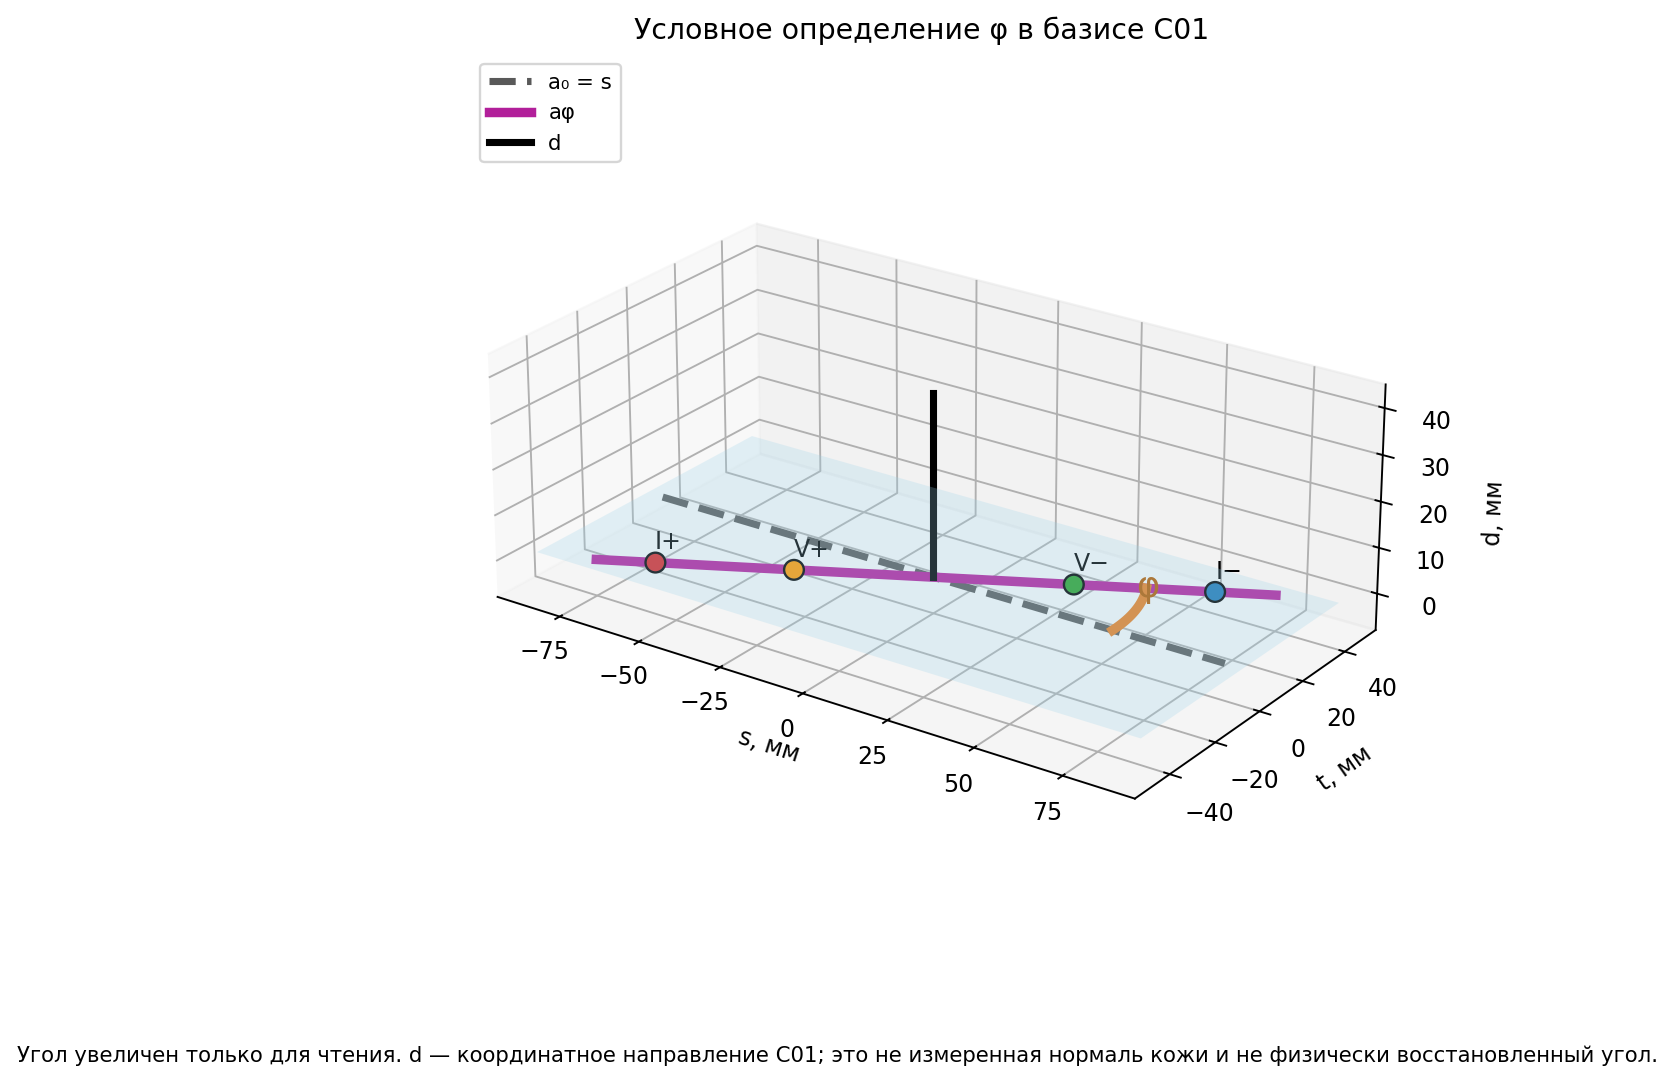

**Рисунок 3.2. Определение угла поворота в локальном базисе C01.** Показаны исходное направление $s$, поперечное направление $t$ и повёрнутая ось $\mathbf a_\varphi=\cos\varphi\,\mathbf s+\sin\varphi\,\mathbf t$. Угол отсчитывается внутри плоскости $s,t$; направление $d$ перпендикулярно этой плоскости. Координаты схемы выражены в миллиметрах.

Угол условно увеличен для чтения рисунка. Он не является измеренным углом установки или результатом исторической подгонки. Базис взят из расчётного описания C01; схема определяет параметризацию, но сама по себе не подтверждает физическую нормаль кожи. Фактические центроиды контактов и их отклонения от продольной плоскости проверяются отдельно в разделе 4.

In [ ]:
def sampled_mesh_trace(tri, max_faces, name, color, opacity):
    count = len(tri)
    take = np.linspace(0, count - 1, min(count, max_faces), dtype=int)
    selected = tri[take]
    points, inverse = np.unique(selected.reshape(-1, 3), axis=0, return_inverse=True)
    faces = inverse.reshape(-1, 3)
    return go.Mesh3d(
        x=points[:, 0], y=points[:, 1], z=points[:, 2],
        i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
        name=name, color=color, opacity=opacity,
        flatshading=False, hoverinfo='name', lighting=dict(
            ambient=0.68, diffuse=0.72, specular=0.12, roughness=0.82,
            fresnel=0.05
        ), lightposition=dict(x=-300, y=-200, z=100)
    )

fig3d = go.Figure()
fig3d.add_trace(sampled_mesh_trace(triangles['body'], len(triangles['body']), 'кожа / тело', '#d8c7b6', 0.14))
fig3d.add_trace(sampled_mesh_trace(triangles['lungs'], len(triangles['lungs']), 'лёгкие v3', 'deepskyblue', 0.28))
fig3d.add_trace(sampled_mesh_trace(triangles['heart'], len(triangles['heart']), 'сердце', 'crimson', 0.55))
fig3d.add_trace(sampled_mesh_trace(triangles['bones'], len(triangles['bones']), 'кости', 'ivory', 0.24))

all_xyz = electrodes[['patch_centroid_x_mm', 'patch_centroid_y_mm', 'patch_centroid_z_mm']].to_numpy()
fig3d.add_trace(go.Scatter3d(
    x=all_xyz[:, 0], y=all_xyz[:, 1], z=all_xyz[:, 2], mode='markers',
    marker=dict(size=3, color=electrodes.L_mm, colorscale='Viridis', colorbar=dict(title='L, мм')),
    text=[f'L={L:g}, {e}' for L, e in zip(electrodes.L_mm, electrodes.electrode)],
    hovertemplate='%{text}<br>x=%{x:.1f}, y=%{y:.1f}, z=%{z:.1f}<extra></extra>',
    name='все сборки'
))

grid140 = electrodes[electrodes.L_mm == 140]
p140 = grid140[['patch_centroid_x_mm', 'patch_centroid_y_mm', 'patch_centroid_z_mm']].to_numpy()
fig3d.add_trace(go.Scatter3d(
    x=p140[:, 0], y=p140[:, 1], z=p140[:, 2], mode='markers+text',
    marker=dict(size=7, color=['red', 'orange', 'lime', 'blue']),
    text=grid140.electrode, textposition='top center', name='сборка 140 мм'
))

axis_points = centre + np.array([-85, 85])[:, None] * axis
fig3d.add_trace(go.Scatter3d(
    x=axis_points[:, 0], y=axis_points[:, 1], z=axis_points[:, 2],
    mode='lines', line=dict(color='magenta', width=8), name='общая ось'
))
fig3d.add_trace(go.Scatter3d(
    x=[centre[0]], y=[centre[1]], z=[centre[2]], mode='markers',
    marker=dict(size=8, color='black', symbol='diamond'), name='общий центр'
))

corners = np.array([
    centre - 90 * axis - 15 * inward,
    centre + 90 * axis - 15 * inward,
    centre + 90 * axis + 125 * inward,
    centre - 90 * axis + 125 * inward,
])
fig3d.add_trace(go.Mesh3d(
    x=corners[:, 0], y=corners[:, 1], z=corners[:, 2],
    i=[0, 0], j=[1, 2], k=[2, 3], color='gold', opacity=0.18,
    name='плоскость CT-среза'
))

fig3d.update_layout(
    title='CT/STL-анатомия и положение электродных сборок',
    height=720, margin=dict(l=0, r=0, t=45, b=0),
    scene=dict(
        aspectmode='data',
        xaxis=dict(title='x, мм', range=body_ranges[0]),
        yaxis=dict(title='y, мм', range=body_ranges[1]),
        zaxis=dict(title='z, мм', range=body_ranges[2]),
        camera=dict(eye=dict(x=-1.7, y=-1.4, z=0.7),
                    projection=dict(type='orthographic'))
    )
)
show_plotly(fig3d)
display(Markdown("<!-- revise_2010_prose:figure:fig-3-1-historical-anatomy -->\n\n**Рисунок 3.1. Объёмная сцена исходной локализации и расположение электродных сборок.** На сцене показаны наружная поверхность тела, лёгкие, сердце и кости; цветные точки — центроиды 36 дискретных площадок девяти сборок, а отдельными обозначениями выделены сборка 140 мм, общая ось, центр и вспомогательная плоскость. Координатные оси $x$, $y$ и $z$ заданы в миллиметрах. \n\nФигуру следует читать как контроль масштаба и взаимного положения объектов. Она относится к историческому кандидату, использованному в разделах 1–10; этот кандидат отличается от C01 раздела 20 и не является изображением текущей окончательной позы. Проекция центроида на поверхность и полный набор граничных граней контакта могут различаться. Поэтому фигура не подтверждает фактическую наклейку электродов и не задаёт точность локализации. Текущий C01 и его координаты приведены отдельно в разделе 20."))

# revise_2010_pem: c01_phi_definition
from pathlib import Path
import sys
_phi_project = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p/'MATLAB_TRKG4_real_subjects').is_dir())
_phi_modules = str(_phi_project/'MATLAB_TRKG4_real_subjects/notebooks')
if _phi_modules not in sys.path:
    sys.path.insert(0,_phi_modules)
from revise_2010_pem import display_phi_definition
display_phi_definition()


<a id="search-region-c01"></a>
### 3.1. Фактически заданная область поиска и выполненная её часть

Для чтения последующих результатов сначала необходимо отделить область, в которой поиск был задан, от положений, для которых сохранился допустимый расчёт. Здесь используется тот же остановленный перебор, который анализируется в разделе 20:

$$u\in[-80,80]\ \mathrm{мм},\qquad v\in[-120,120]\ \mathrm{мм},\qquad
\varphi\in[-20^\circ,20^\circ].$$

Шаги равны 1 мм по каждой координате и 1° по углу. Это 161 × 241 = 38 801 параметрический центр и 1 590 841 поза «центр–угол». Координаты $u,v$ задают сетку поиска; физическое положение центра после проекции на кожу задаётся сохранёнными координатами $x,y,z$. На рисунке используются именно эти координаты. Повторного проецирования на ближайшие вершины STL нет. Различные узлы параметрической сетки могут совпадать в пространстве.

Для 475 090 поз сохранён электрический расчёт; 95 192 отклонены проверкой геометрии контактов, 216 918 исключены маской поверхности, а 803 641 ещё не проверены. В последней категории нет данных об ошибке импеданса. Поэтому вся заданная область не может считаться исследованной.

На обеих панелях показаны статусы при одном угле $\varphi=14^\circ$. Левая панель представляет параметрическую сетку, правая — те же центры в координатах КТ. Для других углов допустимость контактов может изменяться. Таблица после рисунка относится ко всем 41 углу; её числа не являются числом точек отдельной панели.

Звезда обозначает C01: $u=13$ мм, $v=-55$ мм, $\varphi=14^\circ$, центр $(-187{,}5;\ 31{,}051379;\ -138{,}051379)$ мм. Это минимум ошибки относительно эксперимента среди рассчитанных допустимых поз при фиксированных сопротивлениях. Совпадение с фактической наклейкой электродов и оптимальность при совместном изменении сопротивлений не установлены. Проверка минимума и его устойчивости приведена в разделе 20.

Предшествующий объёмный рисунок показывает исторический локальный результат другой процедуры. Его положение и система параметров не используются для задания этой области. После фиксации текущего кандидата можно проверить, какую анатомию пересекает продольная плоскость его сборки.

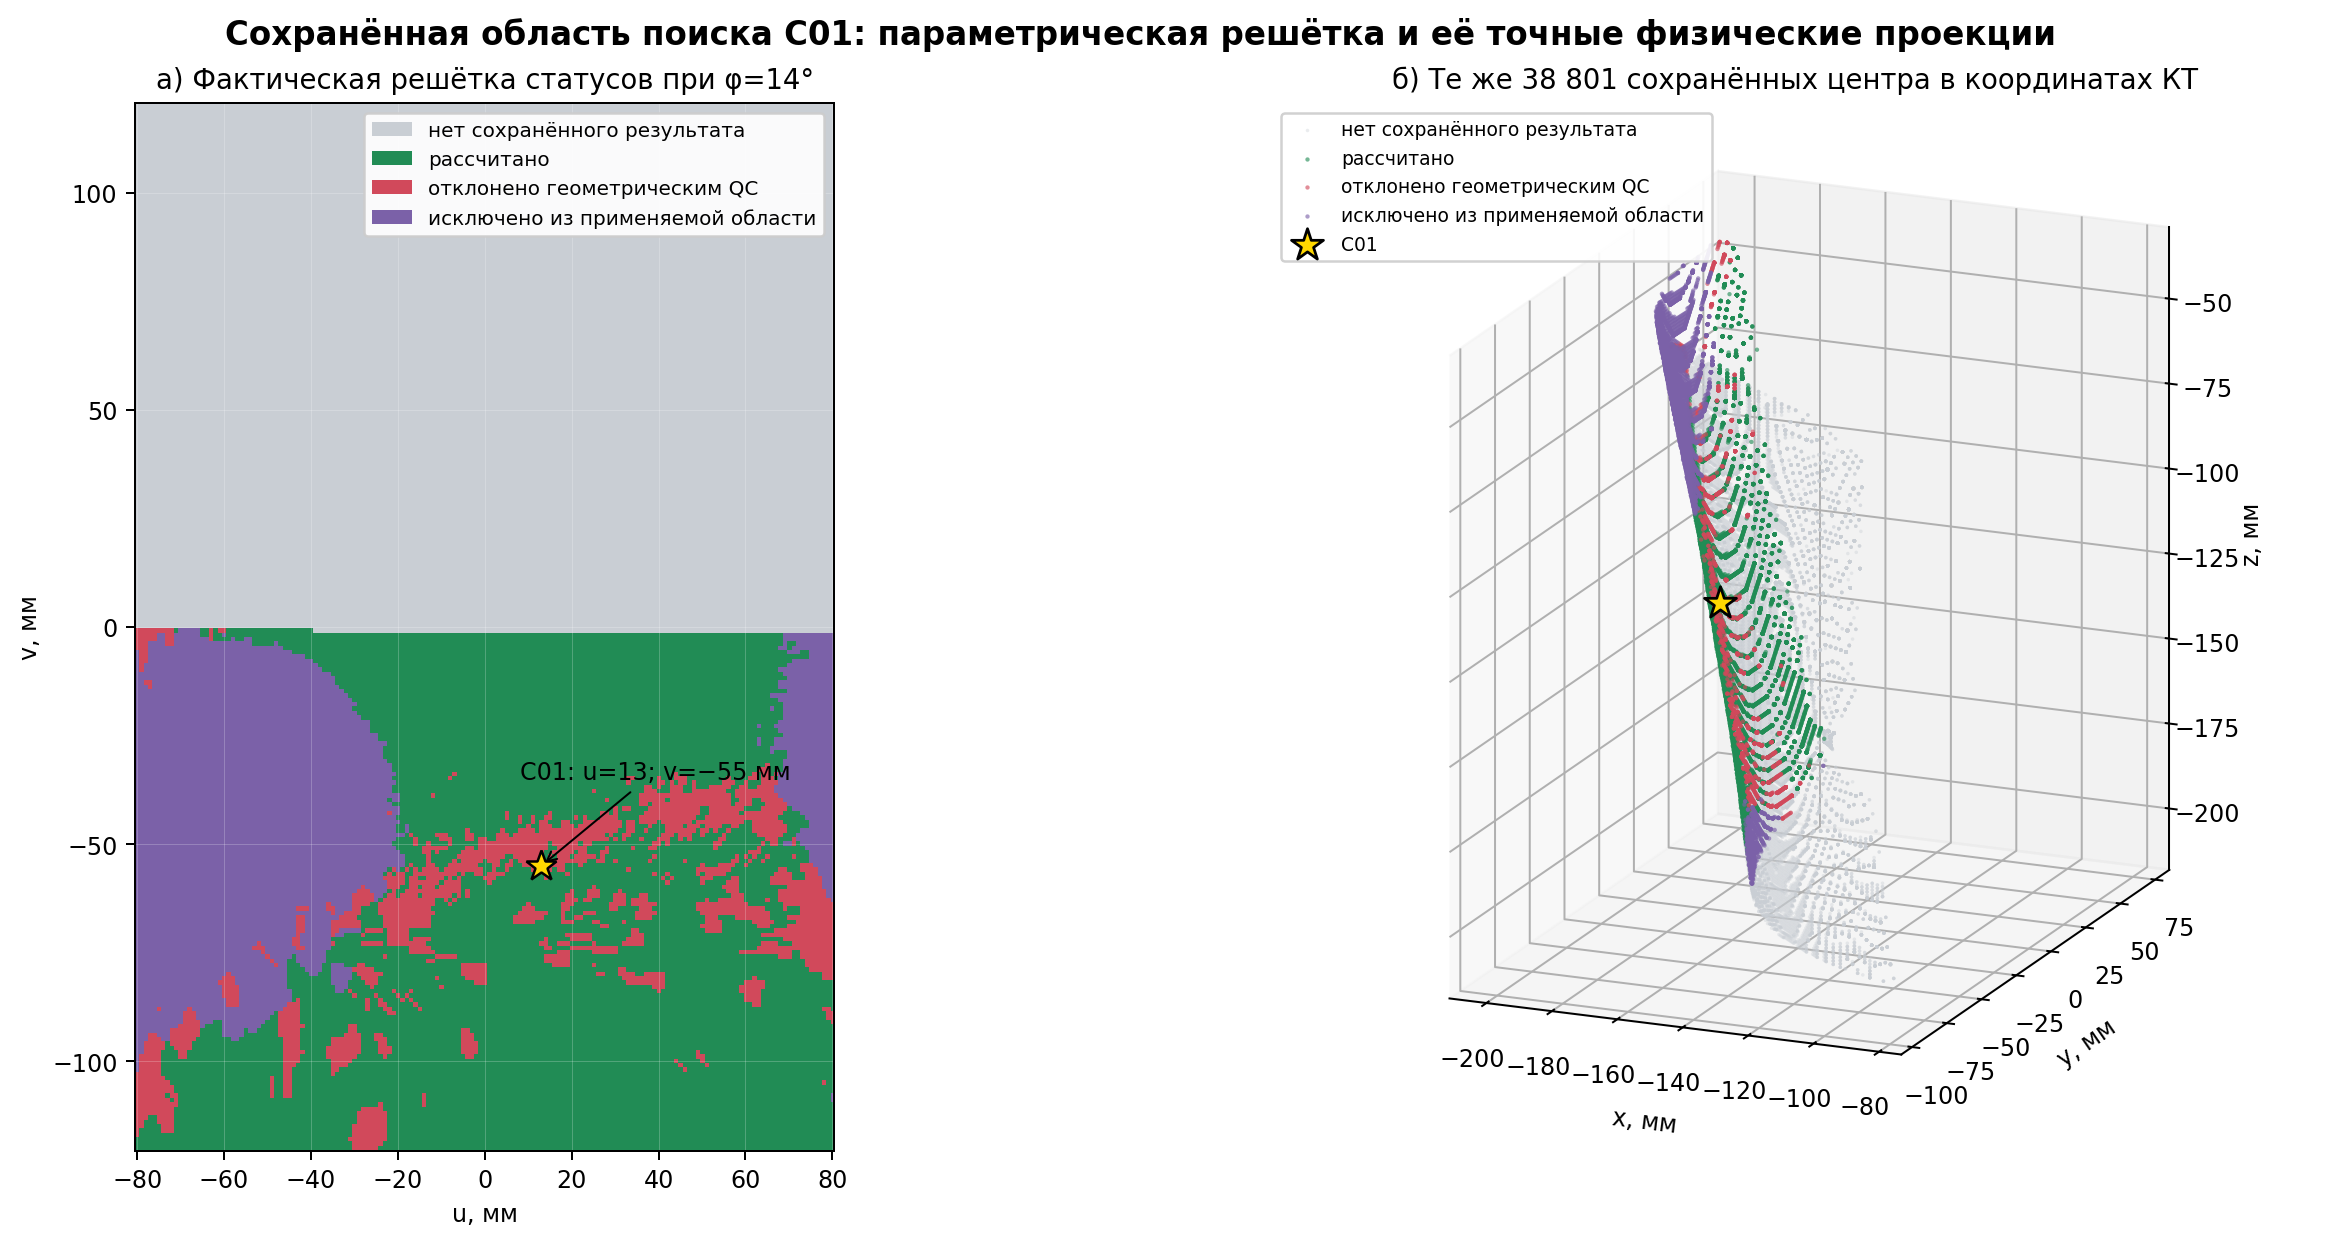

**Рисунок 3.3. Одна сохранённая область поиска в параметрических и физических координатах.** Слева показаны статусы узлов $(u,v)$ при $\varphi=14^\circ$; справа — их сохранённые проекции в системе КТ. Все координатные оси выражены в миллиметрах. Цвет обозначает категорию расчёта, а не ошибку импеданса: зелёный — рассчитанная поза, красный — отказ проверки контактов, фиолетовый — исключение маской поверхности, серый — отсутствие выполненной проверки.

Полезно сопоставлять границы цветных областей и положение звезды C01. Неправильная форма облака справа возникает при отображении параметрической сетки на поверхность тела; она не задаёт новую область поиска. Совпадающие проекции накладываются друг на друга. Ни цвет, ни плотность точек не являются вероятностью положения или картой чувствительности. В разделе 20 используется эта же сетка, но цветом показаны электрические критерии и, в некоторых панелях, минимум по углам.

**Проверка входа рисунка.**

| параметр | диапазон / размер | смысл |
| --- | --- | --- |
| u | -80 … 80 мм | 161 значений, шаг 1 мм |
| v | -120 … 120 мм | 241 значение, шаг 1 мм |
| φ | -20 … 20° | 41 значение, шаг 1° |
| центры | 38801 | точные сохранённые проекции |
| позы | 1 590 841 | полная решётка centre×φ |

| статус | число поз |
| --- | --- |
| нет сохранённого результата | 803641 |
| рассчитано | 475090 |
| отклонено геометрическим QC | 95192 |
| исключено из применяемой области | 216918 |

In [ ]:
# Геометрическая визуализация из сохранённых данных; FEM и новый поиск не запускаются.
from pathlib import Path
import sys

_revision_project = next(
    p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (p / "MATLAB_TRKG4_real_subjects").is_dir()
)
_revision_notebooks = _revision_project / "MATLAB_TRKG4_real_subjects" / "notebooks"
if str(_revision_notebooks) not in sys.path:
    sys.path.insert(0, str(_revision_notebooks))
from revise_2010_geometry import display_revision_asset

display_revision_asset("search")


<a id="electrode-section-c01"></a>
## 4. Продольное сечение по контактам текущей сборки C01

После задания области поиска необходимо проверить, как выбранная сборка располагается относительно кожи и лёгкого. Для этого строится один продольный срез по четырём сохранённым центроидам конечных контактов сборки $L=140$ мм. Это контакты численной CEM-модели; независимое измерение их фактического положения на теле отсутствует.

Четыре центроида на кривой поверхности не обязаны лежать в одной плоскости. Поэтому правило построения задаётся явно. Пусть $\mathbf r_{I+}$ и $\mathbf r_{I-}$ — центроиды токовых контактов. Выбираются середина хорды и единичное направление от $I-$ к $I+$:

$$
\mathbf p=\frac{\mathbf r_{I+}+\mathbf r_{I-}}2,\qquad
\mathbf a_0=\frac{\mathbf r_{I+}-\mathbf r_{I-}}
{\|\mathbf r_{I+}-\mathbf r_{I-}\|}.
$$

Для четырёх контактов сохранены локальные наружные нормали кожи $\mathbf n_e$. Их среднее задаёт направление внутрь $\mathbf b$. Проекция хорды на перпендикулярное ему направление задаёт продольную ось $\mathbf a$:

$$
\mathbf b=-\frac{\sum_e\mathbf n_e}{\|\sum_e\mathbf n_e\|},\qquad
\mathbf a=\frac{\mathbf a_0-(\mathbf a_0\cdot\mathbf b)\mathbf b}
{\|\mathbf a_0-(\mathbf a_0\cdot\mathbf b)\mathbf b\|},\qquad
\mathbf n_\Pi=\mathbf a\times\mathbf b .
$$

Плоскость натянута на хорду токовых контактов и среднее направление внутрь. Усреднение локальных нормалей — выбранное правило визуализации, а не независимое измерение нормали всей грудной стенки. Координаты среза обозначены $\tilde s,\tilde d$, чтобы отличить их от расчётного базиса $s,t,d$ в 20.16:

$$\mathbf r_\Pi=\mathbf p+\tilde s\,\mathbf a+\tilde d\,\mathbf b,\qquad
\ell_e=(\mathbf r_e-\mathbf p)\cdot\mathbf n_\Pi.$$

Здесь $\ell_e$ — знаковое расстояние центроида до плоскости, мм. Для $I+$ и $I-$ оно равно нулю по построению. Для потенциальных контактов получено $\ell(V+)=+0{,}332$ мм и $\ell(V-)=-1{,}819$ мм. Максимальное абсолютное отклонение равно 1,819 мм. Следовательно, изображать все четыре контакта как точно лежащие в срезе было бы неправильно.

В трёхмерной панели показаны центроиды, их проекции и плоскость. На двумерной панели цветные точки являются проекциями центроидов; контуры получены пересечением исходных STL-поверхностей этой плоскостью. Сердце и кости оставлены как анатомические ориентиры. В двухтканной электрической постановке они входят в общий фон $\rho_1$, а лёгкое имеет $\rho_2$.

Начало и направления этого иллюстративного среза отличаются от расчётного базиса 20.16. Подписанные расстояния относятся только к лучам данного рисунка. Направленная центральная толщина $h(0)=67{,}00$ мм, маски, контакты и рассчитанные импедансы 20.16 сохраняются. По срезу можно увидеть геометрическую неоднородность, но точность её электрического приближения проверяется отдельным сравнением операторов в разделе 11.4.

In [ ]:
def plane_segments(tri, point, normal, basis_s, basis_d, tolerance=1e-7):
    signed = np.einsum('fvi,i->fv', tri - point, normal)
    candidate = tri[(signed.min(axis=1) <= tolerance) & (signed.max(axis=1) >= -tolerance)]
    candidate_signed = signed[(signed.min(axis=1) <= tolerance) & (signed.max(axis=1) >= -tolerance)]
    segments = []
    for face, distances in zip(candidate, candidate_signed):
        hits = []
        for i, j in ((0, 1), (1, 2), (2, 0)):
            di, dj = distances[i], distances[j]
            if abs(di) <= tolerance:
                hits.append(face[i])
            if di * dj < 0:
                t = di / (di - dj)
                hits.append(face[i] + t * (face[j] - face[i]))
        if len(hits) < 2:
            continue
        unique = np.unique(np.round(np.asarray(hits), 6), axis=0)
        if len(unique) < 2:
            continue
        if len(unique) > 2:
            distances_pair = np.linalg.norm(unique[:, None] - unique[None, :], axis=2)
            i, j = np.unravel_index(np.argmax(distances_pair), distances_pair.shape)
            unique = unique[[i, j]]
        relative = unique - point
        segments.append(np.column_stack((relative @ basis_s, relative @ basis_d)))
    return segments

s_grid = np.linspace(-95, 95, 381)
d_grid = np.linspace(-20, 135, 311)
S, D = np.meshgrid(s_grid, d_grid)
points = centre + S[..., None] * axis + D[..., None] * inward
if hu_interpolator is None:
    oblique_hu = None
else:
    queries = np.column_stack((
        points.reshape(-1, 3) @ direction_slices,
        points.reshape(-1, 3) @ direction_rows,
        points.reshape(-1, 3) @ direction_columns,
    ))
    oblique_hu = hu_interpolator(queries).reshape(D.shape)

section_segments = {
    key: plane_segments(value, centre, plane_normal, axis, inward)
    for key, value in triangles.items()
}

def contour_intersections_at_s(segments, s_value):
    depths = []
    for segment in segments:
        x0, y0 = segment[0]
        x1, y1 = segment[1]
        if (x0 - s_value) * (x1 - s_value) > 0 or abs(x1 - x0) < 1e-9:
            continue
        fraction = (s_value - x0) / (x1 - x0)
        if -1e-8 <= fraction <= 1 + 1e-8:
            depths.append(y0 + fraction * (y1 - y0))
    return np.asarray(depths)

def unique_sorted_depths(values, minimum_separation=1e-3):
    '''Collapse duplicate STL edge hits while retaining distinct branches.'''
    ordered = np.sort(np.asarray(values, dtype=float))
    ordered = ordered[np.isfinite(ordered)]
    if len(ordered) == 0:
        return ordered
    unique = [ordered[0]]
    for value in ordered[1:]:
        if value - unique[-1] > minimum_separation:
            unique.append(value)
    return np.asarray(unique)

# h in the displayed plane: choose the skin crossing nearest d=0 and the
# first lung crossing deeper than that skin point.
s_profile = np.arange(-80.0, 80.1, 2.0)
skin_profile = np.full_like(s_profile, np.nan)
lung_profile = np.full_like(s_profile, np.nan)
lung_crossings_by_s = []
for index, s_value in enumerate(s_profile):
    skin_hits = contour_intersections_at_s(section_segments['body'], s_value)
    if len(skin_hits) == 0:
        lung_crossings_by_s.append(np.asarray([], dtype=float))
        continue
    skin_profile[index] = skin_hits[np.argmin(np.abs(skin_hits))]
    lung_hits = contour_intersections_at_s(section_segments['lungs'], s_value)
    deeper = unique_sorted_depths(
        lung_hits[lung_hits > skin_profile[index] + 1.0])
    lung_crossings_by_s.append(deeper)
    if len(deeper):
        lung_profile[index] = deeper.min()
max_lung_branches = max((len(values) for values in lung_crossings_by_s), default=0)
lung_branch_profiles = np.full(
    (len(s_profile), max_lung_branches), np.nan, dtype=float)
for index, values in enumerate(lung_crossings_by_s):
    lung_branch_profiles[index, :len(values)] = values
h_plane = lung_profile - skin_profile
# This is a geometric skin-to-first-lung-boundary distance in the selected
# plane.  It is not a soft-tissue thickness unless every intervening tissue
# class has been explicitly segmented and removed from the path.
bone_crossings_by_s = []
for index, s_value in enumerate(s_profile):
    if not (np.isfinite(skin_profile[index]) and np.isfinite(lung_profile[index])):
        bone_crossings_by_s.append(np.asarray([], dtype=float))
        continue
    bone_hits = unique_sorted_depths(
        contour_intersections_at_s(section_segments['bones'], s_value))
    bone_crossings_by_s.append(bone_hits[
        (bone_hits > skin_profile[index] + 1.0)
        & (bone_hits < lung_profile[index] - 1.0)])
bone_path_flags = np.array([len(values) > 0 for values in bone_crossings_by_s])

projected140 = p140 - centre
electrode_s = projected140 @ axis
electrode_d = projected140 @ inward
electrode_lateral = projected140 @ plane_normal
skin_d_at_electrode_s = np.interp(electrode_s, s_profile, skin_profile)
h_plane_at_electrode_s = np.interp(electrode_s, s_profile, h_plane)
nearest_lung_from_patch = np.array([
    np.min(np.linalg.norm(lung_points - point, axis=1)) for point in p140
])


# revise_2010_geometry: legacy section calculations preserved; old STL/DICOM figure not rendered.
# The variables section_segments, electrode_s, electrode_d, h_plane and
# electrode_plane_table remain available to historical cells.

electrode_plane_table = pd.DataFrame({
    'электрод': grid140.electrode.to_numpy(),
    's проекции, мм': electrode_s,
    'd проекции, мм': electrode_d,
    'ℓ вне плоскости, мм': electrode_lateral,
    'd кожи в плоскости, мм': skin_d_at_electrode_s,
    'расстояние кожа–лёгкое в плоскости, мм': h_plane_at_electrode_s,
    'кость между кожей и лёгким в плоскости': np.interp(
        electrode_s, s_profile, bone_path_flags.astype(float)) > 0.5,
    '3D min до лёгкого от центроида, мм': nearest_lung_from_patch,
})

### 4.1. Что сечение позволяет установить

Плоскость через токовые контакты позволяет сопоставить продольное изменение анатомических границ и проверить отклонения потенциальных контактов. Она не описывает поперечную форму лёгкого и не задаёт область чувствительности. Электрическое сравнение должно использовать объёмные маски и согласованные условия на электродах.

Следующие разделы 5–10 сохраняют ход исследования раннего локального кандидата: определения толщины, обратную задачу и её численные ограничения. Их профили и параметры относятся к тому историческому положению, которое показано на рисунке 3.1. Текущее прямое сравнение C01 находится в разделе 11.4, а выбор C01 из сохранённого перебора — в разделе 20. Такое разделение необходимо, чтобы выводы старой инверсии не приписывались новой геометрии.

In [ ]:
stl_fig, stl_ax = plt.subplots(figsize=(13, 8), facecolor='#101820')
stl_ax.set_facecolor('#101820')
stl_colors = {'body': '#ffd400', 'lungs': '#00e5ff', 'heart': '#ff4055', 'bones': '#ffffff'}
stl_widths = {'body': 3.8, 'lungs': 2.8, 'heart': 2.4, 'bones': 1.8}
stl_labels = {'body': 'наружная поверхность тела', 'lungs': 'лёгкие v3',
              'heart': 'сердце', 'bones': 'кости'}
for key in ('body', 'lungs', 'heart', 'bones'):
    stl_ax.add_collection(LineCollection(
        section_segments[key], colors=stl_colors[key], linewidths=stl_widths[key],
        label=stl_labels[key], zorder=2 if key == 'body' else 3
    ))

electrode_colors = ['#ff3b30', '#ff9500', '#34c759', '#0a84ff']
stl_ax.scatter(electrode_s, electrode_d, s=90, c=electrode_colors,
               edgecolor='black', linewidth=0.8, zorder=7, label='проекции электродов')
stl_ax.scatter(electrode_s, skin_d_at_electrode_s, s=90, marker='x', c='#ffd400',
               linewidths=2.5, zorder=8, label='кожа при том же s')
for x, y_projected, y_skin, label in zip(
        electrode_s, electrode_d, skin_d_at_electrode_s, grid140.electrode):
    stl_ax.plot([x, x], [y_projected, y_skin], color='#ffd400', ls='--', lw=1.2, alpha=0.9)
    stl_ax.annotate(label, (x, y_projected), xytext=(5, -14), textcoords='offset points',
                    color='white', weight='bold', zorder=9)

for s_mark in (-60, -30, 0, 30, 60):
    index = np.argmin(np.abs(s_profile - s_mark))
    if np.isfinite(h_plane[index]):
        stl_ax.plot([s_profile[index], s_profile[index]],
                    [skin_profile[index], lung_profile[index]], color='#39ff14', lw=3.0, zorder=6)
        stl_ax.text(s_profile[index] + 1.8,
                    0.5 * (skin_profile[index] + lung_profile[index]),
                    f'h={h_plane[index]:.1f} мм', color='#39ff14', fontsize=9,
                    rotation=90, va='center', zorder=9)

stl_ax.axhline(0, color='#ff2dff', ls=':', lw=1.2, label='центр / касательная кожи')
stl_ax.set_xlim(-95, 95)
stl_ax.set_ylim(135, -20)
stl_ax.set_aspect('equal', adjustable='box')
stl_ax.set_xlabel('$s$ вдоль общей оси электродов, мм', color='white')
stl_ax.set_ylabel('$d$ от кожи внутрь, мм', color='white')
stl_ax.set_title('STL-срез в плоскости электродов — геометрия, используемая FEM',
                 color='white', weight='bold')
stl_ax.tick_params(colors='white')
for spine in stl_ax.spines.values():
    spine.set_color('#b0bec5')
legend = stl_ax.legend(loc='lower right', ncol=2, facecolor='#18242e',
                       edgecolor='#b0bec5', framealpha=0.95)
for text_item in legend.get_texts():
    text_item.set_color('white')
stl_fig.tight_layout()

# revise_2010_geometry: old STL rendering closed; current figure is in §4.
plt.close(stl_fig)


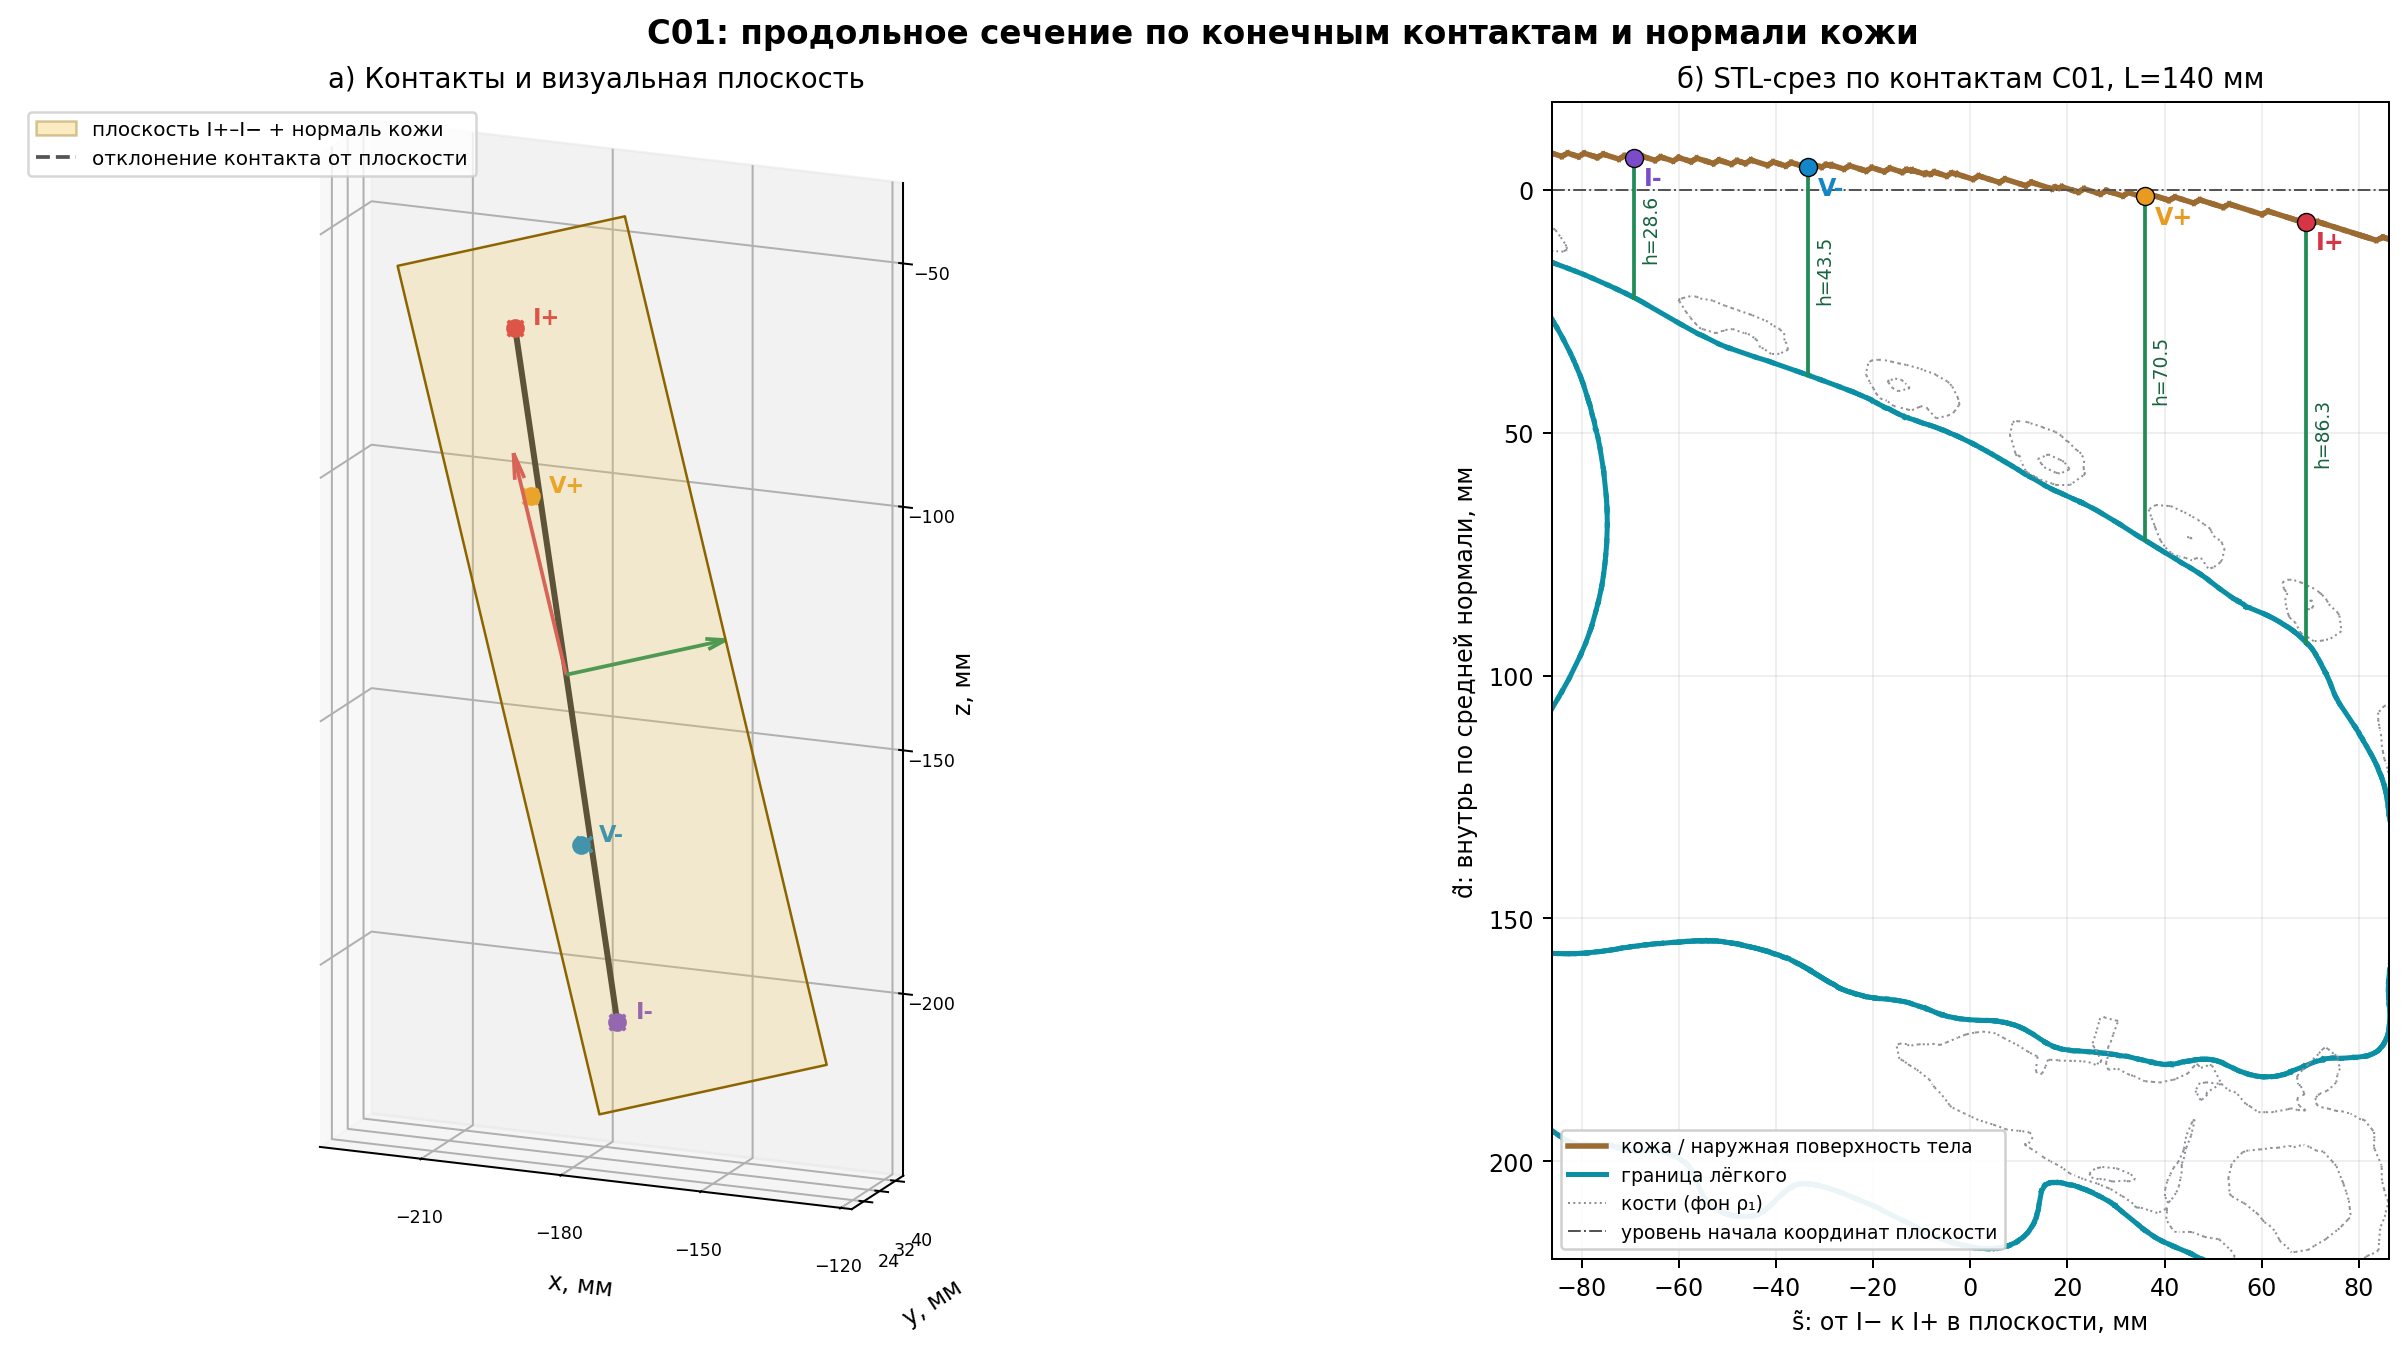

**Рисунок 4.1. Продольная плоскость и пересечение анатомических поверхностей для C01, $L=140$ мм.** Слева показаны центроиды конечных контактов, плоскость через токовые контакты и её локальные направления; пунктир соединяет потенциальные контакты с проекциями. Справа представлены контуры кожи, лёгкого, сердца и костей в этой же плоскости. Ось $\tilde s$ направлена от $I-$ к $I+$ после ортогонализации; $\tilde d$ — внутрь по средней локальной нормали. Координаты и подписанные расстояния выражены в миллиметрах.

Зелёные отрезки показывают расстояние от кожи до первого пересечения лёгкого вдоль выбранного направления. Следует сравнивать эти расстояния вдоль сборки и обращать внимание на дополнительные пересечения замкнутого лёгочного объёма. Одно постоянное $h$ такую геометрию полностью не описывает. Вместе с тем расстояние кожа–лёгкое может включать кости и другие ткани; оно не является измерением толщины одних мышц.

Отклонение потенциальных контактов от плоскости достигает 1,819 мм; это свойство сохранённой модели контактов, а не оценка ошибки экспериментальной наклейки. По одной плоскости нельзя установить распределение тока или величину вклада органов. Поэтому срез обосновывает геометрический вопрос, а ответ о точности импеданса и обратного восстановления требует последующих электрических расчётов.

Для чтения контактов слева показан небольшой фрагмент плоскости. Справа изображён участок до глубины 220 мм; нижний край окна является только границей изображения и не означает окончания лёгкого или расчётной области.

**Отклонения центроидов от визуальной плоскости.**

| электрод | s̃, мм | d̃, мм | ℓ, мм | abs(ℓ), мм |
| --- | --- | --- | --- | --- |
| I+ | 69.178 | 6.579 | -0.000 | 0.000 |
| V+ | 35.968 | 1.272 | +0.332 | 0.332 |
| V- | -33.386 | -4.665 | -1.819 | 1.819 |
| I- | -69.178 | -6.579 | +0.000 | 0.000 |

Максимум |ℓ| = **1.819 мм**; h(0) расчётной модели = **67.00 мм** и не изменён.

In [ ]:
# Геометрическая визуализация из сохранённых данных; FEM и новый поиск не запускаются.
from pathlib import Path
import sys

_revision_project = next(
    p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (p / "MATLAB_TRKG4_real_subjects").is_dir()
)
_revision_notebooks = _revision_project / "MATLAB_TRKG4_real_subjects" / "notebooks"
if str(_revision_notebooks) not in sys.path:
    sys.path.insert(0, str(_revision_notebooks))
from revise_2010_geometry import display_revision_asset

display_revision_asset("section")


## 5. Геометрические расстояния и электрически эффективная толщина

### 5.1. Определения расстояний

В сечении определяются координаты наружной поверхности и первого лёгочного пересечения. Их разность равна

$$
h_\Pi(s)=d_{\mathrm{л},1}(s)-d_{\mathrm{к}}(s),
$$
где $h_\Pi$ — расстояние кожа–лёгкое вдоль принятого направления сечения, мм; $d_{\mathrm{л},1}$ — глубинная координата первого лёгочного пересечения; $d_{\mathrm{к}}$ — координата кожи; $s$ — положение вдоль оси. Данное расстояние может содержать кость в анатомической классификации исходной модели.

Дополнительно рассматриваются расстояние по внутренней нормали кожи и ближайшее трёхмерное расстояние:

$$
h_{\mathrm{н}}(s)=\inf\{t>0:\mathbf r_{\mathrm{к}}(s)-t\mathbf n_{\mathrm{к}}(s)\in\partial\Omega_{\mathrm{л}}\},
\qquad
h_{\mathrm{б}}(s)=\min_{\mathbf q\in\partial\Omega_{\mathrm{л}}}\|\mathbf r_{\mathrm{к}}(s)-\mathbf q\|,
$$
где $\mathbf r_{\mathrm{к}}$ — точка кожи; $\mathbf n_{\mathrm{к}}$ — внешняя единичная нормаль кожи; $t$ — положительная длина луча; $\partial\Omega_{\mathrm{л}}$ — граница лёгкого; $\mathbf q$ — точка на этой границе. Обе величины выражены в миллиметрах. При отсутствии пересечения нормального луча конечное значение ему не назначается.

Ближайшее расстояние не задаёт толщину вдоль произвольного фиксированного луча. Вблизи купола или края лёгкого луч может пройти вдоль поверхности, войти в неё на большой глубине либо не пересечь её. Поэтому выбросы лучевого расстояния требуют геометрической интерпретации и не должны автоматически сглаживаться как измерительный шум.

Отдельно различаются расстояние от центра до ближайшей вершины STL и расстояние до ближайшей точки треугольника. В реализованном априорном штрафе используется первое. Второе служит более точной геометрической диагностикой. В рассматриваемом кандидате они составляют приблизительно 30,485 и 30,430 мм соответственно; центральный луч сечения даёт другую величину — около 30,897 мм.

### 5.2. Аппроксимация профиля

Профиль, полученный из выбранного сечения и используемый как диагностический вход редуцированной модели, аппроксимируется полиномом четвёртой степени по безразмерной координате:

$$
h_{\mathrm{апр}}(s)=\sum_{j=0}^{4}c_j\left(\frac{s}{70\ \text{мм}}\right)^j,
$$
где $h_{\mathrm{апр}}$ — сглаженный профиль, мм; $c_j$ — коэффициенты, мм; $j$ — степень полинома; $s$ — координата в пределах исследуемого интервала от −70 до 70 мм. Коэффициенты вычисляются по сечению методом итеративно взвешенных наименьших квадратов с уменьшением влияния больших остатков.

Порядок полинома является рабочим выбором. Ошибка его приближения к профилю оценивает только потерю информации при сглаживании данного сечения. Она не равна ошибке сегментации, электрического расчёта или оценки толщины у пациента. Экстраполяция за исследованный интервал не обоснована.

### 5.3. Электрически эффективная толщина

Эффективную толщину следует определять через выбранный критерий электрической эквивалентности:

$$
h_{\mathrm{эфф}}=\operatorname*{arg\,min}_{h\in\mathcal H}
\sum_{i\in\mathcal L}w_i\bigl[Z_{\mathrm{сл}}(L_i;\rho_1,\rho_2,h)-Z_{\mathrm{оп}}(L_i)\bigr]^2,
$$
где $\mathcal H$ — допустимые толщины; $\mathcal L$ — выбранный набор размеров; $w_i$ — заданные неотрицательные веса; $Z_{\mathrm{сл}}$ — импеданс слоистой модели; $Z_{\mathrm{оп}}$ — опорный импеданс; $\rho_1,\rho_2$ — фиксированные сопротивления. Эта формула задаёт предлагаемую идентификационную задачу и сама по себе не означает её решения в текущем отчёте.

В общем случае эффективная толщина зависит от состава размеров, тканевого контраста, контактов и способа взвешивания. Её равенство анатомическому расстоянию является отдельной гипотезой. При одновременном подборе сопротивлений и толщины необходимо проверять возможность их взаимной компенсации.

In [ ]:
valid_plane = np.isfinite(h_plane) & (s_profile >= -70) & (s_profile <= 70)
s_valid = s_profile[valid_plane]
h_valid = h_plane[valid_plane]
t_valid = s_valid / 70.0

# Robust iteratively reweighted fourth-degree fit. This prevents a single
# contour ambiguity from controlling the reduced h(s) approximation.
design = np.column_stack([t_valid ** power for power in range(5)])
weights = np.ones(len(h_valid))
for _ in range(12):
    weighted_design = design * np.sqrt(weights)[:, None]
    weighted_h = h_valid * np.sqrt(weights)
    coefficients = np.linalg.lstsq(weighted_design, weighted_h, rcond=None)[0]
    residual_fit = h_valid - design @ coefficients
    robust_scale = max(1.4826 * np.median(np.abs(residual_fit - np.median(residual_fit))), 0.25)
    scaled = np.abs(residual_fit) / (1.5 * robust_scale)
    weights = np.where(scaled <= 1, 1.0, 1.0 / scaled)

s_dense = np.linspace(-70, 70, 401)
t_dense = s_dense / 70.0
h_approx = np.polynomial.polynomial.polyval(t_dense, coefficients)
h_at_samples = np.polynomial.polynomial.polyval(t_valid, coefficients)
h_fit_rmse = np.sqrt(np.mean((h_at_samples - h_valid) ** 2))

terms = [f'{coefficients[0]:.3f}']
for power, coefficient in enumerate(coefficients[1:], start=1):
    terms.append(f'{coefficient:+.3f}t^{power}')
display(Markdown(
    '$$h_{approx}(s)=' + ''.join(terms) +
    r',\qquad t=s/70,$$' +
    f'\n\nгде аппроксимируемая глубина и коэффициенты имеют единицы миллиметров, $s$ — продольная координата в миллиметрах, $t$ — безразмерная координата. RMSE аппроксимации расстояния кожа–лёгкое на показанном срезе: **{h_fit_rmse:.3f} мм**.'
))

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(s_profile, h_plane, 'o-', ms=3.5, color='tab:green',
        label='$d_{skin\to lung}$: между контурами на DICOM/STL-срезе')
ax.plot(depth.axis_s_mm, depth.h_inward_ray_mm, 'o', alpha=0.35,
        label='$h_{ray}$: локальная нормаль кожи (диагностика)')
ax.plot(depth.axis_s_mm, depth.h_nearest_lung_mm, 's--', ms=3, alpha=0.55,
        label='$h_{near}$: ближайшая точка (диагностика)')
ax.plot(s_dense, h_approx, 'k-', lw=2.4, label='робастный полином 4-й степени')
for L in sorted(comparison.L_mm.unique()):
    ax.axvline(-L / 2, color='gray', alpha=0.05)
    ax.axvline(+L / 2, color='gray', alpha=0.05)
ax.set(xlabel='$s$ вдоль общей оси, мм', ylabel='$h(s)$, мм',
       title='Изменение геометрического расстояния кожа–лёгкое')
ax.legend()
fig.tight_layout()

<!-- revise_2010_prose:figure:fig-5-1-thickness-profile -->

**Рисунок 5.1. Профили расстояния от кожи до лёгкого вдоль оси исторического сечения.** По горизонтальной оси отложена продольная координата $s$, мм; по вертикальной — расстояние $h(s)$, мм. Показаны профиль выбранного сечения, диагностические расстояния по локальной нормали кожи и до ближайшей точки лёгкого, а также робастная полиномиальная аппроксимация четвёртой степени. Вертикальные отметки показывают положение границ сборок разных размеров. 

Кривые позволяют увидеть продольную неоднородность и сравнить разные геометрические определения глубины; RMSE полиномиальной аппроксимации 0,558 мм относится только к сглаживанию этого профиля. Расстояние может включать кость и не является автоматически толщиной мягких тканей или электрически эффективной толщиной. Профиль используется далее как вход эвристических слоистых приближений, а их электрическая эквивалентность проверяется по импедансу.


## 6. Включение анатомии в трёхмерную прямую задачу

В конечноэлементной модели расстояние до лёгкого не подставляется как самостоятельное число. Материальная принадлежность каждого тетраэдра определяет коэффициент уравнения проводимости. На этой пространственной структуре решается задача с заданными контактами, после чего извлекается разность электродных потенциалов.

Для фиксированной сетки объёмная матрица двухтканной модели представима в виде

$$
K(\rho_1,\rho_2)=\frac1{\rho_1}K_1+\frac1{\rho_2}K_2,
$$
где $K_j$ — матрица интегралов скалярных произведений градиентов базисных функций по области материала $j$ при единичной проводимости; $K$ — объёмная матрица проводимости; $\rho_j$ — удельные сопротивления. Полная система дополнительно содержит контактные блоки и условие фиксации потенциала.

Изменение позы или размера сборки меняет граничные условия и распределение тока во всём объёме. Кривизна кожи, форма лёгкого, его конечность и соседние области участвуют совместно. Профиль одного сечения является диагностическим описанием этой геометрии, но не достаточным входом для восстановления полного трёхмерного оператора.

В двухтканном сравнении принадлежность центров тетраэдров замкнутой лёгочной поверхности определяется отдельно; все остальные элементы получают фоновую проводимость. При таком присвоении тканевая граница аппроксимируется существующей сеткой и не обязана совпадать с каждой гранью тетраэдра. Разница между объёмом STL и объёмом классифицированных элементов является одной из характеристик геометрической дискретизации.

Для будущего ускорения полезно разделить **изменение физической модели** и **изменение способа решения её уравнений**. Замена замкнутого лёгкого полупространством меняет модель. Повторное использование матричной факторизации при неизменной проводимости меняет вычислительный алгоритм. Эти действия имеют разные источники ошибки и должны оцениваться раздельно.

## 7. Обратная задача и регуляризация

Прямая задача принимает геометрию, свойства тканей и токовый монтаж и выдаёт передаточный импеданс $Z(L)$. Обратная задача использует наблюдённые значения $Z(L)$, чтобы оценить неизвестные сопротивления и параметры позы внутри выбранной модели. Поэтому хорошее совпадение прямой кривой ещё не означает, что каждый параметр восстановлен однозначно: разные сочетания сопротивлений и геометрии могут давать близкий набор импедансов. Регуляризация выбирает область таких сочетаний с помощью дополнительных предпочтений; её влияние должно рассматриваться отдельно от остатка по измерениям.

### 7.1. Неизвестные параметры

В исходной четырёхтканной постановке подбирается вектор

$$
\boldsymbol\theta=(\rho_1,\rho_2,u,v,\varphi),\qquad
r_i(\boldsymbol\theta)=Z_{\mathrm{FEM}}(L_i;\boldsymbol\theta)-Z_i^{\mathrm{эксп}},
$$
где $\rho_1,\rho_2$ — сопротивления мягких тканей и лёгкого, Ом·м; $u,v$ — смещения общего центра, мм; $\varphi$ — угол, градусы; $L_i$ — размер сборки; $r_i$ — остаток, Ом; $Z_i^{\mathrm{эксп}}$ — экспериментальный уровень на вдохе; $Z_{\mathrm{FEM}}$ — результат полной электродной модели. Проводимости сердца и костей при этом фиксированы.

Девять значений импеданса связываются общими параметрами. Геометрический профиль вычисляется по выбранной позе на КТ-поверхностях. Добавление самостоятельной ошибки каждого контакта быстро увеличивает число неизвестных; данных данного размерного ряда недостаточно, чтобы оценивать их без дополнительных измерений или ограничений.

### 7.2. Реализованный критерий

Для отдельных остатков используется функция Хьюбера:

$$
H_\delta(r)=\begin{cases}\frac12r^2,&|r|\le\delta,\\
\delta(|r|-\frac12\delta),&|r|>\delta,
\end{cases}
\qquad\delta=5\ \text{Ом},
$$
где $r$ — остаток, Ом; $\delta$ — порог перехода от квадратичного роста к линейному; $H_\delta$ имеет размерность Ом². Порог является рабочим масштабом критерия и не оценён как стандартное отклонение экспериментального шума.

Для корректного указания единиц реализованную сумму удобно записать через численные безразмерные переменные:

$$
\mathcal J=\frac1n\sum_iH_5(r_i^*)+0{,}20[(b_F^*-b_E^*)90]^2
+\left(\frac{h_c^*-15}{7}\right)^2
+2\max(h_c^*-30,0)^2+2\max(7-h_c^*,0)^2
+0{,}25\left(\frac{\rho_2^*-17{,}4067}{6}\right)^2,
$$
где $r_i^*=r_i/(1\ \text{Ом})$; $b_F^*,b_E^*$ — численные значения робастных наклонов расчётной и экспериментальной кривых в Ом/мм; $h_c^*=h_c/(1\ \text{мм})$; $\rho_2^*=\rho_2/(1\ \text{Ом·м})$; $n=9$; $H_5$ — та же функция для безразмерного аргумента. Число 90 соответствует ширине исследуемого диапазона размеров в миллиметрах. Такая запись воспроизводит арифметику кода; она не придаёт весам статистического обоснования.

| Компонента | Назначение | Доказательный статус параметров |
|---|---|---|
| Функция Хьюбера | Согласование отдельных импедансов с ограниченным влиянием больших остатков | Порог выбран как рабочий параметр |
| Разность наклонов | Дополнительное предпочтение общего изменения импеданса по размеру | Вес 0,20 задан эмпирически; наклон рассчитан из тех же девяти наблюдений |
| Мягкий штраф глубины | Предпочтение окрестности исходной визуальной КТ-оценки | Центр 15 мм и ширина 7 мм не являются измеренным распределением ошибки |
| Штраф выхода глубины | Ограничение ухода в существенно иную анатомическую область | Интервал 7–30 мм является сценарным ограничением; это мягкий, а не абсолютный запрет |
| Регуляризация сопротивления лёгкого | Использование модельной оценки по воздушной доле | Значение 17,4067 Ом·м получено с допущениями модели смеси |

Априорная оценка по КТ/HU — **не непосредственно измеренное независимое свойство** лёгкого. Регуляризация может выделить одну вычислительную точку из семейства близких решений. Для оценки влияния априорной информации необходимо изменять её веса и границы, сохраняя раздельно остаток измерений и регуляризационные слагаемые.

### 7.3. Диапазоны и интерпретация результата

В основном поиске сопротивления ограничены интервалами 2–10 и 10–32 Ом·м; геометрические диапазоны заданы в разделе 3.1. Это прямоугольник допустимых параметров алгоритма, а не физиологический диапазон и не доверительный интервал. Значения, полученные на его границе или вне внешнего рабочего диапазона тканей, должны рассматриваться только как диагностические сценарии. Полученный кандидат не сопровождается доказательством глобальной оптимальности или единственности физического решения.

Функция критерия не является установленным отрицательным логарифмом правдоподобия. Гауссовость, независимость и единая дисперсия совокупной ошибки не предполагаются доказанными. Для вероятностной интерпретации необходимы повторные установки, анализ временной вариабельности и отдельное описание модельного расхождения. Далее значения RMS и MAE характеризуют остатки и не заменяют эти исследования.

In [ ]:
parameter_table = pd.DataFrame({
    'параметр': ['$\\rho_1$', '$\\rho_2$', '$u$', '$v$', '$\\varphi$',
                 '$x_c$', '$y_c$', '$z_c$', '$h_c$'],
    'итоговое локальное значение': [summary.rho_soft_ohm_m, summary.rho_lungs_ohm_m,
               summary.centre_u_mm, summary.centre_v_mm, summary.phi_deg,
               summary.centre_x_mm, summary.centre_y_mm, summary.centre_z_mm,
               summary.h_centre_mm],
    'единица': ['Ом·м', 'Ом·м', 'мм', 'мм', 'град', 'мм', 'мм', 'мм', 'мм'],
    'смысл': ['мягкие ткани', 'лёгкое: ткань + воздух', 'смещение по поверхности',
              'смещение по поверхности', 'поворот общей оси', 'CT-координата центра',
              'CT-координата центра', 'CT-координата центра', 'глубина до лёгкого в центре']
})
display(parameter_table)

metric_table = pd.DataFrame({
    'метрика': ['RMS', 'MAE', 'наклон эксперимента', 'наклон FEM',
                'разность наклонов', 'число обусловленности масштабированной матрицы секущих'],
    'значение': [summary.rms_residual_ohm, summary.mae_residual_ohm,
                 summary.experimental_slope_ohm_per_mm, summary.fem_slope_ohm_per_mm,
                 summary.fem_slope_ohm_per_mm - summary.experimental_slope_ohm_per_mm,
                 summary.jacobian_condition_scaled],
    'единица': ['Ом', 'Ом', 'Ом/мм', 'Ом/мм', 'Ом/мм', '—']
})
if not (compute_jacobian and jacobian_step_diagnostics_ok and jacobian_numeric_available):
    metric_table = metric_table.iloc[:5]
display(metric_table)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.plot(comparison.L_mm, comparison.Z_experiment_ohm, 'o-', lw=2, label='эксперимент, вдох')
ax.plot(comparison.L_mm, comparison.Z_FEM_ohm, 's-', lw=2, label=f'CT/FEM: {result_tag}')
ax.set(xlabel='L, мм', ylabel='Z, Ом', title='Измеренный и рассчитанный импеданс')
ax.legend()

ax = axes[0, 1]
colors_residual = np.where(comparison.residual_ohm >= 0, 'tab:red', 'tab:blue')
ax.bar(comparison.L_mm.astype(str), comparison.residual_ohm, color=colors_residual)
ax.axhline(0, color='black', lw=1)
ax.set(xlabel='L, мм', ylabel='$Z_{FEM}-Z_{exp}$, Ом', title='Остатки по каждой сборке')

ax = axes[1, 0]
ax.plot(grids.L_nominal_mm, grids.I_to_I_actual_mm, 'o-', label='I−I на сетке')
ax.plot(grids.L_nominal_mm, grids.L_nominal_mm, 'k--', label='I−I номинально')
ax.plot(grids.L_nominal_mm, grids.V_to_V_actual_mm, 's-', label='V−V на сетке')
ax.plot(grids.L_nominal_mm, grids.L_nominal_mm / 2, 'k:', label='V−V номинально')
ax.set(xlabel='номинальный L, мм', ylabel='фактический размах, мм', title='Дискретизация электродных площадок')
ax.legend(fontsize=8)

ax = axes[1, 1]
best_so_far = np.minimum.accumulate(history.objective.to_numpy())
ax.plot(history.evaluation, history.objective, '.', alpha=0.45, label='проверенная точка')
ax.plot(history.evaluation, best_so_far, 'r-', lw=2, label='лучшее J')
ax.set(xlabel='номер обращения к критерию', ylabel='J', title='Ход оптимизации', yscale='log')
ax.legend()

fig.tight_layout()
display(comparison)

<!-- revise_2010_prose:figure:fig-7-1-inverse-diagnostics -->

**Рисунок 7.1. Диагностика исходного кандидата обратной задачи.** На панели а показаны экспериментальная и FEM-кривые $Z(L)$ в омах для размеров $L$ в миллиметрах; панель б содержит подписанные остатки $Z_{\rm FEM}-Z_{\rm эксп}$; панель в сопоставляет номинальные и фактические размахи токовых и измерительных контактов в миллиметрах; панель г показывает значение критерия $J$ по мере обращений к нему. 

Кривые и остатки характеризуют согласование выбранного расчётного кандидата с девятью агрегированными наблюдениями. Панель в отделяет ошибку дискретизации контактов от ошибки сопротивлений, а панель г показывает историю обращений к критерию, а не число решённых FEM-задач. Остатки включают расхождение модели и измерения; доверительные полосы не строились. Следующий анализ рассматривает, какие из пяти параметров действительно различимы по таким данным.


## 8. Конечные секущие и чувствительность дискретной модели

Для оценки изменений отклика используется центральная конечная разность:

$$
J_{ij}^{(\Delta)}=
\frac{Z(L_i;\boldsymbol\theta+\Delta_j\mathbf e_j)-Z(L_i;\boldsymbol\theta-\Delta_j\mathbf e_j)}{2\Delta_j},
$$
где $J_{ij}^{(\Delta)}$ — секущая для размера $L_i$ и параметра $j$; $\Delta_j$ — величина одностороннего возмущения; $\mathbf e_j$ — координатный единичный вектор в пространстве параметров; $\boldsymbol\theta$ — базовый кандидат. Размерность столбца определяется единицей соответствующего параметра. При ограничении проб границами интервала используются фактические расстояния между допустимыми точками.

В сохранённой диагностике заданы шаги 0,2 и 0,5 Ом·м для сопротивлений, 4 мм для двух координат центра и 2° для угла. Шаг и расстояние между центральными пробами различаются вдвое. Для сравнения столбцов используются заданные масштабы параметров; они служат нормировкой и не являются оценками их неопределённости.

При неизменной геометрии проводимости меняются непрерывно. Положение конечного электрода реализуется через набор целых граничных граней: малое смещение может не менять набор, а последующее смещение вызывает переключение. Поэтому секущие по позе характеризуют выбранный конечный масштаб и не являются автоматически производными непрерывной физической модели.

Проверка с уменьшенным шагом показывает, насколько результат зависит от масштаба разности. Наличие конечного столбца и статус допустимой геометрии не означают сходимости производной при стремлении шага к нулю. Для текущего кандидата изменения геометрических столбцов при смене шага существенно больше изменений столбцов сопротивлений. Это основание разделять два вида чувствительности при дальнейшем анализе.

Информация Фишера и границы Крамера–Рао здесь не выводятся. Для них необходимы пригодные локальные производные и обоснованная вероятностная модель измерений. Псевдообратная матрица при недостатке ранга не превращает неидентифицируемый параметр в параметр с конечной или нулевой стандартной ошибкой.

In [ ]:
if compute_jacobian and jacobian_step_diagnostics_ok and jacobian_numeric_available:
    display(sensitivity.drop(columns=['local_crlb_std_at_sigma5ohm'], errors='ignore').rename(columns={
        'parameter': 'параметр',
        'finite_difference_step_requested': 'запрошенный шаг конечной разности',
        'finite_difference_step_effective': 'расстояние между пробами (знаменатель)',
        'difference_scheme': 'схема разности',
        'plausible_scale': 'заданный масштаб параметра',
        'jacobian_column_norm': 'норма столбца конечной секущей',
    }))

    display(Markdown(
        'Для сопоставления норм столбцы умножены на заданные масштабы параметров из таблицы; '
        'все показанные нормы имеют размерность Ом. Масштабы не являются оценками неопределённости.'))
    fig, ax = plt.subplots(figsize=(11, 4.8), constrained_layout=True)
    ax.bar(sensitivity.parameter,
           sensitivity.jacobian_column_norm * sensitivity.plausible_scale, color='tab:cyan')
    ax.set_yscale('log')
    ax.tick_params(axis='x', rotation=30)
    ax.set(ylabel='$||J^{finite\\ step}_j s_j||_2$, Ом',
           title='Нормы секущих после масштабирования параметров')
else:
    display(Markdown('Якобиан не рассчитан или его диагностика неполна; числовой раздел чувствительности пропущен.'))

<!-- revise_2010_prose:figure:fig-8-1-finite-secants -->

**Рисунок 8.1. Нормы масштабированных конечных секущих.** По оси абсцисс расположены пять параметров исходной задачи, по оси ординат в логарифмическом масштабе — нормы столбцов $J^{(\Delta)}S$, Ом. Каждый столбец умножен на заранее заданный масштаб параметра, чтобы сопоставить сопротивления, координаты и угол с разными единицами. 

Большая высота столбца означает больший отклик девяти импедансов на выбранное конечное возмущение в принятой нормировке. Она не означает меньшую ошибку оценки и не является мерой физиологической значимости. Секущие по координатам позы зависят от переключения дискретных граничных граней; поэтому рисунок служит диагностикой конкретного шага, а не графиком непрерывной производной. Далее эта зависимость проверяется через сингулярный спектр и слабое компенсирующее направление.


## 9. Реестр допущений и источников неопределённости

| Допущение | Возможное следствие | Требуемая проверка |
|---|---|---|
| Последовательные записи сопоставимы по состоянию | Различия между размерами могут включать межзаписную физиологическую изменчивость | Повторения, анализ окон и порядка съёмки |
| Все размеры имеют общий центр и ось | Индивидуальная ошибка наклейки может компенсироваться сопротивлением ткани | Регистрация фактических координат и моделирование их отклонений |
| Площадь и контактный импеданс общие | Остаток может включать различия контактов и давления | Измерение контакта либо независимые сценарии его изменения |
| Вещественные изотропные свойства на 50 кГц | Не учитываются фаза и направленная проводимость мышц | Сравнение с комплексной и, при необходимости, тензорной моделью |
| Лёгкое описывается эффективной смесью ткани и воздуха | Сопротивление не соответствует одной паренхиме | Согласование модели смеси с измерениями и состоянием дыхания |
| КТ и электрическое удержание вдоха соответствуют одной геометрии | Различие объёма и положения диафрагмы даёт систематическую ошибку | Согласованные дыхательные состояния либо проверяемое семейство деформаций |
| Все нелёгочные ткани объединены в специальном сравнении | Теряется неоднородность грудной стенки и центральных структур | Сопоставление с исходной многоматериальной моделью при одинаковых параметрах и контактах |
| Материал назначен по центру тетраэдра | Тканевая граница смещается в пределах дискретизации | Сгущение сетки и контроль объёма областей |
| Искусственные торцы достаточно удалены | Может сохраняться влияние конечного тела | Изменение внешней области при неизменной рабочей анатомии |

Сегментационная, численная, контактная и экспериментальная ошибки не объединяются заранее в одну случайную величину с назначенным распределением. Проверка каждой компоненты должна по возможности изменять один фактор при фиксированных остальных. Если одновременно меняются геометрия, контакты и параметры тканей, разность импедансов характеризует совокупное изменение постановки.

### Представление локального кандидата

Следующая сводка содержит результат исходной четырёхтканной модели: сопротивления, координаты центра, ориентацию, геометрическую глубину, остатки и фактические площади контактов. История поиска и финальная оценка могут быть сохранены в разных таблицах. Число обращений к критерию не равно числу FEM-решений: геометрически недопустимые пробы могут отклоняться до решения поля, а одна допустимая оценка полной кривой требует девяти прямых задач.

Для документированного кандидата сопротивления составляют приблизительно 5,552 и 30,707 Ом·м, RMS относительно эксперимента — 7,288 Ом. Это условные оценки исходной четырёхтканной обратной задачи; они используются как фиксированный вход двухтканного сравнения и не считаются независимо измеренными физиологическими сопротивлениями. Их перенос сохраняет происхождение из исходной подгонки; он не является повторной идентификацией параметров после объединения остальных тканей.

Число десятичных знаков в таблицах необходимо для воспроизводимости вычислений. Оно не характеризует физическую точность локализации или сопротивлений. Под наилучшим найденным кандидатом понимается минимум реализованного критерия среди рассмотренных допустимых проб.

In [ ]:
largest = comparison.iloc[np.argmax(np.abs(comparison.residual_ohm.to_numpy()))]
area_min, area_mean, area_max = electrodes.patch_area_mm2.agg(['min', 'mean', 'max'])
function_evaluations = summary.get('function_evaluations', np.nan)
if pd.notna(function_evaluations):
    function_evaluations_text = f'{int(float(function_evaluations)):,}'
else:
    function_evaluations_text = 'не записано'

if history_available and not history.empty and 'objective' in history:
    best_history = history.loc[history.objective.idxmin()]
    if 'evaluation' in history:
        history_text = (
            f'{history_source}: {len(history)} строк; минимум на сохранённой '
            f'оценке {best_history.evaluation:g}')
    else:
        history_text = f'{history_source}: {len(history)} строк; минимум сохранён'
else:
    history_text = 'основная история отсутствует или не содержит objective; прогресс не реконструируется'

if compute_jacobian and jacobian_step_diagnostics_ok and jacobian_numeric_available:
    jacobian_text = (
        'Конечные секущие и их спектр показаны ниже; это шагозависимая '
        'диагностика дискретной геометрии, а не неопределённость позы.')
else:
    jacobian_text = (
        'Числовая диагностика конечных секущих пропущена: J отсутствует, '
        'содержит NaN, отсутствует новая шаговая диагностика или compute_jacobian=false.')

display(Markdown(f'''## 10. Итоговый локальный результат прямого поиска

- Выбран result tag **`{result_tag}`**; в fit summary записано обращений к критерию (не FEM-решений): **{function_evaluations_text}**.
- Источник истории: **{history_text}**. Одна строка finalise является допустимым результатом и
  не расширяется до вымышленной траектории поиска.
- Получены $\\rho_1={summary.rho_soft_ohm_m:.3f}$ Ом·м и
  $\\rho_2={summary.rho_lungs_ohm_m:.3f}$ Ом·м.
- Центр оси: $({summary.centre_x_mm:.2f}, {summary.centre_y_mm:.2f}, {summary.centre_z_mm:.2f})$ мм;
  $\\varphi={summary.phi_deg:.2f}^\\circ$.
- $h_c={summary.h_centre_mm:.2f}$ мм; полная кривая $h(s)$ показана выше.
- RMS = **{summary.rms_residual_ohm:.2f} Ом**, MAE = **{summary.mae_residual_ohm:.2f} Ом**.
- Наклон: эксперимент {summary.experimental_slope_ohm_per_mm:.4f}, FEM {summary.fem_slope_ohm_per_mm:.4f} Ом/мм.
- Наибольший остаток: L={largest.L_mm:g} мм, {largest.residual_ohm:+.2f} Ом.
- Площади площадок после сгущения: {area_min:.2f}…{area_max:.2f} мм², средняя {area_mean:.2f} мм².

{jacobian_text}

Под «лучшим» здесь понимается только наименьшее значение заранее заданного критерия $J$ среди
проверенных FEM-вариантов. Критерий объединяет остатки отдельных $Z(L)$, расхождение наклона,
CT-ограничение глубины и мягкий априорный штраф для $\\rho_2$. Это не означает доказанной
анатомической истинности или единственности решения.
'''))

## 11. Аналитические представления и сопоставление прямых моделей

В этом разделе сравниваются две разные операции. Аналитическая модель заменяет пространственную анатомию идеализированной краевой задачей и поэтому уменьшает число геометрических переменных. Пространственная модель сохраняет кривые границы, конечные контакты и объёмное растекание тока, но требует решения объёмной краевой задачи. Сначала сравнение проводится при известных одинаковых сопротивлениях; только после этого обсуждается, как ошибка прямого приближения может повлиять на обратное восстановление параметров.

### 11.1. Плоская двухслойная среда

Первая аналитическая модель состоит из плоского слоя фонового материала конечной толщины и нижнего лёгочного полупространства. Верхняя поверхность изолирована вне точечных электродов. Границы параллельны, среда бесконечна в горизонтальных направлениях, свойства внутри каждого слоя постоянны и изотропны. Это определённая краевая задача, для которой существует представление через ряд изображений источника.

Для единичного тока поверхностная функция Грина имеет вид

$$
G(r;h)=\frac{\rho_1}{2\pi}\left[\frac1r+2\sum_{n=1}^{\infty}\frac{k^n}{\sqrt{r^2+(2nh)^2}}\right],
\qquad k=\frac{\rho_2-\rho_1}{\rho_2+\rho_1},
$$
где $G$ — потенциал на единицу тока, Ом; $r$ — поверхностное расстояние от источника, м; $h$ — толщина верхнего слоя, м; $\rho_1,\rho_2$ — сопротивления верхнего и нижнего материалов, Ом·м; $k$ — безразмерный коэффициент отражения; $n$ — номер изображения. При положительных сопротивлениях абсолютное значение коэффициента отражения меньше единицы.

Первое слагаемое описывает полусферическое растекание тока в однородном полупространстве. Последующие слагаемые возникают из условий непрерывности потенциала и тока на плоской границе двух материалов. Их геометрический смысл связан с источниками, расположенными на глубинах, кратных удвоенной толщине. В вычислении используется конечное число членов; точность усечения зависит от тканевого контраста и соотношения расстояния и толщины.

Для симметричной сборки передаточный импеданс определяется четырьмя вкладами:

$$
Z=G_{AM}-G_{BM}-G_{AN}+G_{BN}
=\frac{\rho_1}{\pi}\left[\mathcal F(L/4,h)-\mathcal F(3L/4,h)\right],
$$
где $G_{pq}=G(|s_p-s_q|;h)$; $A,B$ — токовые, $M,N$ — измерительные электроды; $s_p$ — их номинальные координаты; $L$ — размер сборки, м; $\mathcal F$ — выражение в квадратных скобках предыдущей формулы, м$^{-1}$; $Z$ измеряется в омах.

При равенстве сопротивлений коэффициент отражения обращается в нуль и получается контрольный предел:

$$
Z_{\mathrm{одн}}=\frac{8\rho}{3\pi L},
$$
где $\rho=\rho_1=\rho_2$ — общее удельное сопротивление, Ом·м; $L$ — расстояние между токовыми электродами, м. При неограниченном увеличении верхней толщины наблюдается однородный предел верхнего материала; при исчезновении верхнего слоя — нижнего. Для численной проверки предела очень тонкого слоя необходимо контролировать сходимость ряда отдельно.

В исходном сравнении принято постоянное расстояние от общего центра до ближайшей точки треугольной поверхности лёгкого. В данном сравнении подстановка $h=h_c^{surface}$ является допущением геометрического сравнения. Она не определяет электрически эффективную толщину и не учитывает все остальные расстояния под сборкой. Значение исходного априорного центра 15 мм в этот прямой расчёт не подставляется.

### 11.2. Трёхмерная модель как вычислительный ориентир

В полной модели сохраняются конечная поверхность тела, криволинейные границы материалов и конечные контакты. Исходный расчёт содержит четыре материальные области, а специальный референс раздела 11.3.1 — две. Наличие одинаковых двух подбираемых сопротивлений ещё не делает четырёхтканную и аналитическую двухслойную модели одной физической постановкой: в первой сохраняются фиксированные сердце и кости.

На графиках исходного сравнения поэтому видна совокупность различий геометрии, материалов и электродов. Для выделения отдельного механизма необходима пара расчётов с одинаковыми остальными условиями. Такое сравнение реализовано ниже для замкнутой и продолженной лёгочной области в двухтканном FEM.

### 11.3. Приближение с переменной глубиной до лёгкого

Визуальное выпрямление кожи выполняется вычитанием её глубинной координаты. Полученный профиль описывает расстояние между контурами, но сохраняет только одну координату вдоль сборки. Для каждой пары электродов вводится средняя глубина:

$$
\overline h_{pq}=\frac1{\ell_{pq}}\int_{s_<}^{s_>}h_{\mathrm{апр}}(s)\,ds,
\qquad \ell_{pq}=|s_p-s_q|,\quad s_<=\min(s_p,s_q),\quad s_>=\max(s_p,s_q),
$$
где $p,q$ обозначают токовый и измерительный электроды; $h_{\mathrm{апр}}$ — полиномиальный профиль; $s$ — продольная координата; $\ell_{pq}$ — длина интервала усреднения. Все длины в этой формуле должны использовать одну единицу; перед вычислением потенциала они переводятся в метры.

Приближённый импеданс вычисляется как

$$
Z_{\overline h}=G(\ell_{AM};\overline h_{AM})-G(\ell_{BM};\overline h_{BM})
-G(\ell_{AN};\overline h_{AN})+G(\ell_{BN};\overline h_{BN}),
$$
где $G$ — функция Грина плоской двухслойной среды; остальные обозначения определены выше. Для постоянного профиля выражение совпадает с обычной двухслойной формулой. При переменном профиле каждая пара получает собственную плоскую задачу; единого трёхмерного распределения потенциала для всех этих подстановок не строится.

Арифметическое усреднение вдоль интервала не означает, что ток течёт вдоль прямого отрезка между электродами. Веса этого усреднения не выведены из пространственной чувствительности. Метод является эвристическим способом уменьшения размерности геометрического описания и требует проверки по прямому оператору.

Существует другая эвристика: усреднять потенциал локальной плоской модели, сохраняя расстояние между данной парой:

$$
\overline G_{pq}=\frac1{\ell_{pq}}\int_{s_<}^{s_>}G(\ell_{pq};h_{\mathrm{апр}}(s))\,ds,
$$
где $\overline G_{pq}$ — усреднённое парное ядро, Ом; $\ell_{pq},s_<,s_>,h_{\mathrm{апр}}$ определены выше. Среднее функции и функция среднего в общем случае различаются вследствие нелинейности зависимости от толщины. Обе схемы сравниваются численно, однако ни одна не обеспечивает выполнения условий на исходной кривой границе.

Точное выпрямление геометрии требует преобразования самого дифференциального оператора:

$$
\widetilde\sigma(\boldsymbol\xi)=|\det A|A^{-1}\sigma(F(\boldsymbol\xi))A^{-T},
\qquad \mathbf x=F(\boldsymbol\xi),\quad A=\frac{\partial F}{\partial\boldsymbol\xi},
$$
где $F$ — гладкое взаимно однозначное отображение расчётной области; $A$ — его матрица Якоби; $\mathbf x$ — физическая координата; $\boldsymbol\xi$ — новая координата; $\widetilde\sigma$ — преобразованный тензор коэффициентов. Геометрическая анизотропия этого тензора возникает даже при скалярных свойствах исходных тканей. Кроме объёмного оператора преобразуются поверхностные меры и контактные условия. Простое вычитание профиля кожи без этих преобразований не является эквивалентной заменой краевой задачи.

### 11.3.1. Согласованная геометрическая постановка для 20.16

**Пересчёт от 14.09.2026.** Для текущего сравнения используется кандидат C01 из поиска раздела 20: центр и весь локальный базис совпадают с 20.16. Это ранее выбранное автором положение; его совпадение с фактической наклейкой электродов и совместная оптимальность по двум сопротивлениям не установлены. Ранний пример другого положения перенесён в раздел 11.5 и не используется как геометрический вход 20.16.

Используются одна исходная КТ на вдохе, одна сетка тела и одни контактные площадки. Ось $s$ направлена вдоль сборки, $t$ — поперёк в касательной плоскости, $d$ — внутрь по нормали в центре. Направленная толщина $h(s)$ измеряется от пересечения кожи до первого пересечения лёгкого на луче вдоль $d$. Рёбра, сердце и поддиафрагмальные ткани входят в единый фон с сопротивлением $\rho_1$; лёгкое имеет $\rho_2$. Два тканевых параметра не означают, что любой луч встречает ровно две пространственные области.

Геометрическая визуальная проверка этой сборки вынесена в [§4](#electrode-section-c01); электрическая постановка и расчётные значения здесь не изменяются.

In [ ]:
from pathlib import Path
import sys
_shared_project = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p/'MATLAB_TRKG4_real_subjects').is_dir())
if str(_shared_project/'MATLAB_TRKG4_real_subjects/tools') not in sys.path:
    sys.path.insert(0,str(_shared_project/'MATLAB_TRKG4_real_subjects/tools'))
from shared_transverse_section import OUT as _shared_out, checked as _shared_checked, display_direct
import json as _shared_json
_shared_manifest = _shared_checked()
_shared_contract = _shared_json.loads((_shared_out/'input_contract.json').read_text(encoding='utf8'))
display(Markdown(f"Центр: **({_shared_contract['centre_mm'][0]:.3f}; {_shared_contract['centre_mm'][1]:.3f}; {_shared_contract['centre_mm'][2]:.3f}) мм**. Направленная центральная толщина: **{_shared_manifest['h_centre_mm']:.2f} мм**. Эти значения читаются из того же расчётного набора, что и 20.16."))

Геометрическая иллюстрация текущего положения приведена один раз в разделе 4; объёмные варианты упрощения сравниваются в 20.16. В настоящем разделе существенны определения границ и электрических операторов. Направленная центральная толщина в расчётном базисе C01 равна 67,00 мм. Она не является кратчайшим расстоянием до лёгкого и не обозначает толщину одних мышц.

При отсутствии пересечения луча с лёгким сохраняется однородный предел. Дополнительные пересечения замкнутого лёгочного объёма не входят в эвристическое ядро первой границы. Следовательно, более подробный профиль сам по себе ещё не гарантирует правильного электрического поля. Это ограничение проверяется следующим прямым сравнением при одинаковых заданных сопротивлениях.

### 11.4. Прямое сравнение при одинаковых сопротивлениях и исходных данных

Для воспроизводимого синтетического контроля заданы $\rho_1=4$ и $\rho_2=16$ Ом·м — внутри рабочих диапазонов 20.16. Это заданные числа вычислительного опыта, а не измеренные свойства добровольца. Сопротивления не подгоняются к эксперименту. Девять размеров и единая геометрическая постановка совпадают с 20.16.

М1 использует центральную толщину. М2 использует вторую схему раздела 11.3: усредняется само локальное плоское ядро. В него подставляется табличный профиль первого пересечения по STL без полиномиальной аппроксимации; при отсутствии лёгкого сохраняется однородное ядро. Подстановка одной средней толщины в ядро относится к другой эвристике и в текущую М2 не входит. М3 и М4 решают пространственную задачу в теле с общей и переменной поперечной формой соответственно. Референс использует исходную полную КТ-маску лёгкого. М1 и М2 имеют номинальные точечные электроды на плоскости; М3, М4 и КТ — одинаковые узлы PEM на реальном теле. Следовательно, отличие аналитических моделей включает замену кожи и контактов; чистое влияние геометрии лёгкого устанавливается сравнением пространственных моделей между собой.

In [ ]:
display_direct()

<!-- revise_2010_prose:figure:fig-11-4-direct-operators -->

**Рисунок 11.4а. Прямое сравнение пяти операторов для одного синтетического состояния.** Слева представлены импедансы для девяти размеров $L$, мм; в центре — знаковые разности аналитических моделей относительно КТ/PEM; справа — соответствующие разности пространственных моделей. По горизонтальной оси отложен размер сборки $L$, мм, по вертикальной — импеданс или разность импедансов, Ом. Близость к нулю означает лучшее воспроизведение выбранного референса в данном состоянии; раздельные масштабы панелей нельзя сравнивать по высоте линий без чтения их осей. Нулевая линия КТ получена вычитанием результата из самого себя и не является нулевой физической погрешностью FEM.

**Результат для этого состояния.** При заранее заданных и не подогнанных сопротивлениях $\rho_1=4$ и $\rho_2=16$ Ом·м RMSE относительно КТ/PEM составляет 11,248 Ом для М1, 12,767 Ом для М2, 0,0540 Ом для М3 и 0,0405 Ом для М4. Переменная пространственная форма даёт наименьший суммарный RMSE среди четырёх кандидатов по девяти размерам, но не минимальную ошибку для каждого размера. Добавление профиля глубины в М2 ухудшило прямой прогноз относительно М1: дополнительная геометрическая информация внутри эвристического усреднения не гарантирует более точного электрического поля.

Этот опыт оценивает только прямой оператор при известных сопротивлениях и не устанавливает точность обратного восстановления неизвестных $\rho_1,\rho_2$. Для этого нужны синтетические наблюдения с известными параметрами и отдельная инверсия. В таблице и на рисунке следует различать невязки относительно PEM и CEM: различие контактного представления является самостоятельной составляющей сравнения. Новые варианты включения в полупространстве здесь ещё не рассчитаны.

### 11.5. Историческое сравнение другого положения сборки

**Сохранено для прослеживаемости прежних расчётов.** Следующие профили, толщины и подгонки относятся к раннему локальному результату, описанному в разделах 1–10. Центр отличается от C01 на 64,27 мм; направление глубины также строилось иначе. Центральная глубина около 30,9 мм не используется в текущем согласованном сравнении 11.3.1–11.4 или в 20.16. Исходная многотканная FEM-задача и её отдельный двухтканный контроль сохраняют свои собственные сопротивления и контакты.

Этот исторический материал объясняет происхождение проверяемых геометрических гипотез и показывает чувствительность вывода к правилам построения контактов. Количественные результаты разных положений и версий кода не объединяются в один опыт и не используются как независимая валидация текущего кандидата.

In [ ]:
# Численные определения исторического примера; повторная схема среза исключена.
x_visual = np.linspace(-80, 80, 401)
h_constant = float(h_centre_surface_mm)
display(pd.DataFrame({
    'определение h в найденном центре': [
        'до ближайшей вершины STL (как в априорном штрафе обратной задачи)',
        'до ближайшей точки треугольной поверхности (обычная модель)'
    ],
    'h, мм': [h_centre_vertex_mm, h_centre_surface_mm],
    'роль': ['только априорный штраф обратной задачи', 'константа h в сравнении моделей']
}))


h_flat_visual = np.polynomial.polynomial.polyval(x_visual / 70.0, coefficients)
lung_flat_branch_profiles = lung_branch_profiles - skin_profile[:, None]


In [ ]:
def image_kernel(d_mm, h_mm, rho1, rho2, terms=100):
    d_m = abs(float(d_mm)) / 1000.0
    h_m = float(h_mm) / 1000.0
    reflection = (rho2 - rho1) / (rho2 + rho1)
    order = np.arange(1, terms + 1, dtype=float)
    return (1.0 / d_m
            + 2.0 * np.sum(reflection ** order /
                           np.sqrt(d_m ** 2 + (2.0 * order * h_m) ** 2)))

def z_two_layer(L_mm, rho1, rho2, h_mm):
    d_near = L_mm / 4.0
    d_far = 3.0 * L_mm / 4.0
    return rho1 / (2.0 * np.pi) * (
        2.0 * image_kernel(d_near, h_mm, rho1, rho2)
        - 2.0 * image_kernel(d_far, h_mm, rho1, rho2)
    )

def h_approx_function(s_mm):
    return np.polynomial.polynomial.polyval(np.asarray(s_mm) / 70.0, coefficients)

def path_mean_h(s1_mm, s2_mm):
    sample_s = np.linspace(min(s1_mm, s2_mm), max(s1_mm, s2_mm), 401)
    return np.trapezoid(h_approx_function(sample_s), sample_s) / abs(s2_mm - s1_mm)

def z_adapted(L_mm, rho1, rho2):
    A, M, N, B = -L_mm / 2.0, -L_mm / 4.0, L_mm / 4.0, L_mm / 2.0
    F_AM = image_kernel(M - A, path_mean_h(A, M), rho1, rho2)
    F_BM = image_kernel(M - B, path_mean_h(B, M), rho1, rho2)
    F_AN = image_kernel(N - A, path_mean_h(A, N), rho1, rho2)
    F_BN = image_kernel(N - B, path_mean_h(B, N), rho1, rho2)
    return rho1 / (2.0 * np.pi) * (F_AM - F_BM - F_AN + F_BN)

L_values = comparison.L_mm.to_numpy(dtype=float)
Z_experiment = comparison.Z_experiment_ohm.to_numpy(dtype=float)
Z_fem = comparison.Z_FEM_ohm.to_numpy(dtype=float)
rho1_fem = float(summary.rho_soft_ohm_m)
rho2_fem = float(summary.rho_lungs_ohm_m)

# Fixed rho1/rho2 comparison. The historical FEM also contains fixed heart/bone
# materials; the strictly two-material controlled comparison follows in 11.5.1.
Z_two_direct = np.array([z_two_layer(L, rho1_fem, rho2_fem, h_constant) for L in L_values])
Z_adapt_direct = np.array([z_adapted(L, rho1_fem, rho2_fem) for L in L_values])

pair_depth_rows = []
for L in L_values:
    A, M, N, B = -L / 2.0, -L / 4.0, L / 4.0, L / 2.0
    pair_depth_rows.append({
        'L, мм': L,
        'h̄_AM, мм': path_mean_h(A, M),
        'h̄_BM, мм': path_mean_h(B, M),
        'h̄_AN, мм': path_mean_h(A, N),
        'h̄_BN, мм': path_mean_h(B, N),
    })
display(Markdown('### Средние глубины, фактически подставленные в адаптированную формулу'))
display(pd.DataFrame(pair_depth_rows))

fig, ax = plt.subplots(figsize=(13, 6.5))
ax.plot(L_values, Z_experiment, 'ko-', lw=2.5, label='измерение')
ax.plot(L_values, Z_two_direct, 'o--', lw=2,
        label=f'обычная двухслойная, h=h_c={h_constant:.2f} мм')
ax.plot(L_values, Z_adapt_direct, 'd-.', lw=2, label='адаптированная, $h_{approx}(s)$')
ax.plot(L_values, Z_fem, 's-', lw=2.5, label='реальная CT/FEM')
ax.set(xlabel='L, мм', ylabel='Z, Ом',
       title='Одинаковые $\\rho_1,\\rho_2$: влияние геометрии и формулы')
ax.legend()
fig.tight_layout()

def error_row(name, values):
    residual = np.asarray(values) - Z_experiment
    return {
        'модель': name,
        'RMS, Ом': np.sqrt(np.mean(residual ** 2)),
        'MAE, Ом': np.mean(np.abs(residual)),
        'bias, Ом': np.mean(residual),
        'max |ошибка|, Ом': np.max(np.abs(residual)),
        'наклон Z(L), Ом/мм': np.polyfit(L_values, values, 1)[0],
    }

direct_error_table = pd.DataFrame([
    error_row('обычная двухслойная, h=h_c', Z_two_direct),
    error_row('адаптированная h(s)', Z_adapt_direct),
    error_row('CT/FEM', Z_fem),
])
display(Markdown('### Ошибка без повторной подгонки $\\rho_1,\\rho_2$'))
display(direct_error_table)

<!-- revise_2010_prose:figure:fig-11-5-1-historical-fixed-depth -->

**Рисунок 11.5.1. Историческое сравнение размерных кривых при фиксированной геометрической глубине.** По оси $L$ отложен номинальный размер сборки, мм, по оси $Z$ — передаточный импеданс, Ом. Показаны экспериментальный ряд, обычная плоская двухслойная формула, её адаптированный вариант с переменным профилем и CT/FEM-кривая. 

Все кривые относятся к раннему положению, а не к C01 раздела 20; сопротивления перенесены из исходного кандидата и не переоценивались в этой фигуре. Расстояния и аналитические контакты идеализированы, поэтому близость двух линий не отделяет ошибку геометрии от ошибки контакта. Численные RMS и ограничения приведены непосредственно после рисунка; далее проверяется конечная лёгочная область.


### 11.5.1. Две ткани при конечном и многократно пересекаемом лёгком

#### Материальная классификация и геометрические интервалы

В данном сравнении принято авторское допущение: все элементы тела вне лёгочной маски имеют одно фоновое сопротивление. Поддиафрагмальная область не получает третьего независимого параметра. Термин «трёхслойная модель» относится к последовательности фонового слоя, конечного лёгочного слоя и фонового полупространства. Число пространственных областей и число различных материальных свойств различаются.

В сечении документированного кандидата расстояние до первого лёгочного пересечения составляет около 54,09 мм при продольной координате −70 мм и 19,59 мм при +70 мм. Толщина первого лёгочного интервала в этих точках составляет около 111,58 и 11,03 мм. Центральные значения равны 30,897 и 116,018 мм. На исследованном интервале присутствуют четыре или шесть пересечений лёгочной маски; они образуют два либо три лёгочных интервала вдоль одного луча. Наличие нескольких интервалов установлено по геометрии, но не каждый выход из маски анатомически относится к диафрагме.

#### Решение плоской задачи с конечными слоями

Для плоской слоистой среды решение удобно представить преобразованием Ханкеля. После преобразования по радиальной координате в каждом однородном слое остаётся линейная комбинация экспонент по глубине. Условия на интерфейсах связывают их коэффициенты. В нижнем полупространстве выбирается затухающая ветвь; дальнейшее исключение коэффициентов выполняется снизу вверх.

Обозначим спектральную величину через отношение преобразованного потенциала к направленному вглубь потоку:

$$
T_j(\lambda)=\lambda\frac{\widehat\psi_j}{\widehat q_j},\qquad
T_N=\rho_N,\qquad
T_j=\rho_j\frac{T_{j+1}+\rho_j\tanh(\lambda d_j)}{\rho_j+T_{j+1}\tanh(\lambda d_j)},
$$
где $\lambda$ — пространственная частота, м$^{-1}$; $\widehat\psi_j$ и $\widehat q_j$ — преобразованные потенциал и нормальная плотность тока на верхней границе подстека; $T_j$ имеет единицы Ом·м; $d_j$ — толщина конечного слоя, м; $\rho_j$ — его сопротивление, Ом·м; $N$ — номер нижнего полупространства. Значения в отношении рассматриваются для каждой спектральной моды при согласованном направлении потока. Рекурсия сверена с [первичной реализацией горизонтально-слоистой модели SimPEG](https://github.com/simpeg/simpeg/blob/main/simpeg/electromagnetics/static/resistivity/simulation_1d.py).

Для двух материальных свойств конечные слои чередуются, а последняя область имеет фоновое сопротивление. В простейшем трёхслойном случае первая толщина равна расстоянию до лёгкого, вторая — толщине его первого интервала; сопротивление нижнего полупространства равно сопротивлению верхнего слоя.

Обратное преобразование записывается после аналитического выделения однородной особенности:

$$
G(r)=\frac1{2\pi}\left[\frac{\rho_1}{r}
+\int_0^\infty\bigl(T_1(\lambda)-\rho_1\bigr)J_0(\lambda r)\,d\lambda\right],
$$
где $G$ — поверхностный потенциал на единицу тока, Ом; $r$ — расстояние между точками, м; $\rho_1$ — сопротивление верхнего слоя; $T_1$ — спектральная характеристика всего подстека; $J_0$ — функция Бесселя первого рода нулевого порядка; $\lambda$ — пространственная частота. Вычитание однородной части оставляет быстро затухающую поправку при положительной толщине верхнего слоя.

В реализации интеграл вычисляется адаптивной квадратурой с верхней границей $24/h$, где $h$ — верхняя толщина в метрах. Эта граница использует экспоненциальное затухание поправки и проверена для рассматриваемых положительных сопротивлений и толщин. Она не является универсальным правилом для нулевого верхнего слоя или произвольно большого контраста. Контроль квадратуры дополняется предельными тестами: равные сопротивления, исчезновение лёгочного интервала и переход к нижнему лёгочному полупространству при увеличении его толщины.

#### Матрица выполненных сравнений

| Вариант | Сохранённая геометрическая информация | Утраченное или дополнительно принятое |
|---|---|---|
| Постоянная ближайшая глубина | Одно трёхмерное расстояние от центра | Плоская кожа, постоянная толщина, бесконечное лёгкое |
| Постоянная глубина центрального луча | Одно расстояние вдоль направления сечения | Остальной профиль и все выходы из лёгкого |
| Средняя глубина по паре | Сглаженный первый профиль на интервале пары | Физические пространственные веса заменены равномерными |
| Среднее ядро по первому профилю | Нелинейная зависимость плоского ядра от местной глубины | Нет совместного решения для соседних участков |
| Центральный конечный слой | Первый вход и первый выход на центральном луче | Все остальные интервалы и изменение вдоль сборки |
| Средние две толщины по паре | Изменение первого входа и толщины первого интервала | Следующие интервалы и трёхмерное растекание |
| Все интервалы центрального луча | Чередование двух материалов на одном луче | Изменение структуры по другим координатам |
| Средние ядра всех интервалов | Все пересечения в исследуемом сечении | Локальные плоские решения усреднены без пространственной связи |
| FEM с замкнутой маской | Полная трёхмерная двухтканная область и CEM | Погрешности исходной геометрии и принятой сетки |
| FEM с продолженной маской | Та же наружная область, контакты и первое вхождение в лёгкое | Все последующие выходы вдоль выбранного направления удалены |

В парном усреднении первой конечной прослойки отдельно усредняются глубина входа и толщина лёгкого. В варианте всех пересечений сначала решается локальная плоская задача в каждой точке сечения, затем усредняется её парное ядро. Эти способы редукции математически различны. Формула для постоянного подстека точна в пределах плоской модели; пространственное усреднение подстеков является дополнительной эвристикой.

#### Контролируемое изменение трёхмерной геометрии

Двухтканный референс использует 721 943 существующих тетраэдра. Для каждого центра проверяется принадлежность замкнутой лёгочной поверхности. В этой дискретизации лёгкое занимает около 4,217 л. Альтернативная маска продолжает лёгочную область от первого пересечения каждого луча по единому направлению вглубь до границы тела. Полученный объём около 9,718 л характеризует искусственную вычислительную геометрию, а не анатомический объём лёгких.

Сетка, контакты, их свойства и два сопротивления в этой паре одинаковы. Взаимность проверена для трёх размеров замкнутой модели и одного размера продолженной модели; максимальное расхождение составляет около 1,28·10⁻¹³ Ом. Это подтверждает взаимность решённых дискретных задач, но не оценивает ошибку сетки.

Изменение маски удаляет все дальние выходы и промежутки между лёгочными интервалами вдоль выбранного направления. Такой опыт изолирует данную геометрическую операцию. Он не позволяет присвоить всю разность импеданса куполу диафрагмы и не является моделью физиологического вдоха.

#### Метрики и интерпретация результатов

Основная мера расхождения с двухтканным референсом и максимальный остаток определены как

$$
E_{\mathrm{RMS}}=\sqrt{\frac1n\sum_{i=1}^{n}(Z_i^{\mathrm{мод}}-Z_i^{\mathrm{оп}})^2},
\qquad E_{\max}=\max_i|Z_i^{\mathrm{мод}}-Z_i^{\mathrm{оп}}|,
$$
где $n=9$ — число размеров; $Z_i^{\mathrm{мод}}$ — результат рассматриваемой модели; $Z_i^{\mathrm{оп}}$ — двухтканный FEM с замкнутой маской. Обе метрики имеют единицы Ом. Аналогичная RMS относительно измерений приводится отдельным столбцом и отвечает на другой вопрос.

Всем вариантам назначены сопротивления 5,552166 и 30,706947 Ом·м, перенесённые из исходной четырёхтканной подгонки. Повторной настройки этих величин по эксперименту или по двухтканному FEM не было. Исходное усреднение глубины воспроизведено независимо; смена числа точек квадратуры с 401 до 801 проверяет численную устойчивость соответствующего усреднения. Для всех пересечений уменьшение шага сечения с 2 до 1 мм меняет импеданс не более чем на 0,0231 Ом. Это проверка интегрирования геометрического приближения, а не его физической точности.

Наблюдаемый результат имеет два уровня. Во-первых, исходное усреднение глубины даёт RMS около 5,68 Ом; конечный первый интервал — около 6,32 Ом; усреднение ядер всех пересечений — около 6,82 Ом. Усложнение этих эвристик не улучшило точность на данном наборе. Во-вторых, в контролируемой FEM-паре продолжение лёгкого повышает импеданс на 0,466–3,432 Ом. Следовательно, конечность лёгочной области влияет на отклик, но выбранное усреднение не воспроизводит это влияние с достаточной доказанностью.

Для размера 140 мм двухтканный FEM даёт около 53,017 Ом, исходное усреднение — 53,063 Ом, а вариант со средними толщинами конечного слоя — 47,895 Ом. Близость первых двух чисел в одной точке не является доказательством точности всей зависимости: при 60 и 70 мм расхождение аналитических вариантов значительно больше. Выбор упрощения по одному размеру недопустим для задачи, в которой существенна форма всего размерного ряда.

Контакты аналитических вариантов остаются номинальными точечными электродами на плоскости. В FEM контакты конечны и следуют кривой коже. Поэтому RMS между этими семействами включает контактную и геометрическую составляющие. В частности, ухудшение после добавления конечного слоя может отражать изменение ранее компенсировавшихся ошибок. Причинное разложение этих составляющих ещё не выполнено.

In [ ]:
two_dir = OUT / f'two_tissue_{result_tag}'
two_summary_file = two_dir / 'comparison_summary.json'
if two_summary_file.is_file():
    from IPython.display import Image as NotebookImage
    two = json.loads(two_summary_file.read_text(encoding='utf-8'))
    for name, expected in two['artifact_sha256'].items():
        assert hashlib.sha256((two_dir / name).read_bytes()).hexdigest() == expected, f'Stale two-tissue artifact: {name}'
    two_geometry = two['geometry']
    assert two_geometry['result_tag'] == result_tag
    np.testing.assert_allclose([two_geometry['rho_soft_ohm_m'], two_geometry['rho_lung_ohm_m']],
                               [rho1_fem, rho2_fem], rtol=1e-12)
    np.testing.assert_allclose(two_geometry['centre_mm'], centre, atol=1e-9)
    np.testing.assert_allclose(two_geometry['axis'], axis, atol=1e-10)
    np.testing.assert_allclose(two_geometry['inward'], inward, atol=1e-10)
    two_electrode_file = OUT / f'nik_trkg4_inverse_inhale_electrodes_{result_tag}.csv'
    assert hashlib.sha256(two_electrode_file.read_bytes()).hexdigest() == two_geometry['electrodes_sha256']
    two_current_source = ROOT / 'tools/compare_curved_two_tissue.py'
    two_current_hash = hashlib.sha256(two_current_source.read_bytes()).hexdigest()
    two_source_snapshot = two_dir / 'source_used' / f"compare_curved_two_tissue_{two['source_sha256']}.py"
    two_verified_source = (two_current_source if two_current_hash == two['source_sha256']
                           else two_source_snapshot)
    assert two_verified_source.is_file(), 'Не найдена версия кода сохранённого расчёта'
    assert hashlib.sha256(two_verified_source.read_bytes()).hexdigest() == two['source_sha256']
    if two_verified_source != two_current_source:
        display(Markdown('**Происхождение сравнения:** рабочий скрипт изменён после расчёта; '
                         'его сохранённая версия проверена по исходной контрольной сумме. '
                         'Эта проверка не является повторным расчётом.'))
    two_contract = json.loads((two_dir / 'fem_contract.json').read_text(encoding='utf-8'))
    assert hashlib.sha256((ROOT / 'src/run_trkg4_two_tissue_comparison.m').read_bytes()).hexdigest() == two_contract['source_sha256']
    two_curves = pd.read_csv(two_dir / 'comparison.csv')
    np.testing.assert_allclose(two_curves.L_mm, L_values, atol=0)
    np.testing.assert_allclose(two_curves.Z_experiment_ohm, Z_experiment, atol=1e-9)
    np.testing.assert_allclose(two_curves.old_four_material_FEM_ohm, Z_fem, atol=1e-9)
    two_metrics = pd.DataFrame(two['models']).drop(columns=['key']).rename(columns={
        'model':'Вариант', 'RMSE_to_closed_FEM_ohm':'RMS относительно двухтканного FEM, Ом',
        'max_abs_to_closed_FEM_ohm':'Макс. расхождение с FEM, Ом',
        'RMSE_to_experiment_ohm':'RMS относительно измерения, Ом'})
    display(Markdown(f'Фиксированы: **ρ₁={rho1_fem:.5f} Ом·м**, **ρ₂={rho2_fem:.5f} Ом·м**. '
                     'Последний столбец описывает невязку с измерением; сопротивления под эти варианты не подгонялись.'))
    display(NotebookImage(filename=str(two_dir / 'finite_lung_profile.png')))
    display(Markdown("<!-- revise_2010_prose:figure:fig-11-5-2-finite-lung-profile -->\n\n**Рисунок 11.5.2. Пересечения замкнутой лёгочной поверхности в историческом сечении.** По горизонтальной оси показана координата вдоль сборки, мм; по вертикальной — глубина относительно профиля кожи, мм. Отдельные полосы и линии соответствуют последовательным входам и выходам луча из лёгочной маски. Первый вход выделен как граница, используемая в эвристическом профиле. \n\nРисунок показывает, что под одной сборкой возможны несколько лёгочных интервалов. Наличие таких пересечений установлено геометрически и не позволяет по одному профилю определить их электрический вес или отнести конкретный выход к куполу диафрагмы. Полный объём сохраняется только в пространственном расчёте; плоские варианты используют выбранную схему редукции."))
    display(NotebookImage(filename=str(two_dir / 'comparison.png')))
    display(Markdown("<!-- revise_2010_prose:figure:fig-11-5-3-finite-lung-comparison -->\n\n**Рисунок 11.5.3. Сравнение плоских и пространственных вариантов при конечной лёгочной области.** По горизонтальной оси отложен размер $L$, мм; по вертикальной — импеданс $Z$, Ом. Рядом с размерным рядом сопоставлены плоские варианты с одной или несколькими толщинами, двухтканный FEM с замкнутой лёгочной маской и FEM с контролируемым продолжением лёгкого после первого входа. \n\nЗамена замкнутой маски продолженной областью изменяет FEM на 0,466–3,432 Ом в данном опыте; это эффект конкретной геометрической операции. Числа не являются оценкой влияния диафрагмы как отдельной ткани. Сравнение плоских вариантов с FEM содержит также различие точечных и конечных электродов. Поэтому дальнейший выбор модели должен опираться на ошибку обратного восстановления, а не только на близость одной кривой."))
    display(two_metrics.round(4))
    display(two_curves[['L_mm','Z_experiment_ohm','Z_closed_lung_CEM_ohm','Z_extended_lung_CEM_ohm',
                        'adapted_mean_h','adapted_finite_interval','adapted_all_intervals']].round(4))
    two_delta = np.asarray(two['extended_minus_closed_FEM_ohm'])
    two_reciprocity = np.asarray(two['reciprocity_checks'])[:,2]
    display(Markdown(
        f'**Результат:** продолжение лёгкого изменяет FEM на **{two_delta.min():.3f}–{two_delta.max():.3f} Ом**. '
        'Для этого примера добавление конечного слоя в усреднённую формулу не уменьшило расхождение с FEM. '
        'Более подробное описание сечения само по себе не делает усреднение решением трёхмерной задачи.\n\n'
        f'Контроль: максимальная ошибка взаимности **{two_reciprocity.max():.2e} Ом**; '
        f'изменение усреднения всех интервалов при шаге сечения 2→1 мм — '
        f'**{two["all_intervals_step_2_to_1_mm_max_difference_ohm"]:.4f} Ом**. '
        'Эта проверка квадратуры не заменяет сходимость FEM по сетке.'))
else:
    display(Markdown('Двухтканное сравнение для выбранного тега ещё не рассчитано. '
                     'Команды подготовки приведены в `docs/PIPELINE_FOR_NOTEBOOKS.md`.'))

### 11.5.2. Отдельная идентификация параметров аналитических моделей

Далее приведён другой вычислительный опыт: свободные параметры каждой аналитической модели подбираются по тем же девяти экспериментальным значениям. В исторических подписях эта операция названа калибровкой модели. Здесь она означает параметрическую подгонку и не относится к метрологической калибровке прибора.

Решается задача

$$
\widehat{\boldsymbol\beta}_m=\operatorname*{arg\,min}_{\boldsymbol\beta\in\mathcal B_m}
\sum_{i=1}^{9}[Z_m(L_i;\boldsymbol\beta)-Z_i^{\mathrm{эксп}}]^2,
$$
где $m$ — выбранное семейство моделей; $\boldsymbol\beta$ — его свободные параметры; $\mathcal B_m$ — область поиска; $\widehat{\boldsymbol\beta}_m$ — полученная оценка; $Z_m$ — расчётный импеданс; $Z_i^{\mathrm{эксп}}$ — экспериментальный уровень, Ом.

При постоянной заданной глубине подбираются два сопротивления; при свободной глубине добавляется третий параметр; в адаптированном варианте профиль КТ фиксирован и подбираются только сопротивления. Используются ограничения 2–10 и 8–40 Ом·м, а для свободной глубины — 3–60 мм. Эти интервалы отличаются от диапазонов исходной FEM-инверсии. Исходный FEM-кандидат в данной таблице повторно не оптимизируется.

Уменьшение остатка после подгонки показывает способность семейства описать имеющиеся наблюдения. Оно не позволяет отделить физическую адекватность от компенсации геометрической ошибки параметрами. Особенно существенны выход оценок на границы, сильная зависимость от начального приближения и изменение сопротивлений при исключении одного размера.

Данные подгонки одновременно используются для оценки приведённого остатка. Поэтому таблица не является независимой проверкой предсказания. Для будущего выбора семейства требуются раздельные настроечные и проверочные наборы, а для переноса физиологического смысла сопротивлений — сравнение на синтетических задачах с известными параметрами и на независимых измерениях.

In [ ]:
# A second, fair model-class comparison: let each reduced model re-fit the
# material parameters. This shows how much empirical calibration can conceal
# an incorrect geometric model.
plain_fixed_fit = least_squares(
    lambda x: np.array([z_two_layer(L, x[0], x[1], h_constant) for L in L_values]) - Z_experiment,
    x0=[rho1_fem, rho2_fem], bounds=([2.0, 8.0], [10.0, 40.0])
)
plain_free_fit = least_squares(
    lambda x: np.array([z_two_layer(L, x[0], x[1], x[2]) for L in L_values]) - Z_experiment,
    x0=[rho1_fem, rho2_fem, h_constant], bounds=([2.0, 8.0, 3.0], [10.0, 40.0, 60.0])
)
adapted_fit = least_squares(
    lambda x: np.array([z_adapted(L, x[0], x[1]) for L in L_values]) - Z_experiment,
    x0=[rho1_fem, rho2_fem], bounds=([2.0, 8.0], [10.0, 40.0])
)

Z_plain_fixed_fit = np.array([z_two_layer(L, *plain_fixed_fit.x, h_constant) for L in L_values])
Z_plain_free_fit = np.array([z_two_layer(L, *plain_free_fit.x) for L in L_values])
Z_adapted_fit = np.array([z_adapted(L, *adapted_fit.x) for L in L_values])

calibrated_table = pd.DataFrame([
    {**error_row('обычная, h=h_c, подгонка ρ₁ρ₂', Z_plain_fixed_fit),
     'ρ₁, Ом·м': plain_fixed_fit.x[0], 'ρ₂, Ом·м': plain_fixed_fit.x[1], 'h, мм': h_constant},
    {**error_row('обычная, подгонка ρ₁ρ₂h', Z_plain_free_fit),
     'ρ₁, Ом·м': plain_free_fit.x[0], 'ρ₂, Ом·м': plain_free_fit.x[1], 'h, мм': plain_free_fit.x[2]},
    {**error_row('адаптированная, подгонка ρ₁ρ₂', Z_adapted_fit),
     'ρ₁, Ом·м': adapted_fit.x[0], 'ρ₂, Ом·м': adapted_fit.x[1], 'h, мм': np.nan},
    {**error_row('CT/FEM', Z_fem),
     'ρ₁, Ом·м': rho1_fem, 'ρ₂, Ом·м': rho2_fem, 'h, мм': h_centre_surface_mm},
])
display(Markdown('### Остатки после отдельной идентификации параметров'))
display(calibrated_table)

fig, ax = plt.subplots(figsize=(13, 6.5))
ax.plot(L_values, Z_experiment, 'ko-', lw=2.5, label='измерение')
ax.plot(L_values, Z_plain_fixed_fit, 'o--', label='обычная h=h_c, после подгонки')
ax.plot(L_values, Z_plain_free_fit, '^--', label='обычная h свободно, после подгонки')
ax.plot(L_values, Z_adapted_fit, 'd-.', label='адаптированная, после подгонки')
ax.plot(L_values, Z_fem, 's-', lw=2.2, label='CT/FEM')
ax.set(xlabel='L, мм', ylabel='Z, Ом',
       title='Что можно скрыть повторной калибровкой параметров')
ax.legend()
fig.tight_layout()

display(Markdown(f'''### Интерпретация параметрической подгонки

Сравнение не доказывает превосходство одной модели: упрощённые модели подогнаны отдельно,
а CT/FEM-кривая относится к выбранному локальному кандидату. Числа ниже служат
диагностикой возможной компенсации параметров, а не глобальным ранжированием моделей.

- При одинаковых $\\rho_1,\\rho_2$ обычная модель с $h=h_c={h_constant:.2f}$ мм имеет
  RMS **{direct_error_table.iloc[0]['RMS, Ом']:.2f} Ом**, адаптированная локально-плоская —
  **{direct_error_table.iloc[1]['RMS, Ом']:.2f} Ом**, CT/FEM —
  **{direct_error_table.iloc[2]['RMS, Ом']:.2f} Ом**.
- После подгонки обычная модель с фиксированным $h=h_c$ достигает RMS
  **{calibrated_table.iloc[0]['RMS, Ом']:.2f} Ом**, но использует смещённые эффективные
  сопротивления.
- Если разрешить обычной модели свободно менять $h$, оптимум уходит к
  $h={plain_free_fit.x[2]:.2f}$ мм и $\\rho_1={plain_free_fit.x[0]:.2f}$ Ом·м. Эта оценка существенно отличается от геометрического расстояния; совместная подгонка допускает компенсацию $h$, $\\rho_1$ и $\\rho_2$.
- Простая адаптация через среднюю $\\overline h_{{pq}}$ не обязана улучшать результат: она
  учитывает профиль глубины, но всё ещё игнорирует трёхмерное боковое растекание тока,
  локальные нормали, сердце и кости. Для сохранения полной геометрии требуется решение пространственной краевой задачи,
  например методом конечных или граничных элементов; слоистый ряд решает свою идеализированную постановку.
'''))

<!-- revise_2010_prose:figure:fig-11-5-4-parameter-fit -->

**Рисунок 11.5.4. Размерные кривые после отдельной параметрической подгонки.** По оси $L$ показан размер сборки, мм, по оси $Z$ — импеданс, Ом. Для каждой аналитической схемы параметры подбирались по тем же девяти экспериментальным значениям; CT/FEM приведён как сохранённая кривая исходного кандидата. 

Меньший остаток после подгонки означает, что модель может описать данный ряд с помощью своих параметров. Он не отделяет физическую адекватность геометрии от компенсации: например, свободная $h$ может уйти от геометрического расстояния, а сопротивление — к границе диапазона. Фигура поэтому является диагностикой идентифицируемости и компенсации, а не независимой проверкой точности.


## 12. Немонотонность размерного ряда и возможные источники расхождения

В экспериментальном ряду значение при 60 мм превышает значение при 50 мм. Для однородного полупространства при геометрически подобном точечном монтаже формула раздела 11.1 задаёт обратную пропорциональность размеру. В неоднородной среде с изменяющимися контактами такая простая зависимость не переносится автоматически.

При изменении размера сборки меняются четыре положения на кривой коже, фактические расстояния между площадками и их отношение к тканевым границам. Дополнительно состав дискретных контактных граней может переключаться. Экспериментальные установки выполнялись последовательно, поэтому к пространственным факторам добавляется межзаписная вариабельность. Ни один из этих механизмов не выделяется по одному максимуму размерного ряда.

В исходном четырёхтканном FEM значения при 50 и 60 мм близки и имеют слабое повышение. В новом двухтканном FEM с теми же контактами они составляют приблизительно 99,17 и 98,95 Ом, то есть небольшое повышение не сохраняется. Это результат изменения материальной постановки при фиксированных двух сопротивлениях; он не устанавливает причину экспериментального максимума.

Для разделения механизмов нужны контрольные задачи с однородным телом, неизменной площадью, согласованными контактными центрами и различными сетками. Сравнение физиологических состояний в рамках одной установки также полезно, но не заменяет повторную независимую наклейку. В рабочем наборе данного ноутбука используются агрегированные уровни; исходные временные записи находятся в других частях проекта и здесь повторно не анализируются.

In [ ]:
timestamp_dir = ROOT.parent / 'Colab Notebooks' / 'timestamps'
hold_rows = []
for L in L_values.astype(int):
    record = json.loads((timestamp_dir / f'{L}nik.json').read_text(encoding='utf-8'))
    hold_rows.append({
        'L, мм': L,
        'вдох, Ом': float(record['hold_levels']['вдох']),
        'выдох, Ом': float(record['hold_levels']['выдох']),
    })
hold_table = pd.DataFrame(hold_rows)
hold_table['вдох−выдох, Ом'] = hold_table['вдох, Ом'] - hold_table['выдох, Ом']
hold_table['FEM, Ом'] = Z_fem
hold_table['обычная 2-layer, Ом'] = Z_two_direct

geometry_diagnostic = grids.copy()
geometry_diagnostic['ошибка I-span, %'] = (
    100 * (geometry_diagnostic.I_to_I_actual_mm - geometry_diagnostic.L_nominal_mm)
    / geometry_diagnostic.L_nominal_mm
)
geometry_diagnostic['ошибка V-span, %'] = (
    100 * (geometry_diagnostic.V_to_V_actual_mm - geometry_diagnostic.L_nominal_mm / 2)
    / (geometry_diagnostic.L_nominal_mm / 2)
)
area_summary = electrodes.groupby('L_mm').patch_area_mm2.agg(['min', 'max', 'mean']).reset_index()
area_summary.columns = ['L, мм', 'area min, мм²', 'area max, мм²', 'area mean, мм²']

delta_table = pd.DataFrame({
    'переход L, мм': [f'{int(a)}→{int(b)}' for a, b in zip(L_values[:-1], L_values[1:])],
    'ΔZ вдох, Ом': np.diff(hold_table['вдох, Ом']),
    'ΔZ выдох, Ом': np.diff(hold_table['выдох, Ом']),
    'ΔZ FEM, Ом': np.diff(Z_fem),
    'ΔZ обычная, Ом': np.diff(Z_two_direct),
})

display(Markdown('### Уровни в обоих дыхательных состояниях'))
display(hold_table)
display(Markdown('### Приращения между соседними размерами'))
display(delta_table)
display(Markdown('### Фактическая дискретная геометрия FEM-электродов'))
display(geometry_diagnostic[[
    'L_nominal_mm', 'I_to_I_actual_mm', 'V_to_V_actual_mm',
    'ошибка I-span, %', 'ошибка V-span, %'
]])
display(area_summary)

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
ax = axes[0, 0]
ax.plot(L_values, hold_table['вдох, Ом'], 'ko-', lw=2.4, label='эксперимент: вдох')
ax.plot(L_values, hold_table['выдох, Ом'], 'o--', color='tab:gray', label='эксперимент: выдох')
ax.plot(L_values, Z_fem, 's-', color='tab:blue', lw=2.2, label='CT/FEM')
ax.plot(L_values, Z_two_direct, 'd-.', color='tab:orange', label='обычная 2-layer')
ax.axvspan(50, 70, color='gold', alpha=0.16)
ax.set(title='Пик 50–70 мм в эксперименте и моделях', xlabel='L, мм', ylabel='Z, Ом')
ax.legend()

ax = axes[0, 1]
x_delta = np.arange(len(delta_table))
ax.axhline(0, color='black', lw=1)
ax.plot(x_delta, delta_table['ΔZ вдох, Ом'], 'ko-', label='вдох')
ax.plot(x_delta, delta_table['ΔZ выдох, Ом'], 'o--', color='tab:gray', label='выдох')
ax.plot(x_delta, delta_table['ΔZ FEM, Ом'], 's-', color='tab:blue', label='CT/FEM')
ax.plot(x_delta, delta_table['ΔZ обычная, Ом'], 'd-.', color='tab:orange', label='2-layer')
ax.set_xticks(x_delta, delta_table['переход L, мм'], rotation=35, ha='right')
ax.set(title='Знак изменения между соседними сборками', ylabel='ΔZ, Ом')
ax.legend()

ax = axes[1, 0]
ax.plot(grids.L_nominal_mm, grids.I_to_I_actual_mm, 'o-', label='I–I фактически')
ax.plot(grids.L_nominal_mm, grids.L_nominal_mm, 'k--', label='I–I номинально')
ax.plot(grids.L_nominal_mm, grids.V_to_V_actual_mm, 's-', label='V–V фактически')
ax.plot(grids.L_nominal_mm, grids.L_nominal_mm / 2, color='gray', ls='--', label='V–V номинально')
ax.set(title='Номинальные и FEM-расстояния электродов', xlabel='L, мм', ylabel='расстояние, мм')
ax.legend()

ax = axes[1, 1]
for label, group in electrodes.groupby('electrode'):
    ax.plot(group.L_mm, group.patch_area_mm2, 'o-', label=label)
ax.axhline(np.pi * 10**2 / 4 * 0.9, color='black', ls='--', label='целевая площадь')
ax.set(title='Дискретная площадь электродных площадок', xlabel='L, мм', ylabel='площадь, мм²')
ax.legend(ncol=2, fontsize=8)

peak_inhale = hold_table.loc[hold_table['L, мм'] == 60, 'вдох, Ом'].iloc[0]
neighbor_mean = hold_table.loc[hold_table['L, мм'].isin([50, 70]), 'вдох, Ом'].mean()
display(Markdown(f'''### Вывод по максимуму при 60 мм

- На вдохе 60-мм сборка выше среднего соседей 50 и 70 мм на
  **{peak_inhale - neighbor_mean:.2f} Ом**.
- Повышенное значение при 60 мм наблюдается в обоих принятых дыхательных состояниях; его причина по агрегированным уровням не установлена.
- Локальный максимум FEM при 60 мм для `{result_tag}`: **{"да" if Z_fem[1] > max(Z_fem[0], Z_fem[2]) else "нет"}**.
  $Z_{{50}}={Z_fem[0]:.2f}$, $Z_{{60}}={Z_fem[1]:.2f}$,
  $Z_{{70}}={Z_fem[2]:.2f}$ Ом. Для обычной плоской модели такой максимум:
  **{"да" if Z_two_direct[1] > max(Z_two_direct[0], Z_two_direct[2]) else "нет"}**.
- Поэтому считать точку 60 мм автоматически ошибочной нельзя. Но FEM использует дискретно
  меняющиеся площадки, а эксперимент не содержит повторных переустановок. Наиболее строгая
  следующая проверка — 3–5 повторных установок сборок 50, 60 и 70 мм плюс расчёт на ещё более
  сгущённой поверхностной сетке с контролем одинаковой площади площадок.
'''))

<!-- revise_2010_prose:figure:fig-12-1-breath-and-contact-discretization -->

**Рисунок 12.1. Дыхательные уровни, приращения и дискретная геометрия контактов.** Четыре панели используют общую ось абсцисс — номинальный размер сборки $L$, мм. На панели а показаны импедансы на задержке вдоха и выдоха, на панели б — приращения между соседними размерами, на панели в — фактические и номинальные размахи токовых и измерительных контактов, на панели г — диапазон площадей дискретных контактных пятен, мм². Импедансы и их разности выражены в омах. 

Панель а показывает немонотонный размерный ряд, а панель б позволяет сравнить его локальные изменения с FEM и обычной двухслойной формулой. Панели в–г показывают, что номинальный размер не полностью определяет дискретную геометрию. Последовательные записи дыхательных состояний и размеров не являются независимыми повторениями; причина максимума при 60 мм по этой фигуре не установлена. Следующая проверка требует повторных установок и сгущения поверхности.


## 13. Исторический PEM/CEM-поиск положения электродной сборки

### Назначение и статус раздела

В этом разделе сопоставлены два вычислительных уровня одной исторической
задачи поиска: точечная модель электродов (PEM, point-electrode model) и
модель конечных электродов (CEM, complete-electrode model). PEM использовалась
как быстрый предварительный просмотр большого числа положений и углов, а CEM
затем проверяла ограниченное число лучших PEM-кандидатов с конечной площадью
контакта. Таким образом, PEM и CEM здесь являются последовательными этапами
одного поиска, а не двумя независимыми оценками сопротивлений тканей.

Расчёт имеет исторический статус. Он выполнен на индивидуальной КТ/FEM-модели
Ника, при фиксированных значениях
\(\rho_1=4{,}570977\ \Omega\cdot\mathrm{m}\) для фоновой ткани и
\(\rho_2=16{,}492177\ \Omega\cdot\mathrm{m}\) для лёгкого. Эти значения
перенесены из сохранённого результата обратной задачи и в данном поиске не
переоптимизировались. Исторический поиск не заменяет текущую постановку C01
раздела 20 и не является доказательством фактического положения сборки на
теле.

Входными данными были девять экспериментальных значений импеданса для
размеров сборки \(L=50,60,70,80,90,110,120,130,140\) мм. Запись 100 мм для
Ника исключена ранее как перезаписанная копия 90 мм. Для каждой кандидатной
позы задавались координаты центра \((u,v)\) в миллиметрах и угол
\(\varphi\) в градусах. Поверхностная геометрия и сопротивления оставались
фиксированными; менялось только положение электродов.

Числа и сохранённые кривые считываются из исторических файлов
`nik_trkg4_fast_pem_scan_all.csv` и
`nik_trkg4_fast_cem_refine_v5_1mm_local2mm.csv`. Временные характеристики
ниже относятся к тому запуску, из которого получены эти файлы. Текстовая
ревизия и построение рисунков не выполняют нового FEM-расчёта.

### 13.1. Быстрый предварительный просмотр PEM

Для фиксированного набора проводимостей объёмный оператор \(K_g\) не меняется
при перестановке точечных электродов. После фиксации опорного потенциала
передаточный импеданс четырёхузловой точечной сборки выражается через
соответствующую функцию Грина:

$$
Z_{ABMN}^{\mathrm{PEM}}=
(\mathbf e_M-\mathbf e_N)^T K_g^{-1}
(\mathbf e_A-\mathbf e_B),
$$

где \(A,B\) — токовые узлы, \(M,N\) — измерительные узлы, а
\(\mathbf e_p\) — единичный вектор узлового возбуждения. В реализации полная
обратная матрица не формировалась: один раз выполнялась факторизация
объёмного FEM-оператора, после чего из неё извлекались нужные элементы
функции Грина. Это ускоряет перебор, но не устраняет зависимости от
индивидуальной FEM-геометрии.

Точечная модель не интегрирует контактную проводимость по площади электрода.
Поэтому её значение служит скрининговым приближением. В историческом запуске
для его коррекции использовалась аффинная зависимость

$$
Z_{\mathrm{fast}}=a+bZ^{\mathrm{PEM}},
\qquad a=26{,}048518\ \Omega,
\quad b=0{,}512762,
$$

полученная методом наименьших квадратов по четырём сохранённым позам, для
которых имелись PEM- и CEM-значения при одинаковых сопротивлениях. Это
калибровочное преобразование не превращает PEM в CEM: остаточная ошибка
сопоставления составила 12,526 Ом, а корреляция — 0,783.

### 13.2. Проверка конечными электродами и низкоранговое решение CEM

В CEM контакт задаётся конечным набором граничных граней. При исключении
объёмных потенциалов из блочной системы используется малый контактный
оператор:

$$
\begin{bmatrix}K_g+D&B\\B^T&C\end{bmatrix}
\begin{bmatrix}\boldsymbol\psi\\\mathbf U\end{bmatrix}
=
\begin{bmatrix}0\\\mathbf I\end{bmatrix},
\qquad
Q=(I+GD)^{-1}GB,
$$

$$
(C-B^TQ)\mathbf U=\mathbf I.
$$

Здесь \(D,B,C\) получаются интегрированием контактной проводимости по
индуцированным граничным граням, \(G\) — подматрица функции Грина для узлов
этих граней, \(\mathbf U\) — потенциалы конечных электродов. Низкоранговое
решение повторно использует одну факторизацию объёмной системы, но учитывает
площадь контакта и контактный импеданс. В контрольной позе различие
низкорангового решения с полным EIDORS-решателем составило
\(1{,}23\cdot10^{-5}\) Ом. Это проверка алгебраической реализации на данной
позе и данном наборе параметров; она не является независимой проверкой
анатомии или физиологических сопротивлений.

Исторический CEM-этап получил 100 лучших строк PEM и добавил одну контрольную
позу. После геометрического QC 97 кандидатных поз и одна контрольная поза
были рассчитаны; три кандидатные позы отклонены. Поэтому CEM-карта далее
показывает не полный двумерный поиск, а ограниченное множество кандидатов,
предварительно отобранных PEM.

Смысл сравнения двух уровней состоит в разделении двух вопросов. PEM отвечает,
где быстро искать при фиксированном объёмном операторе. CEM отвечает, сохраняет
ли найденный порядок поз после учёта реальной площади контакта. Только второй
вопрос относится к конечной электродной модели; оба ответа остаются
условными для исторической постановки.


### Объём исторического поиска и численная проверка ускорения

этап,исходных центров,различимых центров,поз центр–φ,"время сканирования, с","RMSE проверки PEM–CEM, Ом",исходных поз,отличающихся центров,рассчитанных поз,"время построения и решений, с","RMSE проверки CEM–полный EIDORS, Ом"
"глобальный PEM, шаг 1 мм / 1°",58081.0,2548.0,104468.0,7.930737,12.526189,NaN,NaN,NaN,NaN,NaN
низкоранговое CEM для лучших PEM-кандидатов,NaN,NaN,NaN,NaN,NaN,101.0,37.0,98.0,331.583464,0.000012


**Рисунок 13.1.** Карта условного минимума PEM и соответствующего угла. Точки образуют дискретное множество центров после проекции на поверхность и фильтра глубины; непрерывную точность локализации по карте определять нельзя.

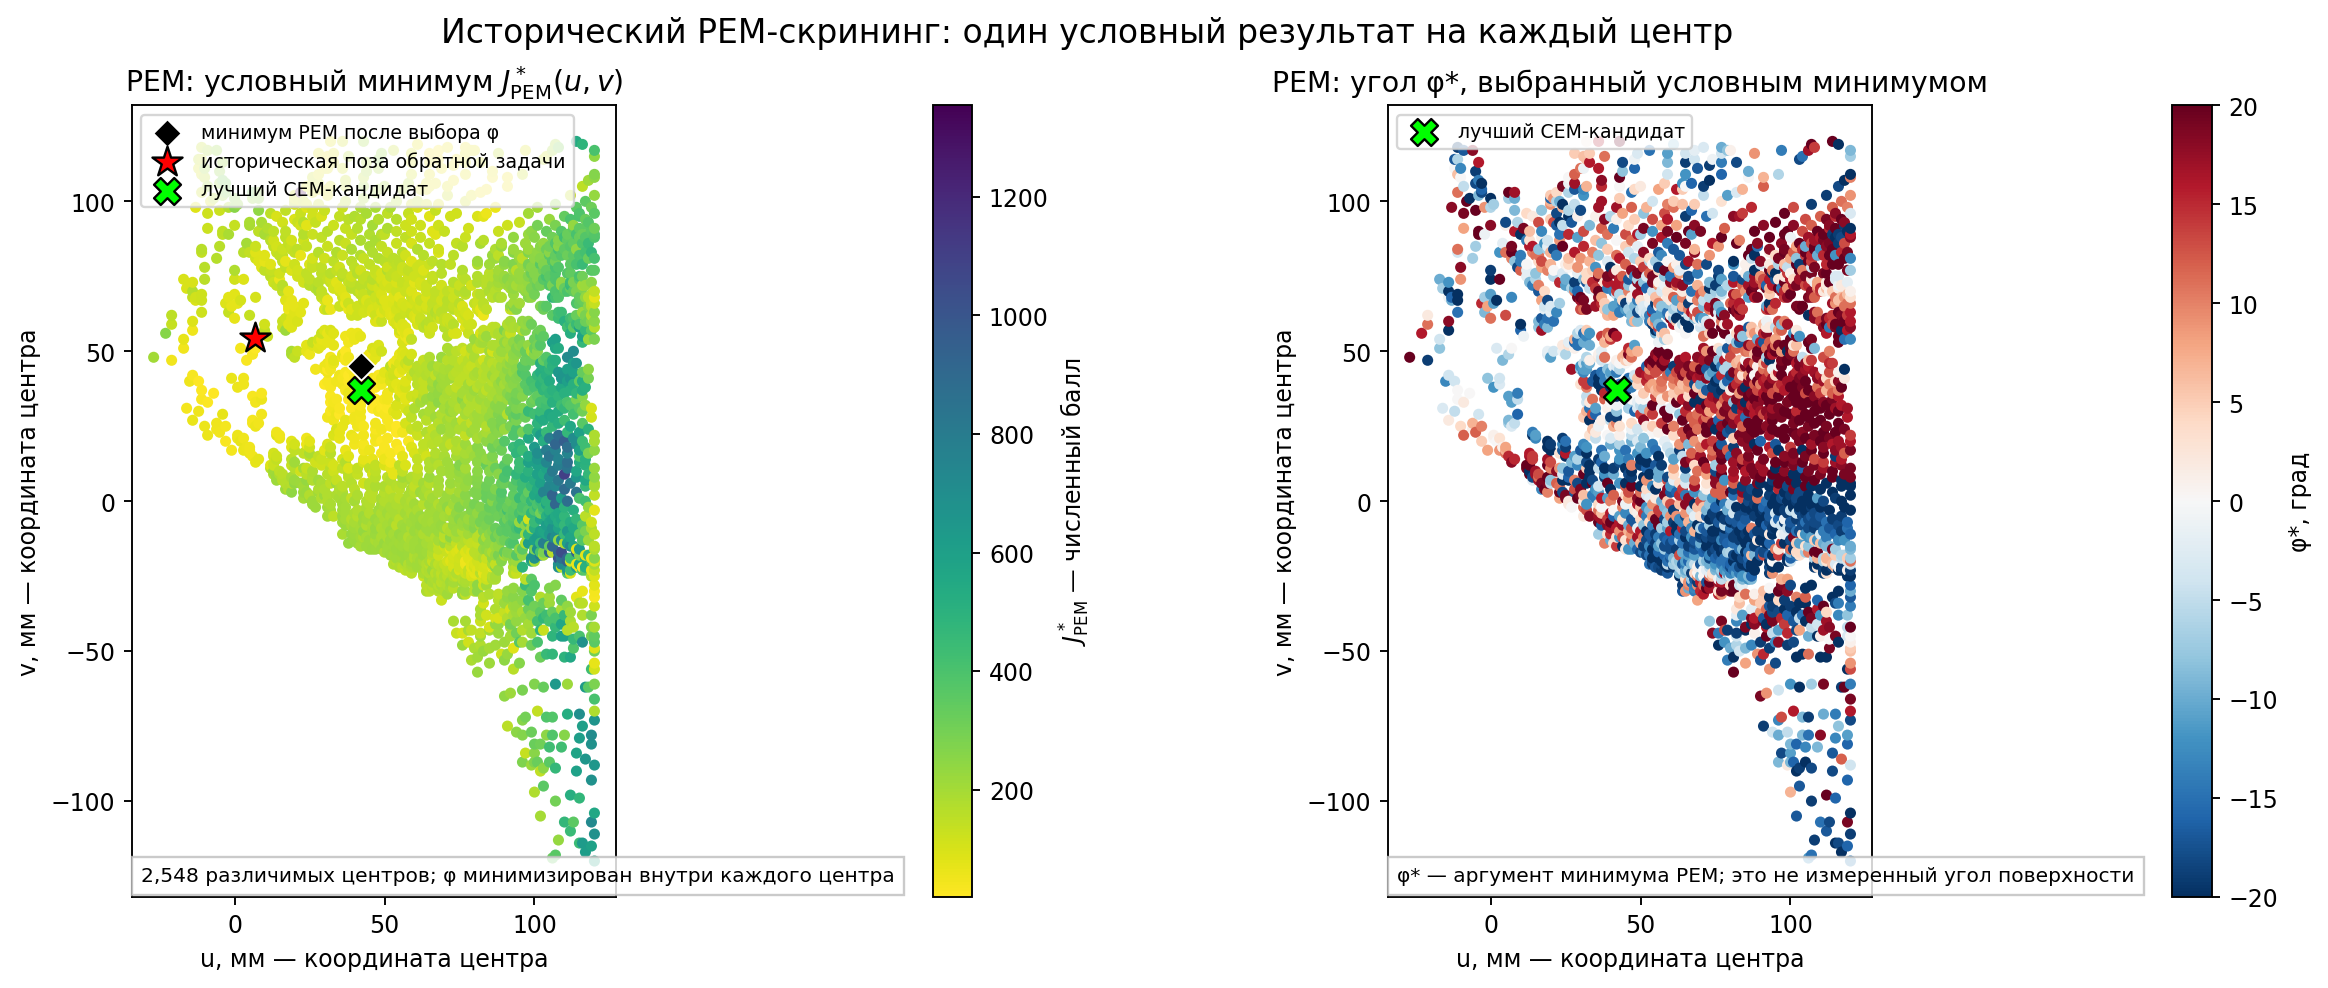

**Рисунок 13.2.** Положение CEM-кандидатов и их составной критерий. Соединённые участки относятся к одному центру и нескольким углам; совокупность точек не следует интерпретировать как функцию только φ.

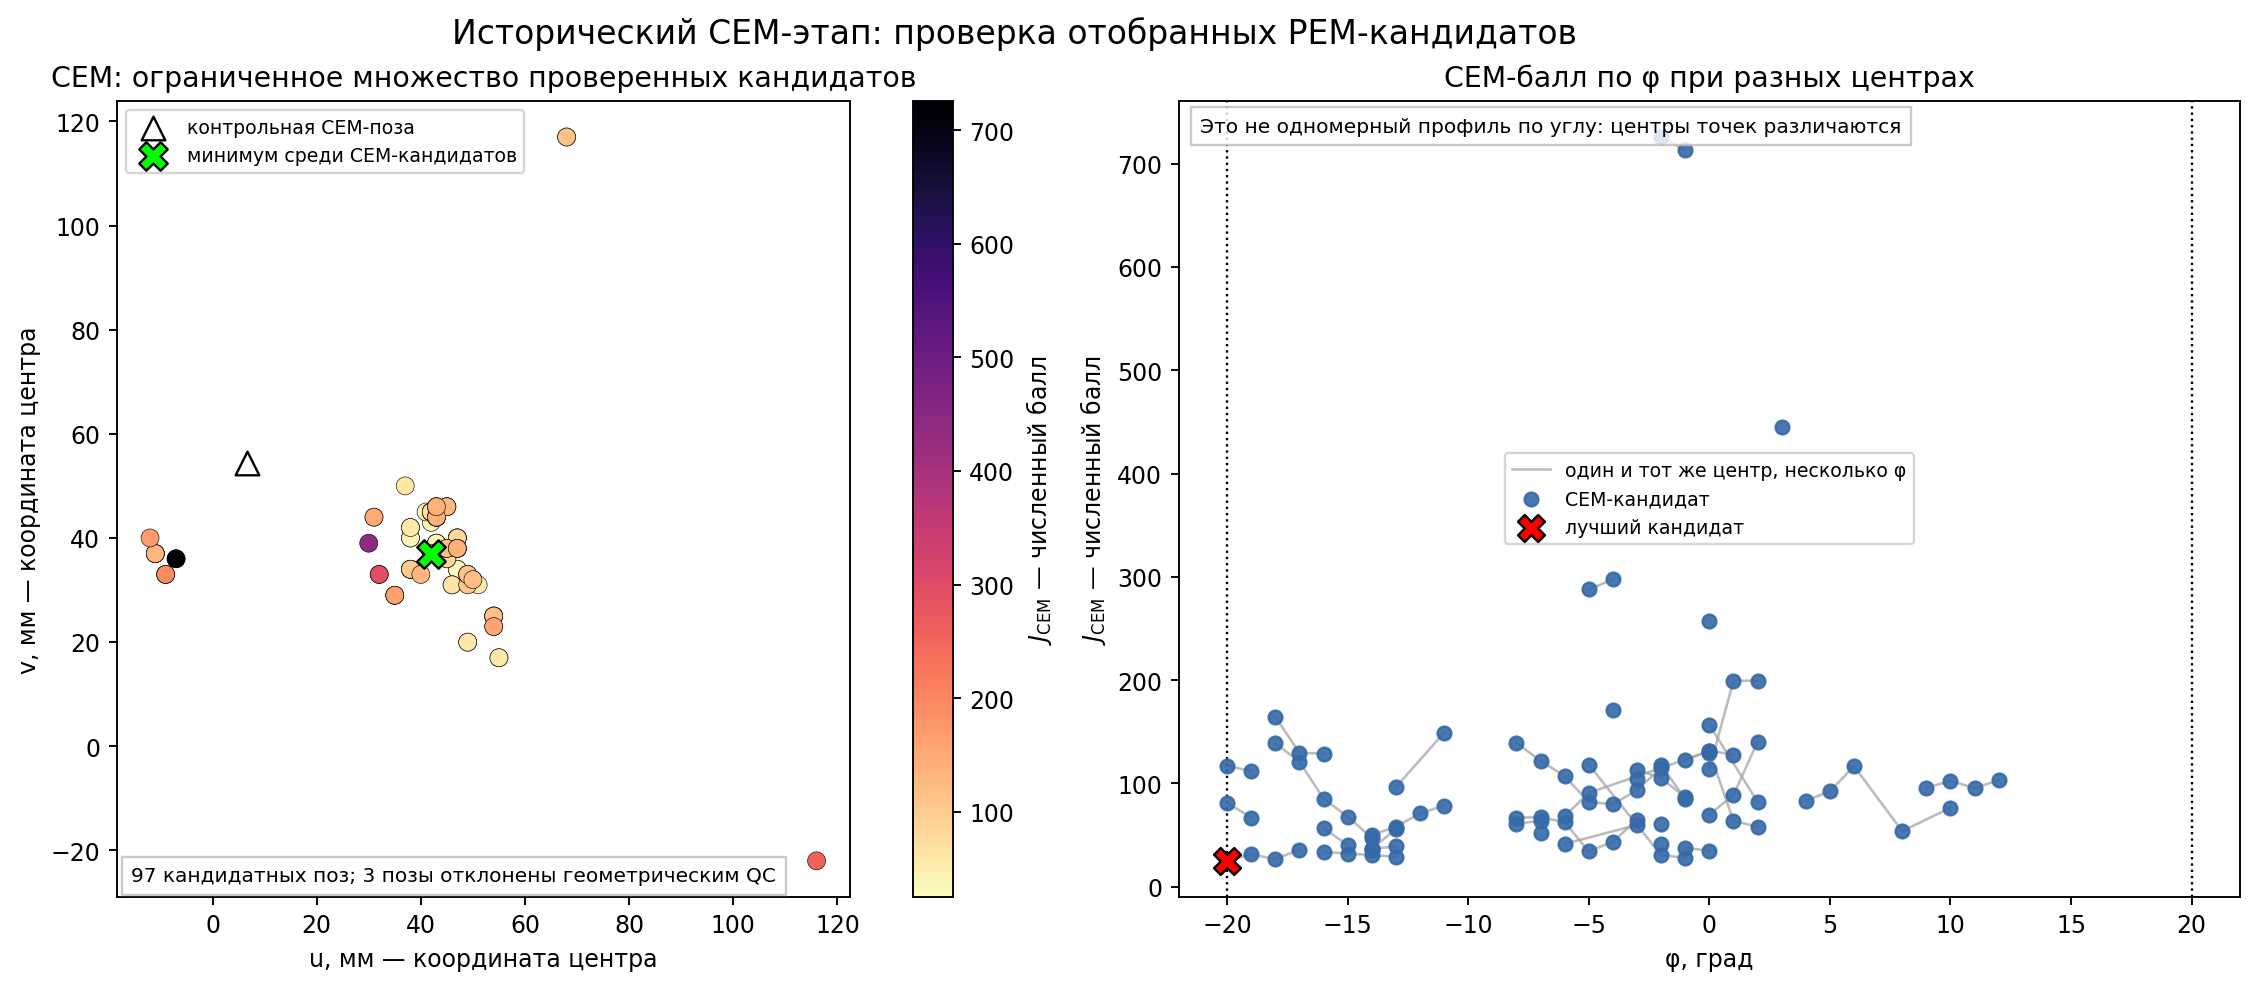

### Лучшие исторические CEM-кандидаты

centre_u_mm,centre_v_mm,phi_deg,h_centre_mm,fast_CEM_objective,slope_ohm_per_mm,is_validation
42.0,37.0,-20,20.856883,25.090952,-0.609781,0
42.0,37.0,-18,20.856883,26.803066,-0.617610,0
50.0,32.0,-1,20.832476,27.935869,-0.502655,0
43.0,39.0,-13,20.930228,29.024996,-0.623465,0
50.0,32.0,-2,20.832476,30.654290,-0.494794,0
43.0,39.0,-14,20.930228,30.710235,-0.633622,0
42.0,37.0,-19,20.856883,31.338145,-0.633977,0
43.0,39.0,-15,20.930228,32.173011,-0.638699,0
43.0,39.0,-16,20.930228,33.959346,-0.643371,0
42.0,45.0,-5,19.880465,34.217474,-0.613377,0


In [ ]:
# revise_2010_pem: cell_45
if historical_pem_available:
    performance = pd.DataFrame([
        {
            'этап': 'глобальный PEM, шаг 1 мм / 1°',
            'исходных центров': int(fast_pem_summary.raw_centre_count),
            'различимых центров': int(fast_pem_summary.unique_anatomical_centre_count),
            'поз центр–φ': int(fast_pem_summary.pose_count),
            'время сканирования, с': float(fast_pem_summary.scan_seconds),
            'RMSE проверки PEM–CEM, Ом': float(fast_pem_summary.validation_RMSE_ohm),
        },
        {
            'этап': 'низкоранговое CEM для лучших PEM-кандидатов',
            'исходных поз': int(fast_cem_summary.requested_pose_count),
            'отличающихся центров': int(fast_cem.loc[
                ~fast_cem.is_validation.astype(bool),
                ['centre_u_mm', 'centre_v_mm']].drop_duplicates().shape[0]),
            'рассчитанных поз': int(fast_cem_summary.evaluated_pose_count),
            'время построения и решений, с': float(
                fast_cem_summary.geometry_seconds
                + fast_cem_summary.green_solve_seconds
                + fast_cem_summary.local_CEM_seconds),
            'RMSE проверки CEM–полный EIDORS, Ом': float(
                fast_cem_summary.validation_curve_RMSE_ohm),
        },
    ])
    display(Markdown('### Объём исторического поиска и численная проверка ускорения'))
    display(performance)

    # The following objects are intentionally kept because later historical
    # cells use them.  ``global_best`` is conditional on the centre: one row
    # is retained after minimising PEM J over the searched phi values.
    global_best_index = fast_pem_all.groupby(
        ['centre_u_mm', 'centre_v_mm']).fast_objective.idxmin()
    global_best = fast_pem_all.loc[global_best_index].copy()

    # CEM was evaluated only for the PEM preselection plus one validation pose.
    # Keep the validation row out of the candidate ranking.
    cem_candidates = fast_cem[~fast_cem.is_validation.astype(bool)].copy()
    cem_candidates = cem_candidates.sort_values(
        'fast_CEM_objective').reset_index(drop=True)
    best_exact = cem_candidates.iloc[0]
    cem_z_columns = [f'Z_fast_CEM_L{int(L):03d}_ohm' for L in comparison.L_mm]
    best_exact_z = best_exact[cem_z_columns].to_numpy(dtype=float)
    best_exact_residual = (
        best_exact_z - comparison.Z_experiment_ohm.to_numpy(dtype=float))
    best_exact_rms = float(np.sqrt(np.mean(best_exact_residual ** 2)))
    best_exact_mae = float(np.mean(np.abs(best_exact_residual)))

    fig_pem, axes = plt.subplots(1, 2, figsize=(14.5, 5.7), constrained_layout=True)
    ax = axes[0]
    sc = ax.scatter(
        global_best.centre_u_mm, global_best.centre_v_mm,
        c=global_best.fast_objective, s=22, cmap='viridis_r',
        edgecolors='none',
    )
    ax.scatter(
        global_best.loc[global_best.fast_objective.idxmin(), 'centre_u_mm'],
        global_best.loc[global_best.fast_objective.idxmin(), 'centre_v_mm'],
        marker='D', s=70, color='black', edgecolor='white', linewidth=0.7,
        label='минимум PEM после выбора φ', zorder=5,
    )
    ax.scatter(
        rejected_summary.centre_u_mm, rejected_summary.centre_v_mm,
        marker='*', s=180, color='red', edgecolor='black',
        label='сохранённая историческая поза обратной задачи', zorder=6,
    )
    ax.scatter(
        best_exact.centre_u_mm, best_exact.centre_v_mm,
        marker='X', s=130, color='lime', edgecolor='black',
        label='лучший из проверенных CEM-кандидатов', zorder=7,
    )
    ax.set(
        title='PEM: условный минимум $J_{\\mathrm{PEM}}^*(u,v)$',
        xlabel='u, мм — координата центра',
        ylabel='v, мм — координата центра',
        aspect='equal',
    )
    ax.text(
        0.02, 0.02,
        f'{len(global_best):,} различимых центров; φ минимизирован внутри каждого центра',
        transform=ax.transAxes, fontsize=8.5,
        bbox=dict(facecolor='white', alpha=0.82, edgecolor='0.75'),
    )
    ax.legend(fontsize=8, loc='upper left')
    fig_pem.colorbar(sc, ax=ax, label='$J_{\\mathrm{PEM}}^*$ — численный балл')

    ax = axes[1]
    sc = ax.scatter(
        global_best.centre_u_mm, global_best.centre_v_mm,
        c=global_best.phi_deg, s=22, cmap='RdBu_r',
        vmin=fast_pem_summary.phi_min_deg,
        vmax=fast_pem_summary.phi_max_deg,
        edgecolors='none',
    )
    ax.scatter(
        best_exact.centre_u_mm, best_exact.centre_v_mm,
        marker='X', s=130, color='lime', edgecolor='black',
        label='лучший CEM-кандидат', zorder=6,
    )
    ax.set(
        title='PEM: угол φ*, выбранный условным минимумом',
        xlabel='u, мм — координата центра',
        ylabel='v, мм — координата центра',
        aspect='equal',
    )
    ax.text(
        0.02, 0.02,
        'φ* — аргумент минимума PEM; это не измеренный угол поверхности',
        transform=ax.transAxes, fontsize=8.5,
        bbox=dict(facecolor='white', alpha=0.82, edgecolor='0.75'),
    )
    ax.legend(fontsize=8, loc='upper left')
    fig_pem.colorbar(sc, ax=ax, label='φ*, град')
    fig_pem.suptitle(
        'Исторический PEM-скрининг: один условный результат на каждый центр',
        fontsize=14,
    )
    display(Markdown(
        '**Рисунок 13.1.** Карта условного минимума PEM и соответствующего угла. '
        'Точки образуют дискретное множество центров после проекции на поверхность '
        'и фильтра глубины; непрерывную точность локализации по карте определять нельзя.'
    ))
    display(fig_pem)

    fig_cem, axes = plt.subplots(1, 2, figsize=(14.5, 5.7), constrained_layout=True)
    ax = axes[0]
    sc = ax.scatter(
        cem_candidates.centre_u_mm, cem_candidates.centre_v_mm,
        c=cem_candidates.fast_CEM_objective, s=58, cmap='magma_r',
        edgecolors='black', linewidths=0.25,
    )
    validation = fast_cem[fast_cem.is_validation.astype(bool)]
    if len(validation):
        ax.scatter(
            validation.centre_u_mm, validation.centre_v_mm,
            marker='^', s=100, color='white', edgecolor='black',
            label='контрольная CEM-поза', zorder=6,
        )
    ax.scatter(
        best_exact.centre_u_mm, best_exact.centre_v_mm,
        marker='X', s=145, color='lime', edgecolor='black',
        label='минимум среди CEM-кандидатов', zorder=7,
    )
    ax.set(
        title='CEM: ограниченное множество проверенных кандидатов',
        xlabel='u, мм — координата центра',
        ylabel='v, мм — координата центра',
        aspect='equal',
    )
    ax.text(
        0.02, 0.02,
        f'{len(cem_candidates)} кандидатных поз; 3 позы отклонены геометрическим QC',
        transform=ax.transAxes, fontsize=8.5,
        bbox=dict(facecolor='white', alpha=0.82, edgecolor='0.75'),
    )
    ax.legend(fontsize=8, loc='upper left')
    fig_cem.colorbar(sc, ax=ax, label='$J_{\\mathrm{CEM}}$ — численный балл')

    ax = axes[1]
    repeated_label_used = False
    for _, group in cem_candidates.groupby(['centre_u_mm', 'centre_v_mm']):
        group = group.sort_values('phi_deg')
        if len(group) > 1:
            ax.plot(
                group.phi_deg, group.fast_CEM_objective,
                color='0.65', linewidth=1.1, alpha=0.75,
                label=('один и тот же центр, несколько φ'
                       if not repeated_label_used else None),
            )
            repeated_label_used = True
    ax.scatter(
        cem_candidates.phi_deg, cem_candidates.fast_CEM_objective,
        s=34, color='#3569a8', alpha=0.9, label='CEM-кандидат', zorder=3,
    )
    ax.scatter(
        best_exact.phi_deg, best_exact.fast_CEM_objective,
        marker='X', s=130, color='red', edgecolor='black',
        label='лучший кандидат', zorder=5,
    )
    ax.axvline(fast_pem_summary.phi_min_deg, color='black', linestyle=':', linewidth=1)
    ax.axvline(fast_pem_summary.phi_max_deg, color='black', linestyle=':', linewidth=1)
    ax.set(
        title='CEM-балл по φ при разных центрах',
        xlabel='φ, град',
        ylabel='$J_{\\mathrm{CEM}}$ — численный балл',
    )
    ax.text(
        0.02, 0.98,
        'Это не одномерный профиль по углу: центры точек различаются',
        transform=ax.transAxes, va='top', fontsize=8.5,
        bbox=dict(facecolor='white', alpha=0.82, edgecolor='0.75'),
    )
    ax.legend(fontsize=8, loc='best')
    fig_cem.suptitle(
        'Исторический CEM-этап: проверка отобранных PEM-кандидатов',
        fontsize=14,
    )
    display(Markdown(
        '**Рисунок 13.2.** Положение CEM-кандидатов и их составной критерий. '
        'Соединённые участки относятся к одному центру и нескольким углам; '
        'совокупность точек не следует интерпретировать как функцию только φ.'
    ))
    display(fig_cem)

    display(Markdown('### Лучшие исторические CEM-кандидаты'))
    display(fast_cem.head(12)[[
        'centre_u_mm', 'centre_v_mm', 'phi_deg', 'h_centre_mm',
        'fast_CEM_objective', 'slope_ohm_per_mm', 'is_validation'
    ]])
else:
    display(Markdown(
        'Исторические PEM/CEM-файлы отсутствуют; раздел пропущен. '
        'Это не блокирует основной отчёт.'
    ))


### 13.3. Как читать исторические карты, углы, ранг и импедансную кривую

На первом рисунке для каждого различимого центра \((u,v)\) оставлено значение

$$
J_{\mathrm{PEM}}^*(u,v)=\min_{\varphi\in[-20^\circ,20^\circ]}
J_{\mathrm{PEM}}(u,v,\varphi).
$$

Поэтому цвет первой панели — условный минимум составного PEM-критерия по
углу. Он не является погрешностью положения, картой чувствительности и не
показывает, насколько центр отличается от истинной анатомической точки.
Цвет второй панели — соответствующий аргумент минимума
\(\varphi^*(u,v)\). Это условно выбранный угол для данного центра. Изменение
цвета означает изменение угла, при котором в пределах старой сетки получается
наименьшее значение критерия; оно не означает измеренный угол поверхности или
физически восстановленную ориентацию сборки.

Критерий PEM в производителе `run_trkg4_fast_pem_scan.m` имеет вид

$$
J_{\mathrm{PEM}}=
\frac1{n_L}\sum_{i=1}^{n_L}H_5\!left(
|Z_{\mathrm{fast},i}-Z_{\mathrm{exp},i}|\right)
+0{,}20\left[(s_{\mathrm{PEM}}-s_{\mathrm{exp}})\Delta L\right]^2
+\left(\frac{h-15}{7}\right)^2,
$$

где \(n_L=9\), \(\Delta L=\max L-\min L\),
\(s_{\mathrm{PEM}}\) — наклон обычной линейной регрессии сохранённой
скорректированной PEM-кривой, а \(s_{\mathrm{exp}}\) — наклон робастной
регрессии экспериментальных значений. Функция Huber с порогом 5 Ом записана
в коде как

$$
H_5(r)=0{,}5\min(r,5)^2+5\max(r-5,0).
$$

Слагаемые критерия имеют разные численные масштабы и в исходном коде не
приведены к общей безразмерной шкале. Поэтому \(J\) следует читать как
численный балл ранжирования внутри этого запуска. Его нельзя подписывать как
ошибку в Омах и нельзя сравнивать с критерием другой постановки без проверки
всех коэффициентов и единиц.

В CEM используется тот же робастный Huber-терм и штраф за наклон, но к ним
добавляются

$$
2\max(h-30,0)^2+2\max(7-h,0)^2
+0{,}25\left(\frac{\rho_2-17{,}4067}{6}\right)^2.
$$

В историческом расчёте \(\rho_2=16{,}492177\ \Omega\cdot\mathrm{m}\) было
зафиксировано, а 17,4067 Ом·м — априорное значение из конфигурации Ника.
Следовательно, CEM-балл зависит не только от соответствия импедансной кривой,
но и от принятого априорного ограничения по глубине и сопротивлению лёгкого.

На второй панели второго рисунка показаны значения \(J_{\mathrm{CEM}}) для
различных кандидатных поз. Точки имеют разные центры \((u,v)\), поэтому этот
график не является одномерным профилем по углу. Тонкие соединённые участки
проведены только между строками с одним и тем же центром; одиночные точки
профиль не образуют. Для измерения зависимости от \(\varphi\) нужно было бы
зафиксировать один центр и просчитать непрерывную или достаточно плотную
угловую серию CEM. Текущий график такого эксперимента не выполняет.

Ранжирование в следующей ячейке упорядочивает 97 проверенных кандидатных поз
по CEM-баллу. Наименьший балл получает кандидат
\((u,v,\varphi)=(42,37,-20^\circ)\), для него \(J_{\mathrm{CEM}}=25{,}091\).
Его RMS-разность с девятью экспериментальными значениями равна 6,635 Ом,
а MAE — 5,619 Ом. Эти числа различаются по смыслу: RMS/MAE используют только
остатки импеданса, тогда как \(J_{\mathrm{CEM}}\) дополнительно учитывает
наклон, глубину и априорное сопротивление лёгкого.

У найденного кандидата угол \(-20^\circ\) лежит на границе исторического
диапазона \([-20^\circ,20^\circ]\). Поэтому внутренний минимум по углу не
установлен. Сам кандидат также не является окончательным положением: он
выбран после PEM-предфильтра, при фиксированных \(\rho_1,\rho_2\), а CEM не
просматривал всю координатно-угловую область.

Дальнейшая проверка должна отделить влияние угла от влияния центра: выполнить
CEM-серию при фиксированных центрах, расширить угловой диапазон и сравнить
полный и сокращённый поиск с одной и той же геометрией и теми же критериями.
После этого результат следует сопоставить с текущим C01-расчётом и независимой
анатомической проверкой. Исторический PEM/CEM-минимум сам по себе не меняет
статус C01 и не даёт физиологической оценки \(\rho_1\) или \(\rho_2\).

Для обсуждаемой методики ускорения этот раздел показывает границу применимости
подхода. Повторное использование факторизации ускоряет перебор, но сохраняет
FEM-оператор. Полностью аналитическое приближение потребовало бы отдельной
проверки его ошибки относительно этого CEM/FEM-эталона на фиксированной
геометрии; текущий исторический поиск такую замену не доказывает.


**Рисунок 13.3.** Слева показано ранжирование 97 проверенных CEM-кандидатов по составному баллу. Справа показана проверка кривой лучшей строки: RMS = **6.635 Ом**, MAE = **5.619 Ом**.

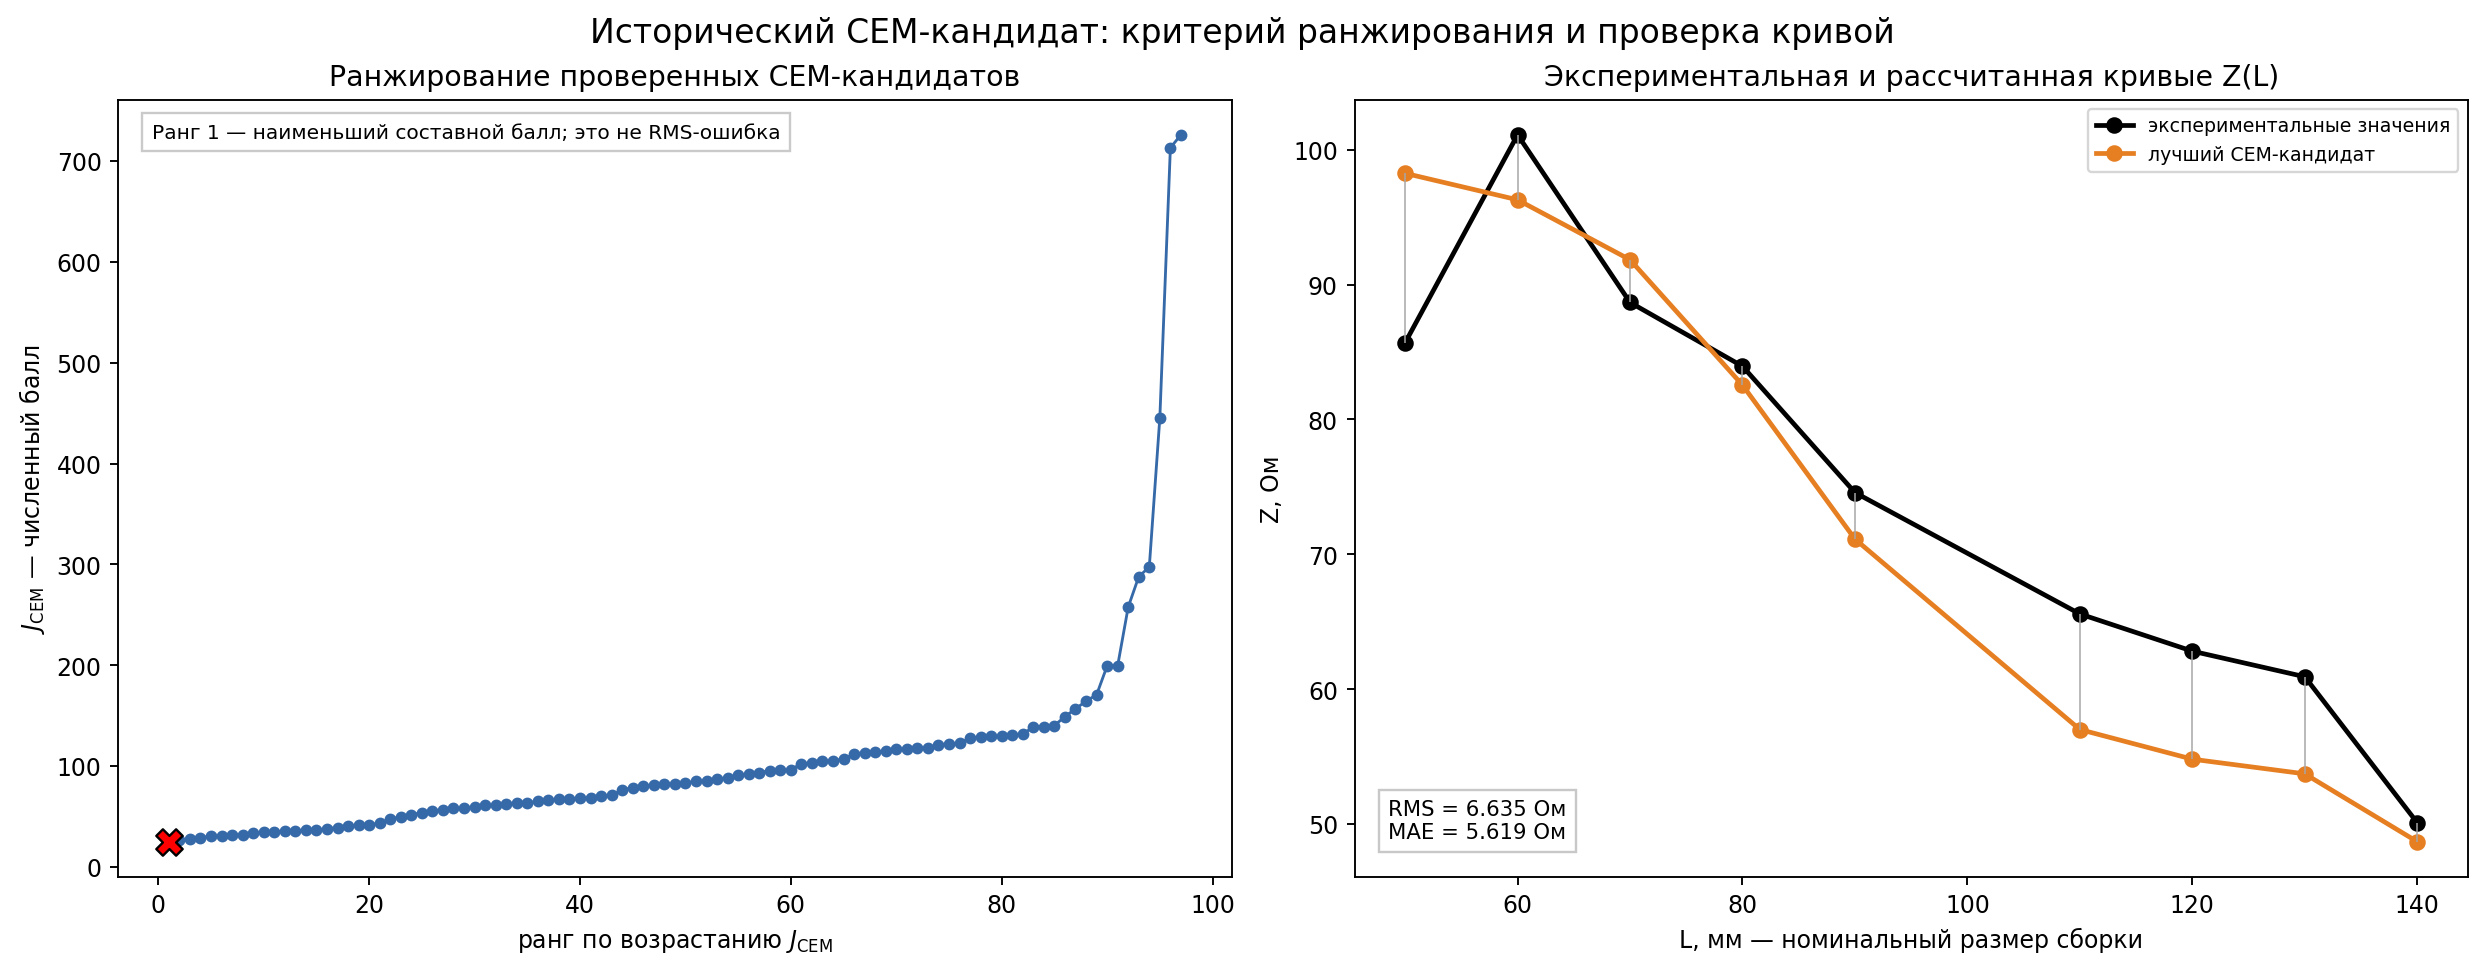

### Численный вывод исторического поиска

- PEM просмотрел **104,468** комбинаций центра и угла,
  сохранив **2,548** различимых
  центров. Его сопоставление с CEM на контрольных позах дало RMSE
  **12.526 Ом** и корреляцию
  **0.783**. Поэтому PEM использовалась
  только как предварительный фильтр.
- В CEM были рассчитаны **98** поз после
  отклонения **3** геометрически
  недопустимых поз. Контроль низкорангового CEM с полным EIDORS дал RMSE
  **1.23e-05 Ом** для одной контрольной
  позы. Это проверка решателя, а не подтверждение найденной анатомической точки.
- Лучший сохранённый CEM-кандидат имеет
  \((u,v,\varphi)=(42.0, 37.0,
  -20.0^\circ)\), \(h=20.86\) мм и
  \(J_{\mathrm{CEM}}=25.091\). Для его импедансной
  кривой RMS = **6.635 Ом**, MAE = **5.619 Ом**.
- Угол на границе старого диапазона: **да**. Внутренний минимум по
  \(\varphi\) не установлен; требуется отдельный фиксированный по центру
  угловой профиль.
- Кандидат получен после PEM-предфильтра, при фиксированных
  \(\rho_1=4.570977\) и \(\rho_2=16.492177\) Ом·м. Он сохраняется как
  диагностический исторический результат и не заменяет текущий C01-кандидат.


In [ ]:
# revise_2010_pem: cell_47
if historical_pem_available:
    phi_on_boundary = bool(
        np.isclose(best_exact.phi_deg, fast_pem_summary.phi_min_deg)
        or np.isclose(best_exact.phi_deg, fast_pem_summary.phi_max_deg)
    )
    phi_boundary_text = 'да' if phi_on_boundary else 'нет'

    fig_rank, axes = plt.subplots(1, 2, figsize=(14.5, 5.6), constrained_layout=True)
    rank = np.arange(1, len(cem_candidates) + 1)
    axes[0].plot(
        rank, cem_candidates.fast_CEM_objective,
        'o-', ms=4, color='#3569a8', linewidth=1.2,
    )
    axes[0].scatter(
        [1], [cem_candidates.fast_CEM_objective.iloc[0]],
        marker='X', s=125, color='red', edgecolor='black', zorder=5,
    )
    axes[0].set(
        title='Ранжирование проверенных CEM-кандидатов',
        xlabel='ранг по возрастанию $J_{\\mathrm{CEM}}$',
        ylabel='$J_{\\mathrm{CEM}}$ — численный балл',
    )
    axes[0].text(
        0.03, 0.97,
        'Ранг 1 — наименьший составной балл; это не RMS-ошибка',
        transform=axes[0].transAxes, va='top', fontsize=8.5,
        bbox=dict(facecolor='white', alpha=0.82, edgecolor='0.75'),
    )

    axes[1].plot(
        comparison.L_mm, comparison.Z_experiment_ohm,
        'ko-', linewidth=2, label='экспериментальные значения',
    )
    axes[1].plot(
        comparison.L_mm, best_exact_z,
        'o-', linewidth=2, color='#e67e22',
        label='лучший CEM-кандидат',
    )
    axes[1].vlines(
        comparison.L_mm, comparison.Z_experiment_ohm, best_exact_z,
        colors='0.65', linewidth=0.8, alpha=0.8,
    )
    axes[1].text(
        0.03, 0.05,
        f'RMS = {best_exact_rms:.3f} Ом\nMAE = {best_exact_mae:.3f} Ом',
        transform=axes[1].transAxes, fontsize=9,
        bbox=dict(facecolor='white', alpha=0.86, edgecolor='0.75'),
    )
    axes[1].set(
        title='Экспериментальная и рассчитанная кривые Z(L)',
        xlabel='L, мм — номинальный размер сборки',
        ylabel='Z, Ом',
    )
    axes[1].legend(fontsize=8, loc='best')
    fig_rank.suptitle(
        'Исторический CEM-кандидат: критерий ранжирования и проверка кривой',
        fontsize=14,
    )
    display(Markdown(
        f'''**Рисунок 13.3.** Слева показано ранжирование {len(cem_candidates)} проверенных
CEM-кандидатов по составному баллу. Справа показана независимая от этого балла
проверка совпадения девяти значений импеданса для лучшей строки: RMS =
**{best_exact_rms:.3f} Ом**, MAE = **{best_exact_mae:.3f} Ом**. Нулевой остаток
означал бы совпадение двух кривых в данной точке размера; вертикальные отрезки
показывают остатки по отдельным размерам.'''
    ))
    display(fig_rank)

    display(Markdown(fr'''### Численный вывод исторического поиска

- PEM просмотрел **{int(fast_pem_summary.pose_count):,}** комбинаций центра и угла,
  сохранив **{int(fast_pem_summary.unique_anatomical_centre_count):,}** различимых
  центров. Его сопоставление с CEM на контрольных позах дало RMSE
  **{fast_pem_summary.validation_RMSE_ohm:.3f} Ом** и корреляцию
  **{fast_pem_summary.validation_correlation:.3f}**. Поэтому PEM использовалась
  только как предварительный фильтр.
- В CEM были рассчитаны **{int(fast_cem_summary.evaluated_pose_count)}** поз после
  отклонения **{int(fast_cem_summary.rejected_geometry_count)}** геометрически
  недопустимых поз. Контроль низкорангового CEM с полным EIDORS дал RMSE
  **{fast_cem_summary.validation_curve_RMSE_ohm:.3g} Ом** для одной контрольной
  позы. Это проверка решателя, а не подтверждение найденной анатомической точки.
- Лучший сохранённый CEM-кандидат имеет
  \((u,v,\varphi)=({best_exact.centre_u_mm:.1f},
  {best_exact.centre_v_mm:.1f}, {best_exact.phi_deg:.1f}^\circ)\),
  \(h={best_exact.h_centre_mm:.2f}\) мм и
  \(J_{{\mathrm{{CEM}}}}={best_exact.fast_CEM_objective:.3f}\).
  Этот балл включает Huber-расхождение, наклон, глубину и априорное значение
  \(\rho_2\), поэтому его нельзя отождествлять с RMS.
- Угол на границе старого диапазона: **{phi_boundary_text}**. Внутренний минимум
  по \(\varphi\) не установлен; требуется отдельный фиксированный по центру
  угловой профиль.
- Исторический кандидат получен после PEM-предфильтра, при фиксированных
  \(\rho_1=4.570977\) и \(\rho_2=16.492177\) Ом·м. Он сохраняется как
  диагностический результат и не заменяет текущий C01-кандидат раздела 20.
'''))
else:
    display(Markdown(
        'Исторические PEM/CEM-файлы отсутствуют; раздел пропущен. '
        'Это не блокирует основной отчёт.'
    ))


## 14. История исправления геометрии и происхождение численных различий

Исторические результаты приведены для установления причин изменения прямой задачи и обратных оценок. Они не образуют единую последовательность улучшения точности: между отдельными версиями менялись контакты, соответствие размера записи и способ поиска. Поэтому их остатки нельзя ранжировать без учёта постановки.

В ходе предшествующей проверки были выявлены неполное заполнение объёма одним из вариантов тетраэдрализации и пересечение узлов соседних контактов. Совместное использование одного граничного узла разными электродами может вносить в модель непредусмотренную электрическую связь. Исправление вводит раздельное владение гранями и запрет общих узлов. Фактическая контактная площадь проверяется по индуцированным граням, участвующим в CEM.

Отдельно исправлено соответствие дублированной записи номинальному размеру: для данного добровольца в набор входит 90 мм. Эта операция изменяет аргумент размерной зависимости, а не сами совпадающие значения дублированного сигнала. В контрольных таблицах её влияние отделено от влияния контактной модели и начального приближения оптимизатора.

Исторические подписи содержат названия конкретных реализаций и идентификаторы файлов для прослеживаемости. Меньшая невязка архивной версии не подтверждает её физическую адекватность, если её контактные площадки не воспроизводятся или не удовлетворяют действующим геометрическим условиям. Вместе с тем отрицательные результаты реконструкции сохраняются: неполное совпадение двух площадок не заменяется утверждением о полном восстановлении архива.

Времена факторизации, построения площадок и малых CEM-решений ниже относятся к соответствующему историческому запуску. Они не являются сравнительным тестом скорости десяти моделей раздела 11.3.1. Для такого теста требуется единая аппаратная среда и разделение первоначальной подготовки и повторных вычислений.

In [ ]:
if historical_pem_available:
    if baseline_available:
        mesh_comparison = pd.DataFrame({
            'версия': ['исторический v4: иной входной набор',
                       'текущий v5: 90 мм включён, 100 мм исключён'],
            'узлы': [int(baseline_summary.mesh_nodes), int(summary.mesh_nodes)],
            'тетраэдры': [int(baseline_summary.mesh_tetrahedra), int(summary.mesh_tetrahedra)],
            'объём FEM, л': [18.973231, 20.170763],
            'медианный шаг поверхности, мм': [2.556, 1.520],
            'RMSE Z, Ом': [baseline_summary.rms_residual_ohm, summary.rms_residual_ohm],
        })
        parameter_comparison = pd.DataFrame({
            'параметр': ['rho_1, Ом·м', 'rho_2, Ом·м', 'u, мм', 'v, мм',
                         'phi, град', 'h центра, мм', 'наклон, Ом/мм'],
            'исторический v4': [baseline_summary.rho_soft_ohm_m, baseline_summary.rho_lungs_ohm_m,
                   baseline_summary.centre_u_mm, baseline_summary.centre_v_mm,
                   baseline_summary.phi_deg, baseline_summary.h_centre_mm,
                   baseline_summary.fem_slope_ohm_per_mm],
            'текущий v5': [summary.rho_soft_ohm_m, summary.rho_lungs_ohm_m,
                   summary.centre_u_mm, summary.centre_v_mm,
                   summary.phi_deg, summary.h_centre_mm,
                   summary.fem_slope_ohm_per_mm],
        })
        display(Markdown(
            '**Важно:** исторический v4 использовал 100 мм вместо независимой записи 90 мм. '
            'Поэтому различие RMSE нельзя приписывать только изменению сетки.'
        ))
        display(mesh_comparison)
        display(parameter_comparison)
    else:
        display(Markdown(
            '**Сравнение с исторической сеткой v4 пропущено:** два старых CSV отсутствуют. '
            'Это не мешает отчёту по текущему расчёту v5.'
        ))
        display(pd.DataFrame({
            'версия': ['v5: 1 мм / local 2 мм'],
            'узлы': [int(summary.mesh_nodes)],
            'тетраэдры': [int(summary.mesh_tetrahedra)],
            'RMSE Z, Ом': [summary.rms_residual_ohm],
        }))

    if pre_rerun_available:
        display(Markdown('### Сопоставление с состоянием непосредственно до перепрогона'))
        display(pd.DataFrame({
            'расчёт': ['v5 до перепрогона', 'v5: итоговый прямой поиск disjoint',
                       'v5: исторический CEM-кандидат'],
            'входной ряд': ['100 мм включён, 90 мм исключён',
                           '90 мм включён, 100 мм исключён',
                           '90 мм включён, 100 мм исключён'],
            'RMSE, Ом': [pre_rerun_summary.rms_residual_ohm,
                         summary.rms_residual_ohm, best_exact_rms],
            'статус': ['архивный результат с неверной субъектной атрибуцией копии',
                       f'выбранный тег {result_tag}; обращения к критерию: {function_evaluations_text}',
                       ('рассчитан при rho из отклонённой точки fmincon; '
                        'лучший угол находится на границе поиска')],
        }))
        display(Markdown(
            'Архивный RMS нельзя сравнивать с новыми двумя строками как чистый эффект алгоритма: '
            'изменены входной размерный ряд и согласованность используемых артефактов.'
        ))

    if pre_rerun_available and ablation_available:
        display(Markdown('### Разложение причин сдвига найденной точки'))

        if legacy_patch_available:
            earliest = legacy_patch_summary['earliest']
            reconstructed_fast = legacy_patch_summary['reconstructed_fast']
            earliest_objective = float(legacy_patch_history['earliest'].objective.min())
            reconstructed_fast_objective = float(
                legacy_patch_history['reconstructed_fast'].objective.min())

            archived_electrodes = pd.read_csv(pre_rerun_electrodes_file)
            reconstructed_electrodes = legacy_patch_electrodes['reconstructed_fast']
            geometry_check = archived_electrodes.merge(
                reconstructed_electrodes, on=['L_mm', 'electrode'],
                suffixes=('_archive', '_reconstructed'))
            geometry_check['centroid_error_mm'] = np.sqrt(sum(
                (geometry_check[f'patch_centroid_{axis}_mm_reconstructed']
                 - geometry_check[f'patch_centroid_{axis}_mm_archive'])**2
                for axis in 'xyz'))
            geometry_check['area_error_mm2'] = (
                geometry_check.patch_area_mm2_reconstructed
                - geometry_check.patch_area_mm2_archive)
            exact_geometry_count = int((
                (geometry_check.centroid_error_mm.abs() < 1e-10)
                & (geometry_check.area_error_mm2.abs() < 1e-10)).sum())
            max_centroid_error = float(geometry_check.centroid_error_mm.abs().max())
            max_area_error = float(geometry_check.area_error_mm2.abs().max())

            reconstructed_curve = legacy_patch_comparison['reconstructed_fast']
            archived_curve = pre_rerun_comparison.set_index('L_mm').loc[
                reconstructed_curve.L_mm]
            exact_impedance_count = int(np.isclose(
                reconstructed_curve.Z_FEM_ohm.to_numpy(float),
                archived_curve.Z_FEM_ohm.to_numpy(float),
                rtol=0, atol=1e-10).sum())

            display(Markdown('#### Проверка восстановленных контактных функций'))
            display(pd.DataFrame({
                'вариант построения электродного пятна': [
                    'архивный результат до перепрогона',
                    'самый ранний алгоритм: независимые пятна с общими узлами',
                    'реконструкция быстрого алгоритма с разделением узлов',
                ],
                'RMSE, Ом': [pre_rerun_summary.rms_residual_ohm,
                             earliest.rms_residual_ohm,
                             reconstructed_fast.rms_residual_ohm],
                'J': [np.nan, earliest_objective, reconstructed_fast_objective],
                'статус': [
                    'сохранённые числа; исходная функция отсутствует',
                    'точно повторена по доступному раннему исходнику',
                    'функциональная реконструкция по установленным правилам',
                ],
            }))

            fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
            ax.plot(pre_rerun_comparison.L_mm, pre_rerun_comparison.Z_FEM_ohm,
                    's--', label='архивная кривая')
            ax.plot(legacy_patch_comparison['earliest'].L_mm,
                    legacy_patch_comparison['earliest'].Z_FEM_ohm,
                    'o:', label='самый ранний алгоритм')
            ax.plot(reconstructed_curve.L_mm, reconstructed_curve.Z_FEM_ohm,
                    'd-', label='реконструкция быстрого алгоритма')
            ax.set(title='Что воспроизводят восстановленные контактные функции',
                   xlabel='L, мм', ylabel='Z, Ом')
            ax.legend()
            display(fig)
            plt.close(fig)
            display(Markdown("<!-- revise_2010_prose:figure:fig-14-1-contact-reconstruction -->\n\n**Рисунок 14.1. Воспроизведение исторической контактной функции.** По оси $L$ показан размер сборки, мм, по оси $Z$ — импеданс, Ом. Сопоставлены архивная FEM-кривая, результат наиболее раннего доступного алгоритма и реконструкция быстрого построения площадок при одной и той же исторической точке. \n\nФигура показывает, насколько изменение правил выбора граничных граней может изменить прямой оператор. Совпадение семи из девяти импедансов в реконструкции не восстанавливает два неустановленных контакта и не подтверждает архивную физическую модель. Результат относится к истории кода и служит объяснением происхождения чисел."))

            display(Markdown(fr'''
Архивная геометрия содержит 36 электродных пятен. Реконструкция быстрого алгоритма
совпала с ней для **{exact_geometry_count} из 36** пятен. Два оставшихся расхождения
относятся к электроду $V_-$ сборок 50 и 70 мм; максимальное смещение центроида равно
**{max_centroid_error:.3f} мм**, максимальное отличие площади —
**{max_area_error:.3f} мм²**. Рассчитанный импеданс точно совпал с архивом для
**{exact_impedance_count} из 9** сборок. В прежней точке RMSE снизился с
{earliest.rms_residual_ohm:.3f} Ом для самого раннего алгоритма до
{reconstructed_fast.rms_residual_ohm:.3f} Ом для реконструкции, но архивное значение
{pre_rerun_summary.rms_residual_ohm:.3f} Ом полностью не воспроизведено.

Таким образом, восстановлено влияние прежнего правила разделения электродных узлов и
подтверждена высокая чувствительность результата к одной-двум краевым граням при малых
расстояниях между электродами. Точное происхождение двух архивных пятен остаётся
неустановленным. Реконструированный режим используется только для проверки происхождения
чисел и не заменяет текущую физически ограниченную модель контакта.
'''))

        old_legacy = ablation_summary['oldpoint_legacy']
        old_manifest = ablation_summary['oldpoint_manifest']
        recovered = ablation_summary['oldstart_manifest']
        old_legacy_history = ablation_history['oldpoint_legacy']
        old_manifest_history = ablation_history['oldpoint_manifest']
        recovered_history = ablation_history['oldstart_manifest']
        old_legacy_curve = ablation_comparison['oldpoint_legacy']
        recovered_curve = ablation_comparison['oldstart_manifest']

        old_objective = float(old_legacy_history.objective.min())
        manifest_objective = float(old_manifest_history.objective.min())
        recovered_objective = float(recovered_history.objective.min())
        rejected_objective = float(rejected_history.objective.min())
        cem_objective = float(fast_cem.fast_CEM_objective.min())
        recovered_shift_from_archive_mm = float(np.hypot(
            recovered.centre_u_mm - pre_rerun_summary.centre_u_mm,
            recovered.centre_v_mm - pre_rerun_summary.centre_v_mm))
        rejected_shift_from_recovered_mm = float(np.hypot(
            rejected_summary.centre_u_mm - recovered.centre_u_mm,
            rejected_summary.centre_v_mm - recovered.centre_v_mm))

        archived_curve_aligned = pre_rerun_comparison.set_index('L_mm').loc[
            old_legacy_curve.L_mm, 'Z_FEM_ohm'].to_numpy(float)
        forward_change = old_legacy_curve.Z_FEM_ohm.to_numpy(float) - archived_curve_aligned
        forward_change_rms = float(np.sqrt(np.mean(forward_change**2)))
        forward_change_max = float(np.max(np.abs(forward_change)))
        forward_change_max_L = int(old_legacy_curve.iloc[np.argmax(np.abs(forward_change))].L_mm)

        cause_table = pd.DataFrame({
            'контрольный расчёт': [
                'архивный v5 непосредственно до перепрогона',
                'прежняя точка, прежняя привязка 100 мм, текущий код',
                'прежняя точка, исправленная привязка 90 мм, текущий код',
                'поиск из прежней точки, исправленная привязка',
                'поиск fmincon из нулевого смещения — отклонён',
                'исторический CEM-кандидат при rho из отклонённой точки',
            ],
            'u, мм': [pre_rerun_summary.centre_u_mm, old_legacy.centre_u_mm,
                     old_manifest.centre_u_mm, recovered.centre_u_mm,
                     rejected_summary.centre_u_mm, fast_cem.iloc[0].centre_u_mm],
            'v, мм': [pre_rerun_summary.centre_v_mm, old_legacy.centre_v_mm,
                     old_manifest.centre_v_mm, recovered.centre_v_mm,
                     rejected_summary.centre_v_mm, fast_cem.iloc[0].centre_v_mm],
            'phi, град': [pre_rerun_summary.phi_deg, old_legacy.phi_deg,
                         old_manifest.phi_deg, recovered.phi_deg,
                         rejected_summary.phi_deg, fast_cem.iloc[0].phi_deg],
            'RMSE, Ом': [pre_rerun_summary.rms_residual_ohm, old_legacy.rms_residual_ohm,
                        old_manifest.rms_residual_ohm, recovered.rms_residual_ohm,
                        rejected_summary.rms_residual_ohm, best_exact_rms],
            'J': [np.nan, old_objective, manifest_objective, recovered_objective,
                  rejected_objective, cem_objective],
            'смысл сравнения': [
                'историческая точка; иной алгоритм построения контакта',
                'изолировано влияние текущей контактной модели',
                'изолирована замена 100 на 90 мм',
                'проверено влияние начального приближения',
                'неудачный локальный путь градиентного решателя',
                'геометрический скрининг без повторной оценки rho',
            ],
        })
        display(cause_table)

        delta_table = pd.DataFrame({
            'проверяемое изменение': [
                'построение контактных площадок при неизменных параметрах и данных',
                'замена привязки 100 на 90 мм при неизменных параметрах',
                'смена старта: отклонённая точка fmincon вместо поиска из прежней области',
            ],
            'изменение показателя': [
                f'RMSE +{old_legacy.rms_residual_ohm-pre_rerun_summary.rms_residual_ohm:.3f} Ом; '
                f'RMS сдвига самой FEM-кривой {forward_change_rms:.3f} Ом',
                f'RMSE {old_manifest.rms_residual_ohm-old_legacy.rms_residual_ohm:+.3f} Ом; '
                f'J {manifest_objective-old_objective:+.3f}',
                f'J {rejected_objective-recovered_objective:+.3f}; '
                f'RMSE {rejected_summary.rms_residual_ohm-recovered.rms_residual_ohm:+.3f} Ом',
            ],
            'оценка влияния на пространственный сдвиг': [
                'существенно изменяет прямую задачу, но сама по себе не требует ухода центра',
                'малое; в прежней точке RMSE даже немного уменьшается',
                'определяющее для полученного ухода v и фиксации угла',
            ],
        })
        display(delta_table)

        def objective_parts_for(row, curve, objective_value):
            residual = curve.residual_ohm.to_numpy(float)
            abs_residual = np.abs(residual)
            huber = 0.5*np.minimum(abs_residual, 5.0)**2 + 5.0*np.maximum(abs_residual-5.0, 0)
            slope_error = (float(row.fem_slope_ohm_per_mm)
                           - float(row.experimental_slope_ohm_per_mm))*90.0
            h = float(row.h_centre_mm)
            rho2 = float(row.rho_lungs_ohm_m)
            parts = [
                huber.mean(),
                0.20*slope_error**2,
                ((h-15.0)/7.0)**2,
                2.0*max(h-30.0, 0.0)**2 + 2.0*max(7.0-h, 0.0)**2,
                0.25*((rho2-17.4067)/6.0)**2,
            ]
            return parts + [objective_value]

        objective_comparison = pd.DataFrame(
            [
                objective_parts_for(recovered, recovered_curve, recovered_objective),
                objective_parts_for(rejected_summary, rejected_comparison, rejected_objective),
            ],
            index=['поиск из прежней точки', 'записанная точка из нулевого старта'],
            columns=['Huber по отдельным Z', 'штраф наклона', 'штраф CT-глубины',
                     'штраф выхода h за диапазон', 'штраф rho2', 'J'],
        )
        display(Markdown('#### Почему записанная точка хуже по собственному критерию'))
        display(objective_comparison)

        fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
        axes[0].plot(rejected_comparison.L_mm, rejected_comparison.Z_experiment_ohm, 'ko-', lw=2,
                     label='эксперимент: независимая запись 90 мм')
        axes[0].plot(pre_rerun_comparison.L_mm, pre_rerun_comparison.Z_FEM_ohm,
                     's--', label='архивная FEM-кривая')
        axes[0].plot(old_legacy_curve.L_mm, old_legacy_curve.Z_FEM_ohm,
                     'o--', label='та же точка, текущая контактная модель')
        axes[0].plot(recovered_curve.L_mm, recovered_curve.Z_FEM_ohm,
                     'd-', label='поиск из прежней точки')
        axes[0].plot(rejected_comparison.L_mm, rejected_comparison.Z_FEM_ohm,
                     'x-', label='записанная точка из нулевого старта')
        axes[0].set(title='Какая часть изменения возникла в прямой задаче',
                    xlabel='L, мм', ylabel='Z, Ом')
        axes[0].legend(fontsize=8)

        objective_labels = ['прежняя точка,\nпрежняя привязка',
                            'прежняя точка,\nисправленная привязка',
                            'поиск из\nпрежней точки',
                            'нулевой старт',
                            'CEM при\nфиксированных rho']
        objective_values = [old_objective, manifest_objective, recovered_objective,
                            rejected_objective, cem_objective]
        axes[1].bar(objective_labels, objective_values,
                    color=['#7f7f7f', '#4c78a8', '#2ca02c', '#d62728', '#ffbf00'])
        axes[1].set(title='Меньшее J означает лучшее согласование по принятому критерию',
                    ylabel='J')
        axes[1].tick_params(axis='x', labelsize=8)
        display(fig)
        plt.close(fig)
        display(Markdown("<!-- revise_2010_prose:figure:fig-14-2-cause-decomposition -->\n\n**Рисунок 14.2. Разложение причин изменения исторического результата.** Левая панель показывает размерные кривые для прежней и текущей контактной реализации, разных привязок размера и разных стартовых точек; оси имеют единицы мм для $L$ и Ом для $Z$. Правая панель показывает значения критерия $J$ для тех же контрольных прогонов. \n\nСравнение читается попарно: при фиксированных остальных условиях изменение контактной дискретизации существенно меняет прямую кривую, а замена дублированной записи 100 мм на независимую 90 мм меняет её аргумент. Разные старты оптимизатора могут приводить к разным дискретным кандидатам. Эти прогоны не образуют единого рейтинга точности и не дают независимой координаты фактической наклейки."))

        display(Markdown(fr'''#### Интерпретация контрольных прогонов

При неизменных параметрах, прежнем наборе измерений и той же объёмной FEM-сетке переход к
текущему построению контактных площадок изменил рассчитанную кривую на
**{forward_change_rms:.3f} Ом RMS**. Наибольшее изменение составило
**{forward_change_max:.3f} Ом** для сборки **{forward_change_max_L} мм**. Поэтому архивный
RMSE {pre_rerun_summary.rms_residual_ohm:.3f} Ом нельзя воспроизвести простым возвратом
параметров: он относится к прежней дискретизации контакта.

Замена дублированной записи 100 мм на независимую запись 90 мм не вызвала большого сдвига.
В обеих записях сохранены одинаковые уровни: 74,580 Ом на вдохе и 70,327 Ом на выдохе;
изменился аргумент $L$, к которому относится это измерение, а не само значение импеданса.
В прежней точке RMSE изменился с **{old_legacy.rms_residual_ohm:.3f}** до
**{old_manifest.rms_residual_ohm:.3f} Ом**, то есть уменьшился на
**{old_legacy.rms_residual_ohm-old_manifest.rms_residual_ohm:.3f} Ом**. Изменение $J$
составило только **{manifest_objective-old_objective:+.3f}**.

Определяющим оказался путь оптимизации. При старте из прежней области поиск остался рядом с
ней: $(u,v,\varphi)=({recovered.centre_u_mm:.3f}, {recovered.centre_v_mm:.3f},
{recovered.phi_deg:.1f}^\circ)$ и дал $J={recovered_objective:.3f}$. Расстояние от архивного
центра в координатах касательной плоскости составило только
**{recovered_shift_from_archive_mm:.3f} мм**, а угол не изменился. Напротив, точка из нулевого
старта отстоит от этого контрольного решения на **{rejected_shift_from_recovered_mm:.3f} мм** и
отличается по углу на **{abs(rejected_summary.phi_deg-recovered.phi_deg):.1f}°**.
Записанная после
перепрогона точка из нулевого смещения имеет $J={rejected_objective:.3f}$, хотя меньшее значение
критерия уже найдено. Её вклад от несовпадения отдельных $Z$ равен
**{objective_comparison.loc['записанная точка из нулевого старта', 'Huber по отдельным Z']:.2f}**,
а штраф наклона — **{objective_comparison.loc['записанная точка из нулевого старта', 'штраф наклона']:.2f}**.
Следовательно, пространственный уход этой точки не подтверждается принятым критерием.

Выявлен численный механизм: при выборе конечного набора поверхностных граней
электрический отклик по позе имеет постоянные участки и скачки; геометрический априорный штраф может изменяться между ними. Микроскопический
шаг конечных разностей `fmincon` не видит этих скачков. Поэтому при нулевом старте угол остался
ровно $0^\circ$, а при старте из прежней точки — ровно $-10^\circ$. Сдвиг по $v$ в первом
прогоне в значительной части следовал штрафу за CT-глубину, а не минимуму расхождения с
измеренным $Z(L)$.

CEM-кандидат имеет меньший RMSE, но $J={cem_objective:.3f}$ и найден при фиксированных
$\rho_1,\rho_2$ из неудачной точки; кроме того, его угол лежит на границе поиска. Его следует
сохранить как отдельный диагностический кандидат, но не считать новой итоговой локализацией.
'''))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
    axes[0].plot(comparison.L_mm, comparison.Z_experiment_ohm, 'ko-', lw=2,
                 label='эксперимент')
    if baseline_available:
        axes[0].plot(baseline_comparison.L_mm, baseline_comparison.Z_FEM_ohm, 's--',
                     label='исторический v4, иной набор')
    axes[0].plot(comparison.L_mm, comparison.Z_FEM_ohm, 'o-', lw=2,
                 label='v5, итоговый disjoint')
    axes[0].plot(comparison.L_mm, best_exact_z, 'd-', lw=2,
                 label='исторический CEM-кандидат')
    axes[0].set(title='Измеренная и рассчитанные кривые',
                xlabel='L, мм', ylabel='Z, Ом')
    axes[0].legend()

    x = np.arange(len(comparison))
    axes[1].bar(x - 0.18, comparison.residual_ohm, width=0.36,
                label='итоговый disjoint')
    axes[1].bar(x + 0.18, best_exact_residual, width=0.36,
                label='исторический CEM-кандидат')
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_xticks(x, comparison.L_mm.astype(int))
    axes[1].set(title='Как читать остатки: нуль означает совпадение',
                xlabel='L, мм', ylabel='$Z_{модель}-Z_{эксперимент}$, Ом')
    axes[1].legend()
    display(fig)
    plt.close(fig)
    display(Markdown("<!-- revise_2010_prose:figure:fig-14-3-current-historical-summary -->\n\n**Рисунок 14.3. Сопоставление текущего и исторического CEM-кандидатов.** На левой панели приведены экспериментальная и рассчитанные зависимости $Z(L)$, где $L$ выражен в миллиметрах, а $Z$ — в омах; на правой панели показаны подписанные остатки относительно эксперимента. Нулевая линия правой панели соответствует совпадению модели и наблюдения. \n\nИсторический CEM-кандидат рассчитан с сопротивлениями отклонённой точки и потому не является повторной оценкой текущего кандидата. Меньший RMSE при фиксированных параметрах не отменяет выхода угла на границу старого поиска. Фигура предназначена для прослеживаемости, а не для выбора окончательной позы."))
else:
    display(Markdown('Исторические PEM/CEM-файлы отсутствуют; раздел пропущен. Это не блокирует основной отчёт.'))

In [ ]:
if historical_pem_available:
    overlap = pd.read_csv(OUT / 'nik_trkg4_patch_overlap_v5_1mm_local2mm.csv')
    timing = pd.DataFrame({
        'этап': ['геометрия площадок', 'факторизация', 'решения с матрицей Грина', 'локальные CEM'],
        'секунды': [fast_cem_summary.geometry_seconds, fast_cem_summary.factor_seconds,
                    fast_cem_summary.green_solve_seconds, fast_cem_summary.local_CEM_seconds],
    })
    display(Markdown('### Исторический контроль раздельности площадок v5_1mm_local2mm'))
    display(pd.DataFrame({
        'проверено пар электродов': [len(overlap)],
        'пар с общими узлами': [(overlap.shared_nodes > 0).sum()],
        'пар с общими гранями': [(overlap.shared_faces > 0).sum()],
    }))
    display(Markdown('### Измеренное время низкорангового CEM-пересчёта'))
    display(timing)

    display(Markdown(fr'''### Основной результат v5 и статус исторического CEM-скрининга

- Выбранный кандидат `{result_tag}`: $\rho_1={summary.rho_soft_ohm_m:.3f}$ Ом·м,
  $\rho_2={summary.rho_lungs_ohm_m:.3f}$ Ом·м,
  $(u,v,\varphi)=({summary.centre_u_mm:.3f}, {summary.centre_v_mm:.3f},
  {summary.phi_deg:.1f}^\circ)$, $h_{{centre}}={summary.h_centre_mm:.2f}$ мм.
- Его наклон FEM: **{summary.fem_slope_ohm_per_mm:.6f} Ом/мм** при экспериментальном
  **{summary.experimental_slope_ohm_per_mm:.6f} Ом/мм**;
  RMSE **{summary.rms_residual_ohm:.3f} Ом**, MAE **{summary.mae_residual_ohm:.3f} Ом**;
  секущие: {secant_status_text}
- Исторический CEM-кандидат рассчитан при $\rho_1,\rho_2$ отклонённой точки `fmincon`, а не
  при итоговых значениях `disjoint`:
  $(u,v,\varphi)=({best_exact.centre_u_mm:.1f}, {best_exact.centre_v_mm:.1f},
  {best_exact.phi_deg:.1f}^\circ)$, $h_{{centre}}={best_exact.h_centre_mm:.2f}$ мм;
  RMSE **{best_exact_rms:.3f} Ом**, MAE **{best_exact_mae:.3f} Ом**.
- Его угол равен границе старого диапазона ({fast_pem_summary.phi_min_deg:.0f}°), поэтому этот
  результат сохраняется только как диагностика и не конкурирует с итоговой координатой.

Построение площадок занимает {fast_cem_summary.geometry_seconds:.1f} с, факторизация —
{fast_cem_summary.factor_seconds:.2f} с, а {int(fast_cem_summary.evaluated_pose_count)} малых
CEM-решений — {fast_cem_summary.local_CEM_seconds:.1f} с в историческом прогоне. Эти времена
не относятся к выбранному тегу. Статус нового кандидата указан в начале отчёта.
'''))
else:
    display(Markdown('Исторические PEM/CEM-файлы отсутствуют; раздел пропущен. Это не блокирует основной отчёт.'))

## 15. Геометрическая предобработка и её физические последствия

### 15.1. Наружная область

Исходная поверхность тела преобразована в изотропную воксельную маску с шагом 1 мм. После морфологического замыкания выполнялись заполнение полостей, выбор основной компоненты, извлечение поверхности и уменьшение числа треугольников. В принятой поверхности зарегистрированы 77 562 вершины, 155 120 граней и объём около 20,171 л. Проверка замкнутости подтверждает пригодность этой оболочки для задания конечного объёма.

Обработка радиусом 10 мм устраняла дефекты замыкания, но могла изменять локальные узкие участки поверхности. Сходство итогового объёма с предыдущей версией не доказывает отсутствия локальных смещений. Оценка поверхностного расстояния до исходной сегментации и её влияния на импеданс остаётся самостоятельной задачей. Искусственные торцы рук участвуют в граничной задаче, хотя электроды данной боковой сборки на них не располагаются.

### 15.2. Лёгочная область

Рабочая поверхность лёгких получена из очищенной сегментации, а не из её выпуклой оболочки. По историческому геометрическому паспорту объём поверхности составляет около 4,242 л; при проверке заполнение воксельной маски изменило один воксель. Эти сведения относятся к конкретной подготовке поверхности и не являются оценкой неопределённости её границы.

Внутри лёгочной области назначается эффективная проводимость смеси ткани и воздуха. Дыхательные пути не выделены как самостоятельные непроводящие полости. Сохранение наружной формы трахеи не означает моделирования её отдельной внутренней среды. Такой выбор упрощает материальную структуру и должен учитываться при интерпретации сопротивления лёгкого.

В двухтканном FEM объём элементов, классифицированных как лёгкое, составляет около 4,217 л. Разность с объёмом поверхности отражает, в частности, назначение материала по центрам существующих тетраэдров. Проверка электрической значимости этого различия требует сгущения или другого способа представления интерфейса.

### 15.3. Материальные маски и контроль границ

В исходной модели фон заполняет весь наружный объём, после чего маски лёгких, сердца и костей переопределяют свойства отдельных элементов. Отдельная кровь не представлена. В специальном двухтканном сравнении классификация строится по лёгочной поверхности заново; все остальные элементы объединяются.

Самосогласованность сетки, геометрическая близость к сегментации и точность решения поля проверяются разными процедурами. Сумма объёмов и отсутствие общих электродных узлов контролируют определённые дефекты, но не заменяют исследования сходимости и независимой анатомической проверки. Эти ограничения относятся и к любому будущему методу, обученному воспроизводить текущий FEM: ускоренный суррогат может точно перенять численную ошибку референса.

## 16. Идентифицируемость параметров и компенсация модельной ошибки

### 16.1. Число наблюдений и локальный ранг

Для одного размера при фиксированной геометрии имеется одно скалярное наблюдение и два сопротивления. В окрестности регулярной точки множество согласованных параметров обычно имеет одно свободное направление. Несколько размеров могут увеличить ранг информации, если их чувствительности достаточно различаются. Само неравенство между числом наблюдений и числом неизвестных не гарантирует идентифицируемости.

Для пяти параметров исходной задачи анализируется масштабированная матрица конечных секущих:

$$
\widetilde J=J^{(\Delta)}S=U\Sigma V^T,
$$
где $J^{(\Delta)}$ — матрица секущих раздела 8; $S$ — диагональная матрица заданных масштабов параметров; $U,V$ — матрицы сингулярных векторов; $\Sigma$ — диагональная матрица сингулярных чисел. Масштабирование необходимо, поскольку сопротивления, координаты и углы имеют разные единицы.

Малое сингулярное число указывает направление, слабо меняющее линейную аппроксимацию наблюдений на выбранном масштабе. Число обусловленности зависит от нормировки, параметризации и шага. В сохранённом примере оно составляет около 79,4. Это диагностический результат для секущих; его нельзя интерпретировать как вероятность правильной локализации.

Слабое направление в приведённой таблице получено линейной комбинацией столбцов. Полный FEM в смещённой точке здесь не пересчитывался. Поэтому предсказанный малый отклик является результатом линейной суррогатной модели и требует нелинейной проверки. Если диагностика шагов отсутствует или матрица содержит недоступные значения, SVD и дыхательная линейная подгонка пропущены; наличие файла само по себе не подтверждает пригодности этих операций.

### 16.2. Влияние регуляризации

Исходный критерий объединяет девять остатков, наклон той же кривой и априорные предпочтения. Наклон не является дополнительным независимым измерением. Регуляризация способна сузить семейство решений, однако это сужение определяется и внешними допущениями. Для интерпретации необходимы профильные исследования: один параметр фиксируется на сетке, остальные переоптимизируются, а измерительный остаток и штрафы сохраняются раздельно.

Стабильность результата по начальным точкам, границам поиска, составу размеров и силе регуляризации должна проверяться до присвоения параметрам физиологического смысла. При дискретных контактах оптимизация по позе требует метода, учитывающего переключения, либо изменения контактного представления. Большое число знаков найденной координаты не заменяет такой проверки.

### 16.3. Почему точность прямой модели недостаточна для выбора упрощения

Пусть упрощённая модель имеет небольшую, но систематическую ошибку относительно опорной. При регулярной внутренней точке, полном ранге чувствительности и отсутствии регуляризации первое приближение смещения восстановленных параметров равно

$$
\delta\boldsymbol\beta\approx-(J_\beta^TWJ_\beta)^{-1}J_\beta^TW\mathbf e,
$$
где $\boldsymbol\beta$ — идентифицируемые параметры упрощённой модели; $J_\beta$ — их локальная матрица производных; $W$ — положительно определённая весовая матрица; $\mathbf e$ — вектор ошибки прямой модели при истинных синтетических параметрах; $\delta\boldsymbol\beta$ — вызванное этой ошибкой смещение оценки. Формула относится к гладкой локальной задаче; активные ограничения, регуляризация и дискретное изменение контактов требуют иного анализа.

Из выражения следует, что одинаковая RMS прямого расчёта может приводить к различным ошибкам сопротивлений. Особенно опасна составляющая модельной ошибки вдоль слабых информативных направлений. Поэтому будущий выбор должен учитывать не только совпадение импеданса, но и чувствительности, устойчивость обратной задачи и смещение параметров в синтетических проверках.

In [ ]:
if compute_jacobian and jacobian_step_diagnostics_ok and jacobian_numeric_available:
    jacobian = pd.read_csv(OUT / f'nik_trkg4_inverse_inhale_jacobian_{result_tag}.csv')
    parameter_names = ['rho1', 'rho2', 'u', 'v', 'phi']
    parameter_scales = np.array([1.0, 5.0, 10.0, 10.0, 10.0])
    J = jacobian.iloc[:, 1:].to_numpy(float)
    J_scaled = J * parameter_scales
    _, singular_values, right_vectors = np.linalg.svd(J_scaled, full_matrices=False)
    weak_scaled = right_vectors[-1]
    weak_physical = weak_scaled * parameter_scales
    weak_delta_z = J @ weak_physical

    residual = comparison.residual_ohm.to_numpy(float)
    abs_residual = np.abs(residual)
    huber = 0.5 * np.minimum(abs_residual, 5.0)**2 + 5.0 * np.maximum(abs_residual - 5.0, 0)
    slope_difference = float(summary.fem_slope_ohm_per_mm-summary.experimental_slope_ohm_per_mm)
    objective_parts = pd.DataFrame({
        'часть критерия': ['средняя функция Хьюбера по Z', 'штраф наклона', 'априорный штраф по h',
                           'выход h за 7–30 мм', 'априорный штраф по rho2'],
        'вклад': [huber.mean(), 0.20*(90*slope_difference)**2,
                  ((float(summary.h_centre_mm)-15)/7)**2,
                  2*max(float(summary.h_centre_mm)-30, 0)**2
                  + 2*max(7-float(summary.h_centre_mm), 0)**2,
                  0.25*((float(summary.rho_lungs_ohm_m)-17.4067)/6)**2]
    })

    weak_table = pd.DataFrame({
        'параметр': parameter_names,
        'компенсирующее изменение': weak_physical,
        'единица': ['Ом·м', 'Ом·м', 'мм', 'мм', 'град']
    })
    display(objective_parts)
    display(pd.DataFrame({'масштабированное сингулярное число': singular_values}))
    display(weak_table)
    display(Markdown(
        f'Линейная суррогатная модель по секущим предсказывает для слабого направления **'
        f'{np.sqrt(np.mean(weak_delta_z**2)):.3f} Ом RMS** и не более '
        f'**{np.max(np.abs(weak_delta_z)):.3f} Ом**; '
        f'число обусловленности = **{singular_values[0]/singular_values[-1]:.1f}**. '
        'Это предсказание J @ delta_theta; полный FEM в смещённой точке здесь не пересчитывался. '
        'Результат не является оценкой неопределённости позы.'
    ))

    fig, ax = plt.subplots(figsize=(8, 4.8), constrained_layout=True)
    ax.semilogy(np.arange(1, len(singular_values) + 1), singular_values, 'o-', lw=2)
    ax.set(xticks=np.arange(1, len(singular_values) + 1),
           xlabel='номер сингулярного числа', ylabel='масштабированное сингулярное число, Ом',
           title='Спектр масштабированных конечных секущих')
else:
    display(Markdown('Якобиан не рассчитан или его диагностика неполна; числовой раздел чувствительности пропущен.'))

<!-- revise_2010_prose:figure:fig-16-1-singular-spectrum -->

**Рисунок 16.1. Спектр масштабированной матрицы конечных секущих.** По оси абсцисс расположен номер сингулярного числа, по оси ординат в логарифмическом масштабе — его значение в омах после заданного масштабирования сопротивлений, координат и угла. Разрыв между большим и малым значением показывает слабое направление линейной диагностической модели. 

Число обусловленности около 79,4 означает, что в выбранной нормировке наиболее слабое направление заметно хуже обусловлено, чем наиболее сильное. Это не стандартная ошибка и не доверительный интервал: матрица построена конечными шагами, а геометрические контакты дискретны. Следующий контроль должен проверить слабое направление полным нелинейным расчётом и изменением шагов.


In [ ]:
if compute_jacobian and jacobian_step_diagnostics_ok and jacobian_numeric_available:
    display(Markdown(f'''### Интерпретация обусловленности

Для выбранного масштаба параметров спектр конечных секущих имеет число обусловленности
**{singular_values[0]/singular_values[-1]:.1f}**. Слабейшее направление показывает
компенсацию параметров в локальной численной диагностике.

Эти значения получены на явно заданных конечных шагах для дискретных CEM-площадок.
Они зависят от шага и не являются производной непрерывной позы, информацией Фишера,
оценкой стандартной ошибки или доказательством идентифицируемости положения.
'''))
else:
    display(Markdown('Якобиан не рассчитан или его диагностика неполна; числовой раздел чувствительности пропущен.'))

## 17. Дыхательные состояния и ограничения линейной интерпретации

Для каждого размера имеются агрегированные уровни на задержке вдоха и выдоха, полученные в рамках соответствующей установки. Межсостоянийная разность задаётся как

$$
\Delta Z_i=Z_{i,\mathrm{вд}}-Z_{i,\mathrm{выд}},
$$
где $\Delta Z_i$ — дыхательная разность, Ом; $Z_{i,\mathrm{вд}}$ и $Z_{i,\mathrm{выд}}$ — уровни на вдохе и выдохе для размера $L_i$. Принятая последовательность состояний и их интервалы относятся к конкретной записи.

Постоянная аддитивная составляющая может сократиться при вычитании. Однако контактный параметр входит в решение краевой задачи и не обязан давать чисто аддитивную поправку, независимую от тканей. Поэтому сохранение одной наклейки не гарантирует полного устранения контактного влияния. Изменения геометрии кожи, лёгкого и диафрагмы также сохраняются в разности.

Ниже выполнена диагностическая подгонка по секущим сопротивлений при геометрии вдоха. Её невязка не доказывает геометрический вклад в дыхательный сигнал. Полученное большое приращение сопротивления может выходить за область применимости линейной модели. Конечный нелинейный отклик при той же геометрии способен отличаться от линейного предсказания.

Для разделения вкладов потребовалось бы сопоставить конечное изменение сопротивлений при фиксированной геометрии, изменение геометрии при фиксированных свойствах и их совместное изменение. Из-за нелинейности соответствующие эффекты не обязаны складываться независимо. В текущем отчёте количественное разложение дыхательной разности по этим механизмам не установлено.

Спокойное и усиленное дыхание дают временную информацию внутри отдельной записи. Они могут использоваться для изучения повторяемости и выбора устойчивых уровней, но не образуют одновременно измеренный вектор по всем размерам. Пульсовые изменения сопротивления представляют другую задачу и не отождествляются с вентиляционными приращениями между задержками.

In [ ]:
if compute_jacobian and jacobian_step_diagnostics_ok and jacobian_numeric_available:
    breath = pd.read_csv(ROOT / 'data' / 'nik' / 'experimental' / 'nik_breath_hold_levels.csv')
    breath_independent = breath[breath.is_independent == 1].copy().reset_index(drop=True)
    jacobian_by_L = jacobian.set_index('L_mm').loc[breath_independent.L_mm]
    delta_measured = breath_independent.delta_in_minus_ex_ohm.to_numpy(float)
    j_rho1 = jacobian_by_L.dZ_drho_soft.to_numpy(float)
    j_rho2 = jacobian_by_L.dZ_drho_lungs.to_numpy(float)

    delta_rho2_only = float(j_rho2 @ delta_measured / (j_rho2 @ j_rho2))
    delta_pred_rho2_only = j_rho2 * delta_rho2_only
    delta_rho12 = np.linalg.lstsq(np.column_stack((j_rho1, j_rho2)),
                                  delta_measured, rcond=None)[0]
    delta_pred_rho12 = np.column_stack((j_rho1, j_rho2)) @ delta_rho12

    diagnostic_delta = pd.DataFrame({
        'линейная суррогатная модель': ['секущие при фиксированной геометрии, только rho2',
                                        'секущие при фиксированной геометрии, rho1 и rho2'],
        'delta rho1, Ом·м': [0.0, delta_rho12[0]],
        'delta rho2, Ом·м': [delta_rho2_only, delta_rho12[1]],
        'RMSE delta Z, Ом': [np.sqrt(np.mean((delta_pred_rho2_only-delta_measured)**2)),
                             np.sqrt(np.mean((delta_pred_rho12-delta_measured)**2))]
    })

    legacy_and_ct = pd.DataFrame({
        'источник': ['CT/HU + Maxwell-Garnett, глубокий вдох',
                     'старая двухслойная совместная оценка, вдох',
                     'старая двухслойная совместная оценка, выдох',
                     f'выбранный FEM-кандидат {result_tag}, вдох'],
        'rho2, Ом·м': [17.4067, 17.6575, 14.7108, summary.rho_lungs_ohm_m],
        'оговорка': ['f_air=0.799, rho_matrix=2.5 Ом·м',
                     'фиксированное h=15 мм', 'фиксированное h=15 мм',
                     'идентифицируемость не установлена']
    })

    q_values = np.arange(0.50, 1.001, 0.10)
    f_air_in = 0.799
    rho_matrix = 2.5
    f_air_ex = 1.0 - (1.0-f_air_in)/q_values
    rho2_ex_scenarios = rho_matrix*(1.0+f_air_ex/2.0)/(1.0-f_air_ex)
    volume_scenarios = pd.DataFrame({
        'q=V_ex/V_in': q_values,
        'f_air_ex': f_air_ex,
        'rho2_ex по Maxwell-Garnett, Ом·м': rho2_ex_scenarios,
    })

    display(breath_independent)
    display(diagnostic_delta)
    display(legacy_and_ct)
    display(volume_scenarios)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.4), constrained_layout=True)
    axes[0].plot(breath_independent.L_mm, breath_independent.Z_inhale_hold_ohm,
                 'o-', lw=2, label='глубокий вдох, задержка')
    axes[0].plot(breath_independent.L_mm, breath_independent.Z_exhale_hold_ohm,
                 's-', lw=2, label='глубокий выдох, задержка')
    axes[0].set(xlabel='L, мм', ylabel='Z, Ом', title='Сохранённые уровни задержек дыхания')
    axes[0].legend()
    axes[1].plot(breath_independent.L_mm, delta_measured, 'ko-', lw=2,
                 label='измеренное ΔZ')
    axes[1].plot(breath_independent.L_mm, delta_pred_rho2_only, 's--',
                 label=f'только Δρ₂={delta_rho2_only:.1f} Ом·м')
    axes[1].plot(breath_independent.L_mm, delta_pred_rho12, '^--',
                 label=f'Δρ₁={delta_rho12[0]:.2f}, Δρ₂={delta_rho12[1]:.1f} Ом·м')
    axes[1].set(xlabel='L, мм', ylabel='Z_in-Z_ex, Ом',
                title='Линейная подгонка по секущим при фиксированной геометрии')
    axes[1].legend()
else:
    display(Markdown('Дыхательная линейная подгонка пропущена: для выбранного контракта нет пригодного Якобиана.'))

<!-- revise_2010_prose:figure:fig-17-1-breathing-diagnostic -->

**Рисунок 17.1. Дыхательные уровни и линейная диагностическая подгонка.** На левой панели показаны уровни $Z$ на задержке глубокого вдоха и выдоха для размеров $L$, мм; на правой — измеренная разность $Z_{\rm вд}-Z_{\rm выд}$ и её линейные приближения через изменение только $\rho_2$ либо обоих сопротивлений. Все вертикальные значения выражены в омах, приращения сопротивления — в Ом·м. 

Фигура отвечает на вопрос, насколько выбранная фиксированная геометрия может воспроизвести наблюдаемую дыхательную разность в первом линейном приближении. Большое приращение $\rho_2$ показывает недостаточность такой интерпретации как доказательства физиологического изменения: линейность, неизменность геометрии и вклад $ho_1$ не подтверждены. Сценарные значения Maxwell–Garnett ниже являются отдельной модельной оценкой, а не независимым измерением.


### 17.1. Сценарная связь объёма, воздушной доли и сопротивления

При сохранении объёма тканевой матрицы между двумя состояниями воздушная доля на выдохе выражается через отношение общих объёмов:

$$
f_{\mathrm{выд}}=1-\frac{1-f_{\mathrm{вд}}}{q},\qquad
q=\frac{V_{\mathrm{выд}}}{V_{\mathrm{вд}}},
$$
где $f_{\mathrm{вд}},f_{\mathrm{выд}}$ — объёмные доли воздуха; $V_{\mathrm{вд}},V_{\mathrm{выд}}$ — объёмы лёгочной области; $q$ — их безразмерное отношение. Физически допустимые сценарии должны сохранять воздушную долю между нулём и единицей; произвольное отношение объёмов этому условию не обязательно удовлетворяет.

В использованной модели Максвелла–Гарнетта непроводящие включения воздуха помещаются в проводящую матрицу:

$$
\rho_{\mathrm{см}}(f)=\rho_{\mathrm{м}}\frac{1+f/2}{1-f},
$$
где $\rho_{\mathrm{см}}$ — эффективное сопротивление смеси, Ом·м; $\rho_{\mathrm{м}}$ — сопротивление проводящей матрицы, Ом·м; $f$ — воздушная доля. Формула задаёт идеализированную модель структуры смеси. Она не является универсальной зависимостью сопротивления человеческого лёгкого от его объёма.

При воздушной доле на вдохе 0,799 и сопротивлении матрицы 2,5 Ом·м сценарий отношения объёмов 0,5–0,9 даёт примерно 8,1–15,5 Ом·м на выдохе. Эти числа являются результатом условной модели смеси. Они не образуют доверительный интервал и не получены независимым измерением удельного сопротивления.

Высокая воздушная доля делает результат чувствительным к структуре включений и проводящим путям. Допущения о постоянстве матрицы, её сопротивления и соответствия томографической воздушной доли всему электрически чувствительному объёму требуют отдельной проверки. Спирометрическая разность объёмов без абсолютного объёмного уровня не задаёт единственного значения отношения объёмов.

### 17.2. Возможная совместная задача двух состояний

КТ на вдохе может задавать исходную геометрию, а выдох — семейство допустимых деформаций, изменяющих кожу, лёгкое и положение его нижней границы. Совместный критерий должен согласовывать абсолютный уровень на вдохе, межсостоянийную разность и независимые геометрические ограничения. Общность сопротивления фоновой области и контактных параметров между состояниями при этом остаётся допущением, которое следует проверять сценариями.

Для предотвращения произвольной компенсации формы и свойств требуется анализ профильных критериев. При каждом фиксированном отношении объёмов или сопротивлении остальные параметры должны оцениваться заново. Простое чередование шагов обновления геометрии и сопротивлений не доказывает единственности найденной точки. Данная расширенная постановка описана как программа дальнейшего исследования и в текущем ноутбуке не решена.

### 17.3. Статус имеющихся дыхательных оценок

Сохранённые линейные приращения являются диагностикой выбранного кандидата на вдохе. Их нельзя использовать как подтверждённые вентиляционные изменения сопротивлений или как доказательство обязательной деформации определённой величины. При дальнейшем анализе должны сохраняться отрицательные результаты: неустойчивость оценок, сильная зависимость от ограничений и отсутствие разделения тканевого и геометрического вкладов.

Повторная выборка временных окон может оценивать устойчивость агрегирования только после проверки временной зависимости и длительности блоков. Перевыборка девяти последовательных размеров не создаёт независимой выборки людей или повторных установок. Поэтому вероятностные интервалы не назначаются автоматически; сначала определяется, какую именно вариабельность представляет доступная выборка.

## 18. Семейства моделей для сокращения вычислительных затрат

### 18.1. Разделение целей редукции

Дальнейшая задача состоит в выборе модели, сохраняющей требуемые электрические характеристики при меньшей вычислительной стоимости и приемлемом наборе входов. Здесь различаются три самостоятельные цели: уменьшить число геометрических параметров; ускорить решение при известной геометрии; исключить необходимость индивидуальной КТ в практическом протоколе. Успех одной из них не обеспечивает автоматически остальные.

Точная алгебраическая переработка дискретной CEM ускоряет тот же оператор. Граничные элементы меняют способ численного представления краевой задачи. Слоистая формула изменяет геометрию и обычно контакты. Обученная аппроксимация переносит информацию из предварительно рассчитанного набора. В дальнейшем их следует сравнивать по единым электрическим критериям, но с явным указанием различий в требуемых данных и первоначальной подготовке.

### 18.2. Кандидаты и ожидаемые ограничения

| Семейство | Требуемая геометрия | Потенциальное преимущество | Главная проверка до использования |
|---|---|---|---|
| Плоская двухслойная модель | Одна эффективная толщина | Малое число параметров, быстрые повторные расчёты | Стабильность толщины и тканевых оценок по размерам и контрасту |
| Плоская трёхслойная модель с двумя сопротивлениями | Глубина входа и толщина лёгкого | Явное возвращение к фоновому материалу | Пригодность постоянных толщин вблизи края и купола |
| Локальные слоистые приближения | Один или несколько профилей | Учёт продольной неоднородности | Ошибка замены пространственного взаимодействия усреднением |
| Параметрические кривые поверхности | Радиусы, наклоны, положение конечной лёгочной области | Сохранение части трёхмерной формы небольшим числом параметров | Достаточность геометрических дескрипторов и устойчивость их оценки |
| Двумерная модель сечения | Контуры двух материалов в плоскости | Уменьшение размерности сетки | Соответствие линейных источников реальным конечным электродам |
| Модель 2,5D | Сечение и допущение неизменности поперёк него | Сохранение трёхмерного растекания точечного источника при специальной геометрии | Ошибка поперечной инвариантности и корректность контактных условий |
| Трёхмерные граничные элементы | Наружная поверхность и интерфейсы | Исключение объёмной тетраэдрализации для кусочно-постоянных свойств | Сингулярные интегралы, близкие поверхности, память и стоимость решения |
| Модель пониженного порядка | Базис по предварительным полям | Малые системы при многочисленных повторениях | Ошибка вне обученной области, перенос на другую геометрию |
| Табличная или регрессионная аппроксимация | Параметры и набор опорных откликов | Очень быстрый расчёт после подготовки | Систематическое смещение, производные и безопасные границы интерполяции |
| Ускоренная CEM с повторным использованием матриц | Полная подготовленная геометрия | Сохранение принятой дискретной физической модели | Полная стоимость подготовки и допустимость повторного использования |

Таблица задаёт кандидатов для будущего сравнения. В текущем отчёте рассчитаны только варианты раздела 11.3.1 и отдельно описанные исторические способы ускорения. Для остальных семейств не получены собственные показатели точности, времени или памяти.

### 18.3. Параметрическое описание кривизны

Для криволинейного двухтканного приближения полезно сохранять не только среднюю глубину, но и её продольный градиент, две главные кривизны кожи и лёгочной границы, положение ближайшего края лёгкого и характерную конечную толщину. Один полином сечения не определяет поперечную кривизну. Геометрические параметры должны извлекаться независимо от электрической подгонки либо явно включаться в обратную задачу.

В качестве диагностических безразмерных величин можно рассматривать

$$
\eta_h=\frac{\max h-\min h}{h_0},\qquad
\eta_\kappa=L\max_j|\kappa_j|,\qquad
\eta_a=\frac{a_e}{L},\qquad
\eta_t=\frac{t_{\mathrm{л}}}{L},
$$
где $h$ — профиль глубины в выбранной области; $h_0$ — положительная опорная глубина; $\kappa_j$ — главные кривизны рассматриваемых поверхностей, м$^{-1}$; $L$ — размер сборки, м; $a_e$ — характерный радиус контакта, м; $t_{\mathrm{л}}$ — характерная толщина лёгкого, м. Для вычисления отношений все длины приводятся к одной единице.

Эти параметры помогают организовать набор испытаний. Малость одного из них не является достаточным критерием точности плоской модели: остаются тканевый контраст, другие направления кривизны, расстояние до края и пространственная чувствительность. Асимптотическая поправка требует явного малого параметра и проверки остатка, а не только визуально плавной границы.

### 18.4. Двумерная модель и представление 2,5D

Обычная двумерная задача проводимости с источником тока на контуре соответствует распределению, неизменному по третьей координате, то есть линейному источнику. Её отношение потенциала к току на единицу длины имеет другие размерностные свойства, чем трёхмерный передаточный импеданс точечной сборки. Подстановка результата в омах через произвольную эффективную ширину не является самостоятельным физическим выводом.

Если проводимость и форма области не меняются вдоль поперечной координаты, преобразование Фурье по ней приводит к семейству задач на сечении:

$$
\nabla_{s,d}\cdot(\sigma\nabla_{s,d}\widehat\psi)-k_y^2\sigma\widehat\psi=0,
$$
где $s,d$ — координаты сечения; $k_y$ — поперечная пространственная частота, м$^{-1}$; $\widehat\psi$ — преобразованный потенциал; $\sigma$ — проводимость в сечении, См/м; $\nabla_{s,d}$ — двумерный оператор. Возбуждение задаётся соответствующими граничными условиями и обратным преобразованием; одной нулевой гармоники недостаточно для локализованного трёхмерного источника.

Такое представление называют 2,5D: материальная геометрия двумерна, а растекание локализованного источника восстанавливается по пространственным гармоникам. Для конечных CEM-электродов контактные условия могут связывать эти гармоники, поскольку площадь контакта локализована и по поперечной координате. Поэтому простое независимое решение набора задач с одинаковыми двумерными контактами ещё не реализует исходную трёхмерную CEM.

В данном примере поперечная инвариантность анатомии не установлена. Начальная проверка такого подхода должна выполняться на искусственно вытянутой геометрии с известными условиями, затем — на реальной области с измерением ошибки самого геометрического допущения.

### 18.5. Гранично-интегральная постановка

При постоянной проводимости внутри каждого материала потенциал удовлетворяет уравнению Лапласа. Представление через поверхностные потенциалы позволяет перенести неизвестные на наружную границу и интерфейсы. Для двух материалов это особенно естественный кандидат: сложность определяется поверхностями и контактами, а не числом объёмных тетраэдров.

Существование соответствующих вычислительных постановок подтверждают работы [Aykroyd и Cattle](https://doi.org/10.1080/17415970600795337) и [Tyni, Stinchcombe и Alexakis](https://arxiv.org/abs/2305.17294). Последняя из указанных работ рассматривает двумерную кусочно-постоянную среду с полной электродной моделью. Её результаты не являются готовой валидацией трёхмерной модели грудной клетки; перенос требует отдельной реализации.

Для настоящей задачи должны сохраняться замкнутая форма лёгкого, условия передачи на его поверхности и CEM-контакты на коже. Ограничениями служат сингулярные и почти сингулярные интегралы, близость поверхностей, плотные матрицы и требования к качеству сеток. Меньшее число неизвестных не гарантирует меньшего времени или памяти. Эти показатели необходимо измерять на тех же геометрических случаях, что и FEM.

### 18.6. Модели пониженного порядка

При фиксированной геометрии полная система зависит от проводимостей через подготовленные матрицы. Проекция решения на заранее выбранный базис даёт малую систему:

$$
A_r(\boldsymbol\mu)\mathbf a=V_r^T\mathbf b,\qquad
A_r(\boldsymbol\mu)=V_r^TA(\boldsymbol\mu)V_r,\qquad
\mathbf x\approx V_r\mathbf a,
$$
где $A$ — полная матрица CEM с фиксированным уровнем потенциала; $\boldsymbol\mu$ — изменяемые параметры; $\mathbf b$ — вектор возбуждения; $\mathbf x$ — полное решение; столбцы $V_r$ образуют базис размерности $r$; $\mathbf a$ — коэффициенты приближённого решения; $A_r$ — уменьшенная матрица.

Базис может быть получен из набора полей посредством собственного ортогонального разложения. Применение такой редукции в электрической импедансной томографии рассмотрено [Lipponen, Seppänen и Kaipio](https://arxiv.org/abs/1207.0914). Ускорение, показанное авторами для их задач, не переносится численно на рассматриваемый монтаж без собственного теста.

Для текущей двухтканной модели естественно сначала фиксировать геометрию и контакты и варьировать два сопротивления. Затем отдельно исследовать перенос базиса на другую позу или другую анатомию. Оценка невязки полной системы и проверки на неиспользованных параметрах необходимы для обнаружения выхода за область применимости. Предварительные FEM-решения остаются частью стоимости и информационной основы такого метода.

## 19. Протокол выбора упрощённой модели

### 19.1. Опорные задачи и разделение факторов

Сравнение следует начинать с задач, в которых изменяется один фактор. Предлагается следующая последовательность:

1. Однородное полупространство и номинальные точечные электроды: проверяются единицы, знак и известная формула.
2. Плоские два и три слоя: проверяются интерфейсные условия, конечность слоя и совпадение независимых способов расчёта.
3. Та же плоская среда с конечными электродами: оценивается потеря точности при замене контактов точками.
4. Искривлённая кожа при простом интерфейсе и затем искривлённый интерфейс при простой коже: раздельно изучается влияние двух поверхностей.
5. Конечная лёгочная область и край, пересекающий зону чувствительности: проверяется область применимости представления полупространством.
6. Полная двухтканная анатомия: сопоставляются итоговые приближения при неизменных свойствах и согласованных контактах.

В каждой паре должны совпадать токовый монтаж, измеряемый функционал, единицы и сопротивления. Если полное совпадение контактной модели невозможно, различие выделяется отдельным фактором. Среднее ядро по конечным площадям при заданной равномерной плотности тока может быть промежуточным приближением, но не автоматически CEM: распределение тока под эквипотенциальным электродом должно определяться соответствующей краевой задачей.

Для FEM-референса требуется отдельная последовательность сгущений вокруг контактов и интерфейсов. Контролируются импеданс, контактная площадь, объём лёгочной области и релевантные производные. Дополнительно изменяется удалённая внешняя граница. Кандидатное упрощение не должно оцениваться на различиях, сопоставимых с неизвестной ошибкой самого референса.

### 19.2. Область параметров и разделение данных

Набор испытаний должен охватывать размеры сборок, тканевый контраст, глубину, кривизну, расстояние до края лёгкого, конечную толщину и контактные характеристики. Для каждой величины фиксируется происхождение диапазона: непосредственно наблюдаемая геометрия, измеренная вариабельность либо сценарное допущение. Широкая вычислительная сетка не объявляется физиологическим диапазоном без обоснования.

Сначала целесообразно сравнивать модели при фиксированных известных синтетических сопротивлениях. Затем вводятся изменение геометрии и контактные возмущения. Повторная настройка сопротивлений в каждом варианте на этом этапе скрывала бы систематическую ошибку прямого оператора.

Настроечные случаи, на которых определяются эффективные параметры или обучается базис, отделяются от проверочных до окончательного выбора модели. Исключение одного размера внутри одной анатомии проверяет устойчивость интерполяции по размеру. Проверка на другой позе исследует геометрический перенос. Проверка на другом добровольце исследует межиндивидуальный перенос. Эти уровни не заменяют друг друга.

При последовательных экспериментальных записях разделение временных окон должно учитывать их зависимость. Повторяющиеся участки одной записи не следует учитывать как независимые установки. Случайное перемешивание таких окон между обучением и проверкой может существенно занизить оценку ошибки.

### 19.3. Метрики прямого расчёта и чувствительности

Помимо RMS и максимального абсолютного расхождения полезны средний знаковый остаток, ошибка формы размерной зависимости и относительная ошибка на ненулевом масштабе импеданса. При малом или меняющем знак передаточном импедансе деление на отдельное значение нестабильно; нормирующий масштаб выбирается заранее и приводится явно.

Для малых изменений сопротивлений при фиксированных геометрии и контактах справедливо соотношение сопряжённых полей:

$$
\frac{\partial Z}{\partial\rho_j}
=\frac1{I_dI_a\rho_j^2}\int_{\Omega_j}\nabla\psi_d\cdot\nabla\psi_a\,dV,
$$
где $\Omega_j$ — область материала $j$; $\rho_j$ — его сопротивление, Ом·м; $\psi_d$ — поле при токе $I_d$ в исходной токовой паре; $\psi_a$ — сопряжённое поле при токе $I_a$ в измерительной паре; $dV$ — элемент объёма. Токи задаются со знаками, согласованными с определением передаточного импеданса; контактные параметры при дифференцировании фиксированы.

Скалярное произведение полей может иметь разные знаки в разных участках. Поэтому чувствительность не является распределением вероятности и не задаёт простых положительных долей сопротивления, соединённых последовательно. Для сопоставления моделей следует контролировать знаки, нормы и направления столбцов чувствительности, а не только абсолютный базовый импеданс.

Вентиляционные изменения могут выходить за область линеаризации. Для них проверяется конечная разность двух полноценных прямых решений. Пульсовые изменения исследуются отдельно: допустимость линеаризации и требуемая абсолютная ошибка определяются масштабом соответствующего сигнала.

### 19.4. Проверка обратной задачи

Для каждого семейства создаются синтетические наблюдения по более полной постановке с известными параметрами. По этим наблюдениям выполняется инверсия упрощённой модели. Сохраняются ошибка сопротивлений, ошибка эффективной толщины или геометрических параметров, зависимость от старта, выходы на границы и профильные критерии. Сначала проверяется чистая модельная ошибка; экспериментальные возмущения добавляются отдельными сценариями.

Если цель — использование двух размеров, каждая кандидатная пара должна проверяться на полном доступном многоразмерном наборе. Два уравнения для двух сопротивлений могут иметь почти параллельные чувствительности. Требуются устойчивость решения и воспроизведение неиспользованных размеров. Если одновременно неизвестна эффективная толщина, дополнительная информация или иной протокол становятся самостоятельной частью задачи.

Наличие точной подгонки двух наблюдений не является достаточным результатом. Предпочтительным считается семейство, для которого электрические и параметрические ошибки остаются в заданных пределах на проверочных случаях, а границы применимости можно обнаружить до выдачи физиологической оценки.

### 19.5. Вычислительная стоимость и критерий оптимальности

Для каждого метода измеряются время подготовки, время одной повторной оценки, стоимость производных, полная стоимость инверсии и максимальная память. Загрузка данных, подготовка геометрии и формирование контактов учитываются явно. Условия оборудования и число повторений должны совпадать. Приводятся раздельные показатели первого запуска и работы с уже подготовленными данными.

Суммарная стоимость зависит от числа повторных обращений:

$$
T_{\mathrm{общ}}(N)=T_{\mathrm{подг}}+N T_{\mathrm{оцен}},
$$
где $T_{\mathrm{подг}}$ — время однократной подготовки; $T_{\mathrm{оцен}}$ — время одной прямой оценки при подготовленных данных; $N$ — ожидаемое число обращений. Для обратной задачи в оценку дополнительно включаются производные и накладные расходы оптимизатора.

Оптимальность следует формулировать как ограниченную задачу:

$$
m^*=\operatorname*{arg\,min}_{m\in\mathcal M}C_m
\quad\text{при}\quad E_Z(m)\le\varepsilon_Z,\quad
E_\Delta(m)\le\varepsilon_\Delta,\quad
E_\beta(m)\le\varepsilon_\beta,
$$
где $\mathcal M$ — набор семейств и их настроек; $C_m$ — выбранная вычислительная стоимость с учётом подготовки; $E_Z$ — ошибка базового импеданса; $E_\Delta$ — ошибка целевого приращения; $E_\beta$ — ошибка восстановленных параметров на проверочных задачах; $\varepsilon_Z,\varepsilon_\Delta,\varepsilon_\beta$ — заранее установленные допустимые уровни.

Численные допуски в этом отчёте не назначаются произвольно. Они должны следовать из задачи отделения тканевых вкладов и требуемой точности последующего анализа. До их выбора строится множество компромиссных решений по точности, времени, памяти и объёму требуемой входной информации. Единственный универсальный победитель из текущих девяти значений не определяется.

### 19.6. Последовательность ближайших вычислительных исследований

Первый этап — согласовать контактные модели в плоском и трёхмерном расчётах и оценить сходимость двухтканного референса. Это позволит установить, какая часть нынешнего расхождения связана с геометрией лёгкого.

Второй этап — проверить геометрически простые, но пространственно согласованные кандидаты: конечную кривую лёгочную область, модель 2,5D при допустимой поперечной инвариантности и гранично-интегральное решение двух материалов. Одновременно можно исследовать модель пониженного порядка для фиксированной анатомии; она отвечает на вопрос ускорения многократной инверсии.

Третий этап — сравнить восстановленные сопротивления и приращения на неиспользованных геометриях и размерах, затем определить допустимый сокращённый протокол. Исключение индивидуальной КТ требует отдельного способа задания геометрических параметров и его проверки относительно КТ-референса.

Эти этапы являются программой последующей работы. Они не отмечаются выполненными по наличию формулы, программного каркаса или ссылки на метод.

<a id="saved-scan-study"></a>

## 20. Локализация боковой сборки по сохранённому многоразмерному FEM-перебору

### 20.1. Исследовательский вопрос и статус результата

Рассматриваются два связанных вопроса: какое положение боковой сборки лучше воспроизводит экспериментальную зависимость импеданса от её размера и насколько точно ту же FEM-кривую можно заменить классической двуслойной моделью с одной общей толщиной. Второй вопрос относится к сокращению анатомической информации в разрабатываемой методике. Оценка фактической установки и выбор упрощения требуют разных критериев; минимум одного из них не гарантирует минимума другого.

**Статус: результат математической модели, не прошедший независимую физическую валидацию.** Анализ использует сохранённую часть остановленного перебора. Он подтверждает вычислительные свойства этого набора, но не устанавливает истинное место наклейки, универсальные сопротивления тканей или точность показателей функции сердца. Выбор информативной пары размеров является отдельной задачей; здесь все девять размеров используются совместно.

Изложение соответствует снимку результатов на 10 сентября 2026 года. Новые решения полевой FEM-задачи при подготовке этого раздела не вычислялись. Подробная [интерактивная карта центров и поворотов](../MATLAB_TRKG4_real_subjects/output/exploratory/scan_localization_20260910/localization_and_layers.html) дополняет рисунки, а [трёхмерный вид выбранной сборки](../MATLAB_TRKG4_real_subjects/output/exploratory/scan_localization_20260910/best_pose_review/index.html) позволяет переключать все девять размеров.

### 20.2. Входные данные и их происхождение

Расчёт относится к добровольцу Ник из эксперимента 2, выполненного на реокардиомониторе МГТУ. Используются агрегированные уровни импеданса на задержке дыхания после вдоха и индивидуальная геометрия КТ на вдохе. Эти уровни получены обработкой записей, а геометрия — ручной сегментацией КТ в Inobitec. Состояния дыхания сопоставлены в рамках рабочего допущения: их совпадение по объёму лёгких не измерено. Границы дыхательных проб являются экспертной реконструкцией, поскольку прибор не записывал временные метки команд.

В размерный ряд входят девять самостоятельных, не дублирующих друг друга записей данного добровольца. Размер 100 мм исключён как поздняя копия записи 90 мм; сама запись 90 мм сохранена. Это субъектное решение не переносится на других добровольцев. Значения в таблице приведены до трёх знаков; ранжирование выполнено по полной сохранённой точности.

| L, мм | Эксперимент, Ом | FEM в выбранной позе, Ом | FEM − эксперимент, Ом |
| --- | --- | --- | --- |
| 50 | 85,689 | 83,364 | -2,325 |
| 60 | 101,102 | 100,443 | -0,659 |
| 70 | 88,678 | 88,773 | 0,095 |
| 80 | 83,943 | 84,178 | 0,235 |
| 90 | 74,580 | 70,718 | -3,862 |
| 110 | 65,581 | 69,638 | 4,057 |
| 120 | 62,821 | 60,864 | -1,957 |
| 130 | 60,923 | 57,937 | -2,986 |
| 140 | 50,103 | 55,074 | 4,971 |

*Таблица 20.1. Экспериментальный размерный ряд, FEM-прогноз в выбранной позе и подписанные остатки. Размер L — номинальное расстояние между внешними токовыми электродами.*

| Вход | Способ получения | Научное ограничение |
|---|---|---|
| Экспериментальные импедансы | Агрегаты записанного сигнала; исходная таблица содержит ссылки на записи и признак независимости | Повторное использование этих значений для выбора позы не является независимой валидацией |
| Внешняя поверхность и тканевые области | КТ на вдохе, ручная сегментация и последующая сеточная обработка | Неопределённость сегментации и соответствие состоянию электрического измерения количественно не установлены |
| Положение сборки | Расчётная параметризация центра и поворота, проекция на поверхность | Фактические координаты каждой экспериментальной установки независимо не измерены |
| Удельные сопротивления мягких тканей и лёгкого | Перенесены из предыдущей совместной подгонки к этому размерному ряду | Это оценки модели, а не непосредственно измеренные свойства тканей |
| Остальные материалы и контакты | Фиксированная конфигурация четырёхматериальной FEM-модели | Их неопределённость в текущем переборе не варьируется |

Первичные агрегаты доступны в [таблице уровней на задержках дыхания](../MATLAB_TRKG4_real_subjects/data/nik/experimental/nik_breath_hold_levels.csv). Их наличие не заменяет принятия всех этапов файлового контроля, дыхательной разметки и оценки интервалов в основной последовательности ноутбуков 10.01, 11.01 и 12.01.

### 20.3. Физическая постановка и допущения

Сохранённые полевые решения рассчитаны для четырёх областей: мягкие ткани, лёгкое, сердце и кость. Контакты описаны полной электродной моделью (CEM) с конечными непересекающимися площадками. Расчётная частота составляет 50 кГц; используемый отклик сопоставляется с вещественными уровнями импеданса. Текущий анализ не является отдельным двухтканным опытом раздела 11.3.1 или ноутбука 20.13.

Во всём сохранённом переборе фиксированы удельные сопротивления мягких тканей ρ₁ = 5,5521664546649 Ом·м и лёгкого ρ₂ = 30,7069468090815 Ом·м. Геометрия и параметры сердца и кости также фиксированы. Заданная площадь контакта равна 70,686 мм²: это площадь круга диаметром 10 мм, умноженная на коэффициент 0,9. Фактическая площадь складывается из выбранных граничных треугольников и может отличаться от заданной. Удельный контактный импеданс принят равным приблизительно 1,592·10⁻⁴ Ом·м². Эти контактные параметры относятся к модели и не являются результатом измерения контакта в каждой записи.

| Допущение | Зачем оно необходимо | Проверка и следствие |
|---|---|---|
| Последовательные записи разных размеров представляют сопоставимое физиологическое состояние | Чтобы образовать единый размерный вектор | Принято автором; межзаписная изменчивость остаётся источником погрешности |
| Все размеры описываются одной позой центра и поворота | Чтобы решать общую задачу локализации | Ошибки переклейки отдельных сборок не идентифицированы |
| Геометрия и параметры тканей постоянны внутри перебора | Чтобы сопоставлять влияние положения | Минимум условен относительно выбранных анатомии, контактов и сопротивлений |
| Равные веса девяти размеров | Чтобы использовать однозначный критерий без необоснованного задания ковариации ошибок | Это вычислительное решение; модель распределения совокупной ошибки не установлена |
| Маска исключает заданные поверхности рук и искусственных срезов | Чтобы ограничить область предполагаемого бокового монтажа | Это геометрическое правило конкретной модели, а не клиническая оценка возможности установки |
| Плоские слои и точечные электроды в аналитическом приближении | Чтобы проверить возможность замены индивидуального полевого расчёта одной толщиной | Ошибка приближения одновременно включает различия анатомии, материалов и контактов |

Источники расхождений рассматриваются раздельно: вариабельность дыхания и сердечных циклов; изменение состояния между записями; фиксированный порядок съёмки; возможные аппаратные изменения и межканальное влияние; неопределённость калибровки; контакт; ручная переклейка; расстояния и ориентация; сегментация; конечноэлементная дискретизация; несоответствие плоских слоёв реальной анатомии. Их независимость, гауссовость и суммарная дисперсия не установлены. Произвольный масштаб или сдвиг экспериментального импеданса в этой подгонке не вводится.

### 20.4. Критерий локализации и полнота перебора

Поза задаётся двумя координатами на исходной параметрической плоскости и поворотом. После проекции на поверхность шаг параметра не обязательно равен физическому перемещению центра. Оценивается среднеквадратическое расхождение по всем размерам:

$$
E_{\mathrm{exp}}(\boldsymbol\theta)=
\sqrt{\frac{1}{N}\sum_{i=1}^{N}
\left[z_i(\boldsymbol\theta)-y_i\right]^2},
\qquad \boldsymbol\theta=(u,v,\varphi),\quad N=9,
$$

где $E_{\mathrm{exp}}$ — ошибка RMSE, Ом; $z_i$ — сохранённый FEM-импеданс для размера $L_i$, Ом; $y_i$ — соответствующий экспериментальный уровень, Ом; $i$ — номер размера; $N$ — число размеров; $u,v$ — координаты параметризации, мм; $\varphi$ — угол поворота, градусы. Это критерий подгонки, а не оценка вероятности или доверия к позе.

Полная заданная сетка содержит 38 801 центр: $u$ от −80 до 80 мм и $v$ от −120 до 120 мм с шагом 1 мм; в каждом центре задан 41 поворот от −20 до 20° с шагом 1°. Всего предусмотрено 1 590 841 поза. Обработаны 300 блоков, охватывающих 19 200 центров. Состояния всего множества распределены следующим образом:

| Состояние позы | Число | Значение для анализа |
|---|---:|---|
| Допустима и рассчитана | 475 090 | Есть девять FEM-импедансов; участвует в ранжировании |
| Отклонена геометрическим контролем | 95 192 | Контакт не удовлетворяет принятым численным условиям |
| Исключена маской поверхности | 216 918 | Не входит в принятую область монтажа |
| Ещё не проверена | 803 641 | Нельзя судить ни о допустимости, ни об ошибке |

Контроль контактов включает расстояние до поверхности не более 5 мм, смещение центра площади не более 4,743 мм, отношение фактической площади к заданной от 0,95 до 1,5, а также условия связности и непересечения площадок. Отказ такого контроля не означает установленную физическую невозможность наклейки. Он также не является большим значением RMSE: для отвергнутой позы пригодный отклик отсутствует.

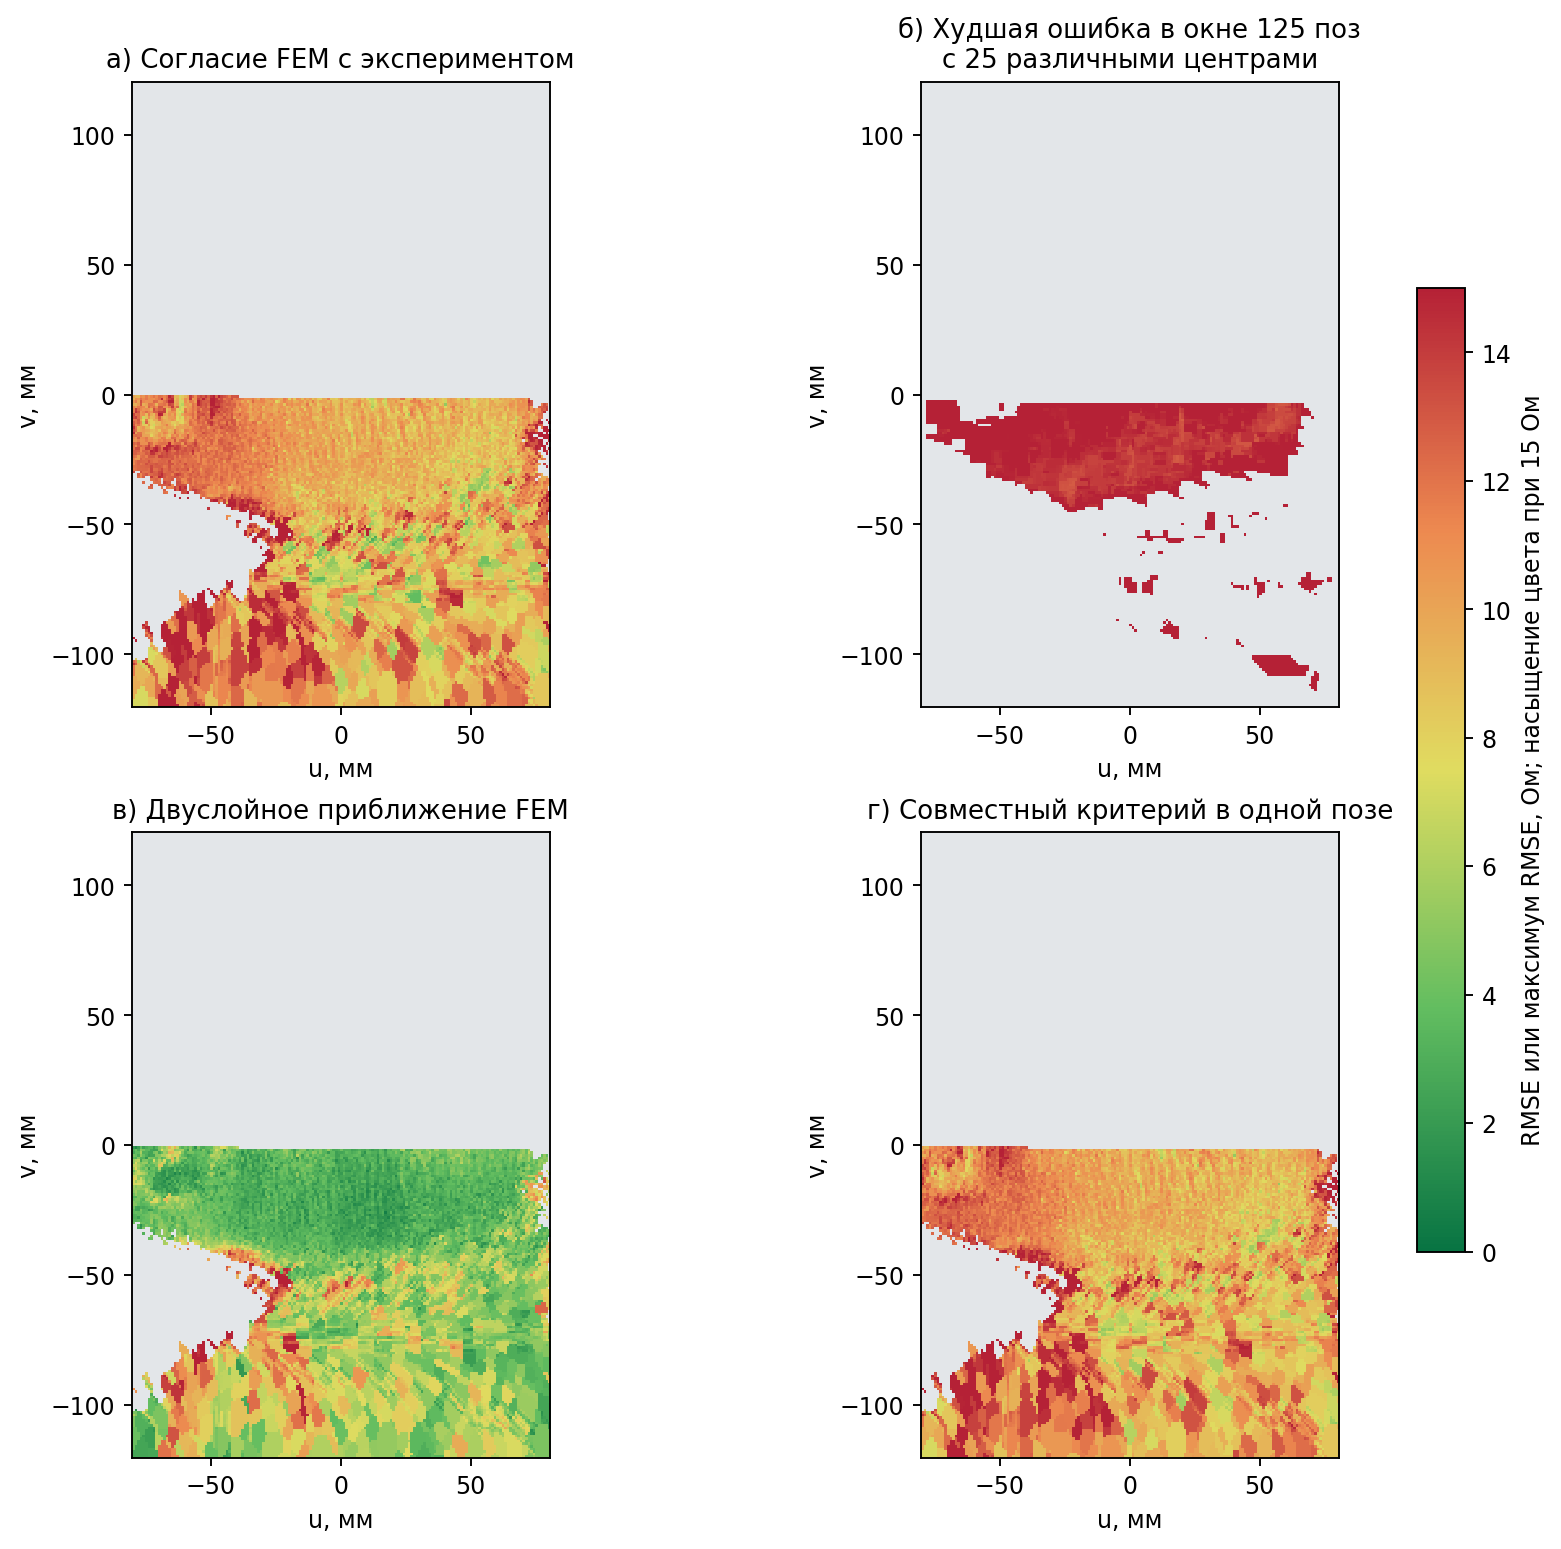

*Рисунок 20.1. Карты критериев на сохранённой параметрической сетке локализации. По координатам $u$ и $v$ показаны: а — минимум ошибки FEM относительно эксперимента по углу в каждом центре; б — минимум худшей ошибки в полностью рассчитанном окне 5×5×5; в — минимум ошибки двуслойного приближения для FEM-кривой; г — минимум большей из двух ошибок в одной и той же позе. Единицы $u$ и $v$ — мм, ошибки — Ом; для каждой панели цвет выбирает наилучший доступный угол. Чем меньше ошибка, тем зеленее цвет, а при 15 Ом шкала насыщается. Серый цвет означает отсутствие пригодного значения из-за геометрического отказа, маски или отсутствия расчёта и не равен нулевой ошибке. Карта описывает обработанную часть перебора и не доказывает минимум непрерывной позы. Следующая проверка — локальное дискретное окно и контроль исключённых размеров.*

### 20.5. Выбранная поза и координаты электродов

Минимальная ошибка к эксперименту среди рассчитанных допустимых поз равна **2,881827921 Ом** при $u=13$ мм, $v=-55$ мм и $\varphi=14°$. В сопроводительных таблицах эта поза обозначена C01. Её проецируемый центр в исходной системе координат КТ/FEM равен приблизительно **(−187,500; 31,051; −138,051) мм**. Это координаты численного кандидата; без пространственной регистрации они не задают точку на теле при повторном исследовании.

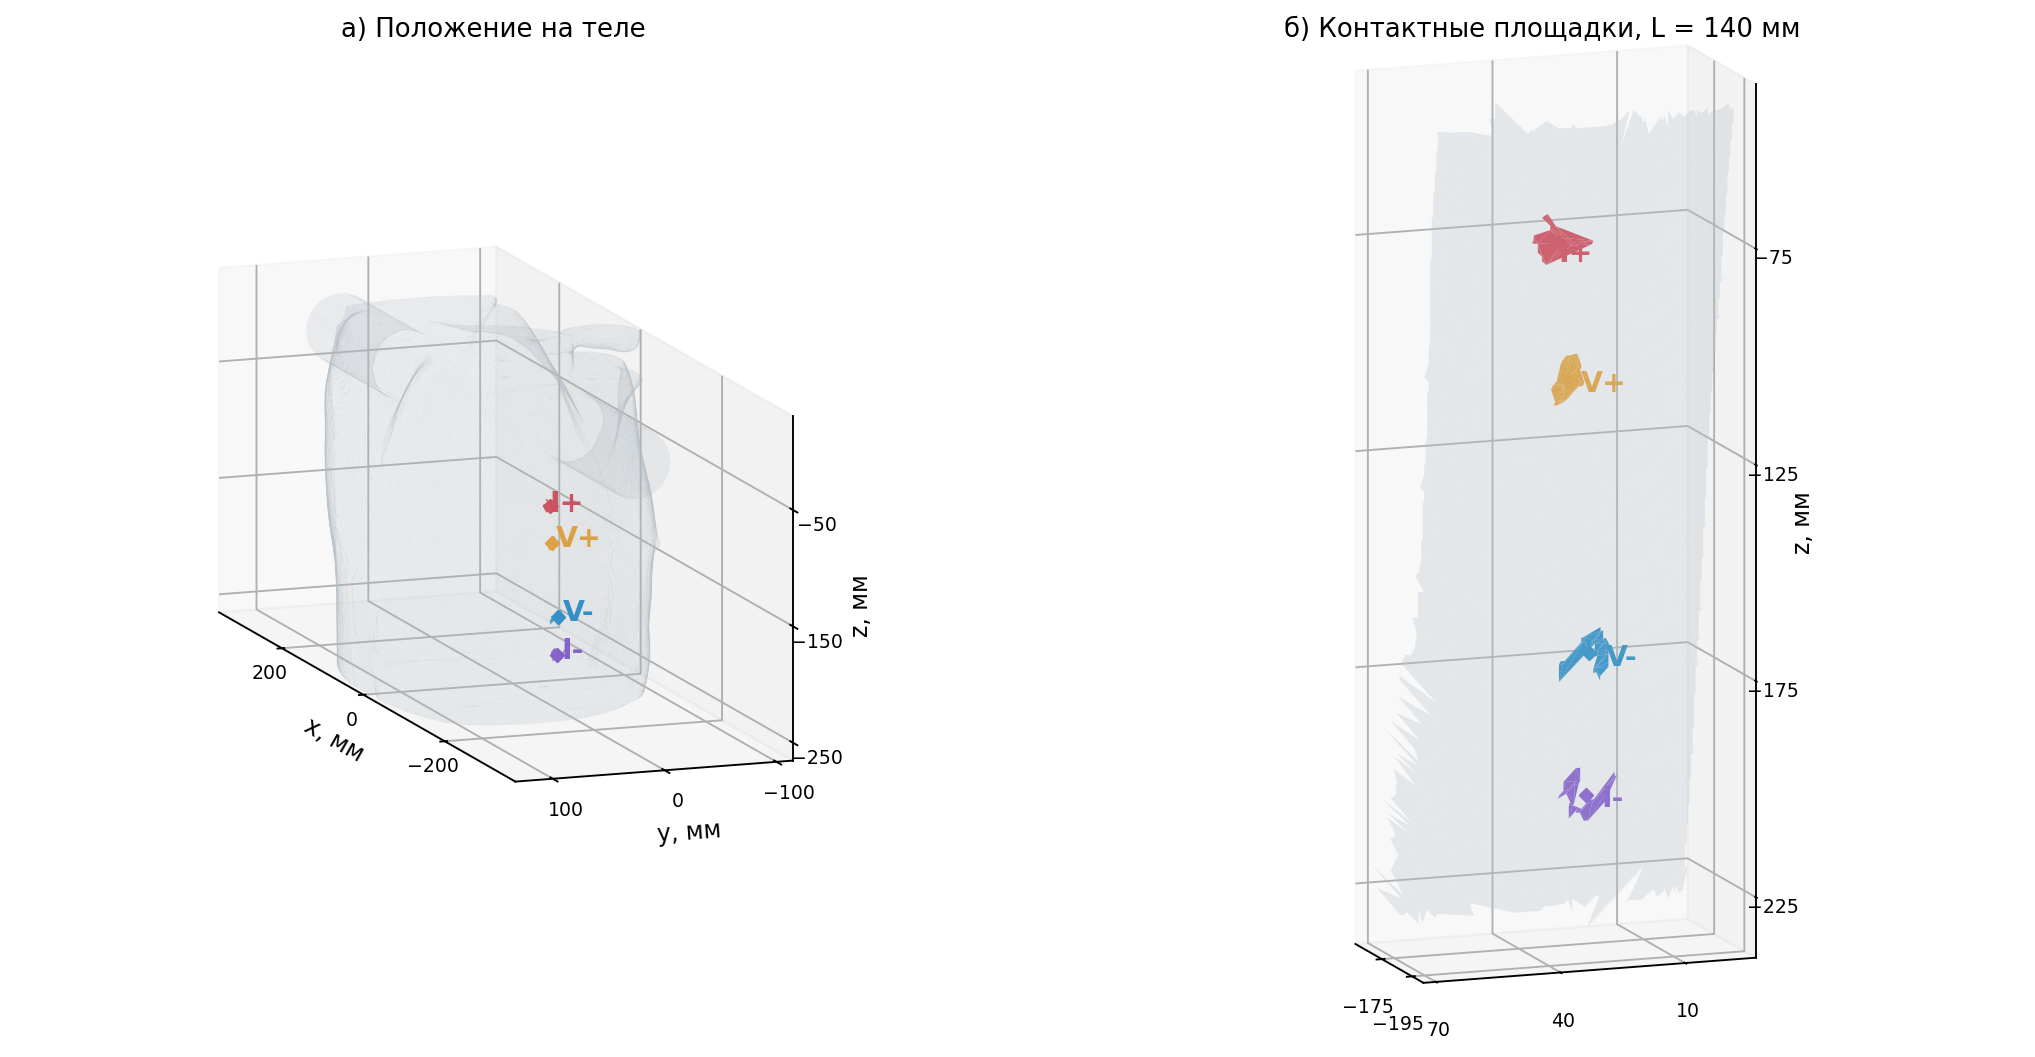

*Рисунок 20.2. Пространственное положение электродных площадок в кандидате C01. На панели а показана вся индивидуальная поверхность тела и все сборки, на панели б — локальный фрагмент для $L=140$ мм. Цветом обозначены фактические треугольные площадки CEM: $I+$ и $I-$ — токовые, $V+$ и $V-$ — измерительные контакты; ромбы показывают их центры площади. Координаты $x$, $y$, $z$ заданы в мм исходной системы КТ/FEM. Изображены контакты численной модели, а не фотографически восстановленная наклейка; поэтому фигура подтверждает сохранённую геометрию расчёта, но не фактическую установку на теле. Следующая таблица даёт координаты и площади без визуального округления.*

| Электрод | x центра площади, мм | y, мм | z, мм | Площадь, мм² |
| --- | --- | --- | --- | --- |
| I+ | -198,780 | 38,952 | -70,929 | 83,00 |
| V+ | -193,848 | 35,113 | -103,976 | 72,85 |
| V- | -178,607 | 24,531 | -171,100 | 89,11 |
| I- | -169,681 | 22,033 | -205,772 | 72,76 |

*Таблица 20.2. Координаты центров площади и фактические площади четырёх контактов при L = 140 мм. Округление в таблице служит для чтения и не задаёт точность физической локализации.*

Для 15 показательных кандидатов сохранены 540 электродных записей: четыре контакта для девяти размеров. Проектируемый центр электрода и центр площади CEM-контакта записаны отдельно; максимальная разность в этом наборе достигает 4,439 мм. Их отождествление создало бы дополнительную геометрическую ошибку. Доступны [координаты всех размеров выбранной позы](../MATLAB_TRKG4_real_subjects/output/exploratory/scan_localization_20260910/best_pose_review/best_electrodes_all_sizes.csv) и [координаты всех кандидатов](../MATLAB_TRKG4_real_subjects/output/exploratory/scan_localization_20260910/candidate_electrodes.csv).

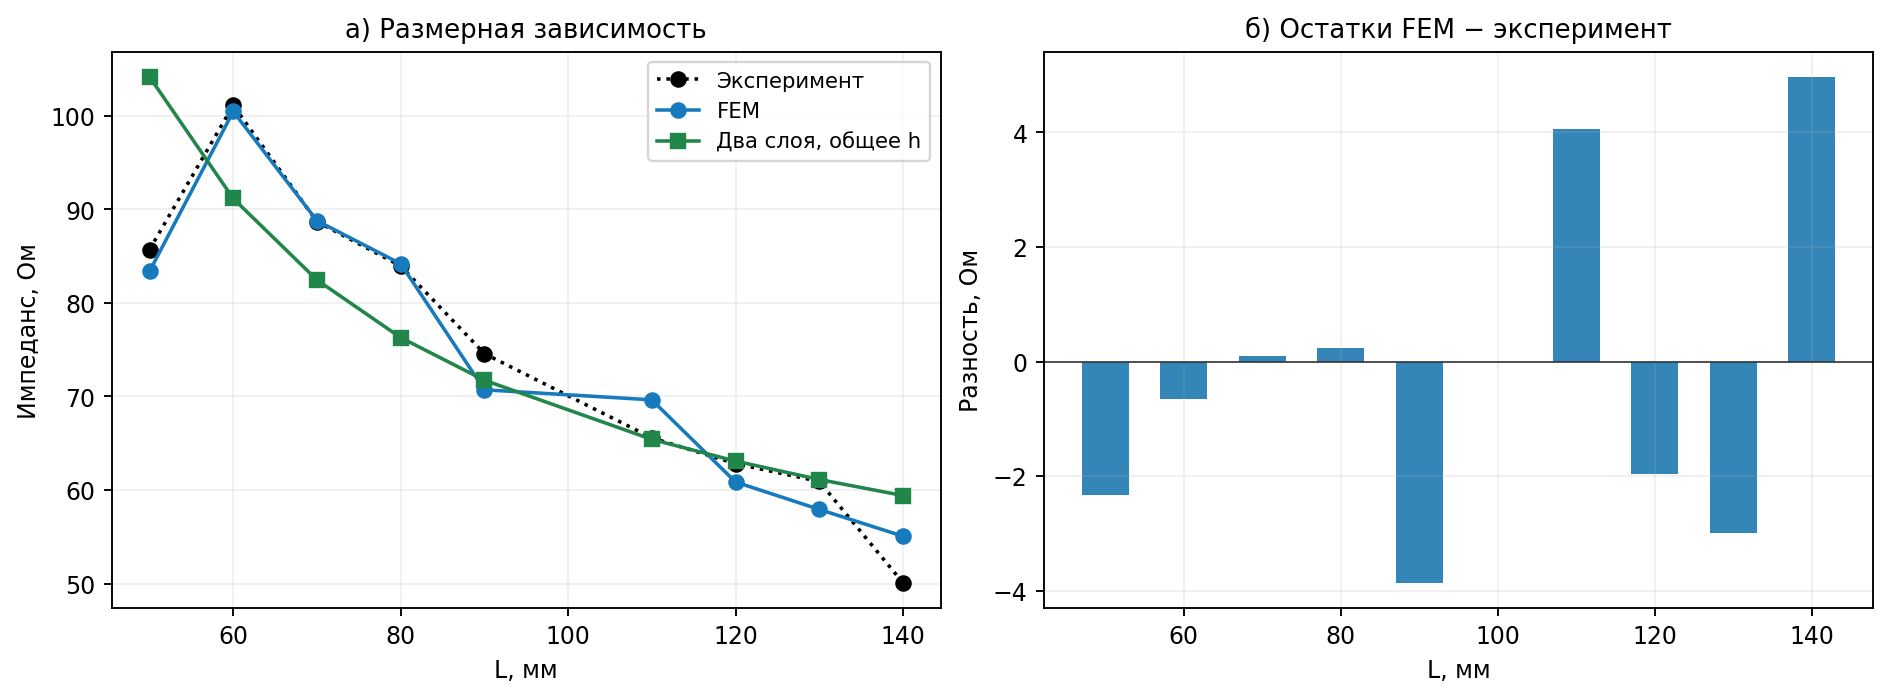

*Рисунок 20.3. Сопоставление размерных зависимостей в выбранной позе. На панели а по оси $L$ отложен номинальный размер сборки, мм, по оси $Z$ — импеданс, Ом; показаны эксперимент, FEM и двуслойная модель с одной общей подобранной толщиной. На панели б приведены остатки $Z_{\rm FEM}-Z_{\rm эксп}$ для каждого размера, поэтому знак показывает направление расхождения. Линии соединяют дискретные наблюдения и не задают непрерывную зависимость. Доверительные интервалы не строились: распределение ошибок и независимость последовательных записей не установлены.*

### 20.6. Что доказывает проверка минимума

Повторное вычисление критерия из всех 475 090 сохранённых FEM-векторов установило единственный минимум среди этих допустимых поз; равенств в пределах 10⁻¹⁰ Ом не найдено. Следующая поза имеет тот же центр и угол 13°; её RMSE равна 2,931431723 Ом, то есть выше на 0,049603802 Ом.

Локальное окно с отклонениями не более одного шага по каждому параметру содержит 27 поз, включая выбранную: 15 допустимых, 12 отвергнутых геометрическим контролем и ни одной непроверенной. Для всех остальных допустимых поз этого окна выполняется строгое неравенство:

$$
E_{\mathrm{exp}}(\boldsymbol\theta_*)<
E_{\mathrm{exp}}(\boldsymbol\theta)
\quad\text{для всех}\quad
\boldsymbol\theta\in\mathcal S\cap\mathcal N_1(\boldsymbol\theta_*),
\quad \boldsymbol\theta\ne\boldsymbol\theta_*,
$$

где $\boldsymbol\theta_*$ — выбранная поза; $\mathcal S$ — множество рассчитанных поз, прошедших геометрический контроль; $\mathcal N_1$ — окно ±1 мм по параметрам $u,v$ и ±1° по углу; $E_{\mathrm{exp}}$ — определённая выше ошибка, Ом. Полнота проверенного локального окна позволяет говорить о строгом минимуме на его **дискретном допустимом множестве**.

| Изменение параметра | RMSE, Ом |
| --- | --- |
| v − 1 | 10,298911 |
| u − 1 | Отказ геометрического контроля |
| φ − 1 | 2,931432 |
| φ + 1 | 5,844396 |
| u + 1 | 10,255963 |
| v + 1 | Отказ геометрического контроля |

*Таблица 20.3. Шесть осевых соседей при изменении только одного параметра на один шаг. Остальные параметры равны значениям выбранной позы.*

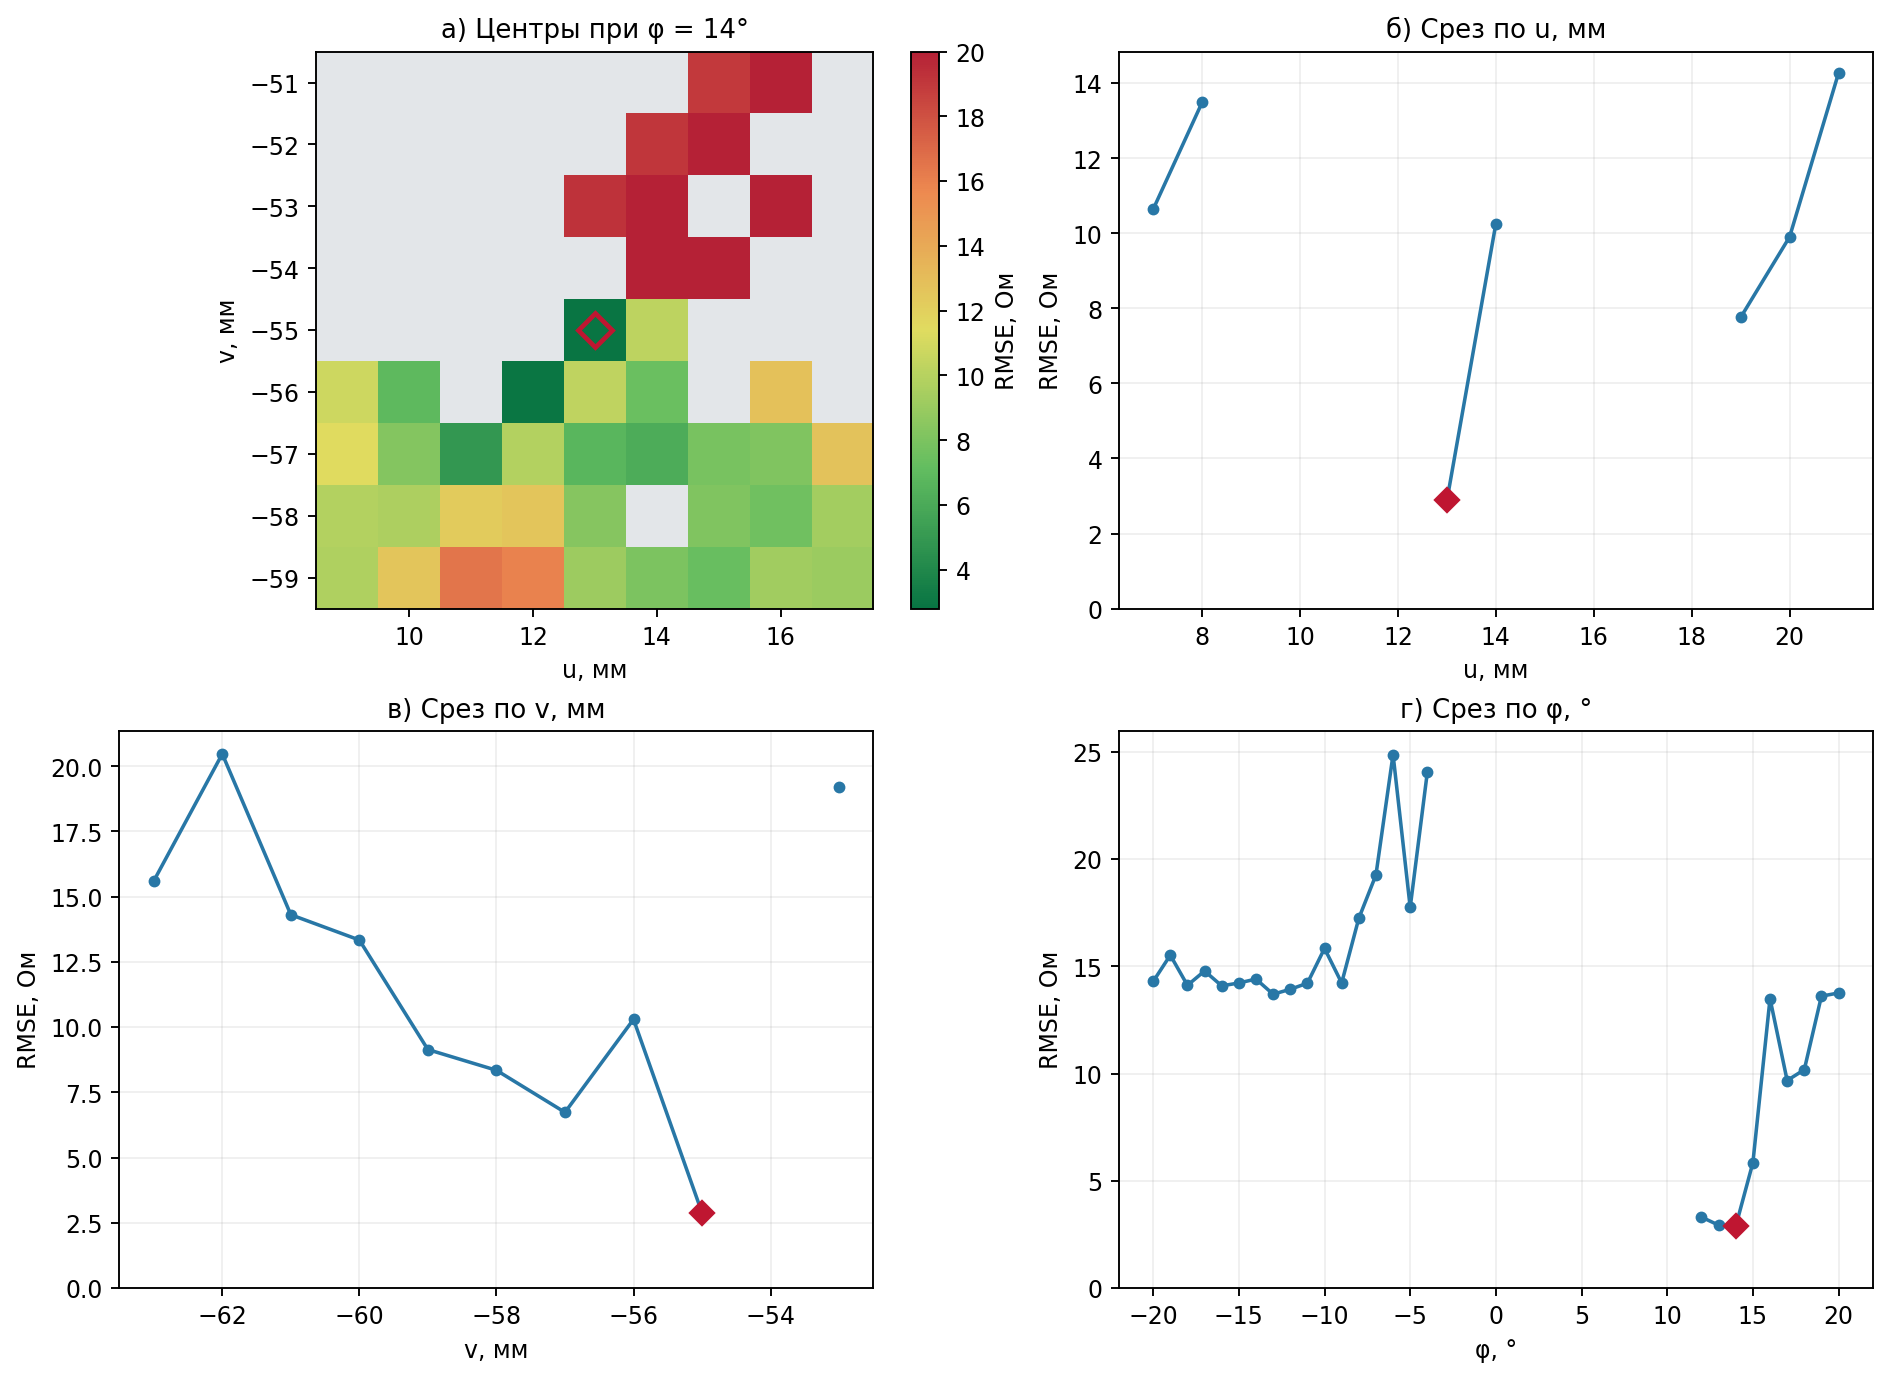

*Рисунок 20.4. Локальная структура дискретной ошибки вокруг C01. На панели а показана RMSE в плоскости $(u,v)$ при фиксированном $\varphi=14^\circ$; на панелях б–г приведены срезы при изменении одного параметра. Координаты $u$ и $v$ выражены в мм, угол — в градусах, ошибка — в Ом. Ромб отмечает C01, серые ячейки и разрывы линий — позы без пригодного FEM-значения. Рисунок подтверждает локальный минимум на узлах сохранённой сетки, но не форму функции между ними и не непрерывную точность координат.*

Это проверка перебором с точностью сохранённых полевых решений. Она не доказывает минимум при непрерывном перемещении: шаги меньше 1 мм по параметрам и 1° по углу не исследованы. Она также не доказывает минимум на всей незавершённой сетке или при совместном изменении сопротивлений. Ошибка пространственной FEM-дискретизации в разность 0,0496 Ом этой проверкой не включена.

### 20.7. Чувствительность выбора к данным

Малая разность ошибок первой и второй поз требует проверки устойчивости ранжирования. Для фиксированной библиотеки FEM-векторов рассчитано наименьшее среднеквадратическое изменение экспериментального вектора, при котором выбранная поза может сравняться по ошибке с конкурентом:

$$
r_* = \min_{q\ne p}
\frac{\|\mathbf z_q-\mathbf y\|_2^2-
      \|\mathbf z_p-\mathbf y\|_2^2}
{2\sqrt N\,\|\mathbf z_q-\mathbf z_p\|_2}
=0{,}077441953\ \text{Ом},
$$

где $p$ — индекс выбранной позы; $q$ — индекс другой рассчитанной допустимой позы с отличным FEM-вектором; $\mathbf z_p,\mathbf z_q$ — векторы девяти FEM-импедансов, Ом; $\mathbf y$ — экспериментальный вектор, Ом; $N=9$; $\|\cdot\|_2$ — евклидова норма; $r_*$ — порог по RMS возмущения данных, то есть по $\|\delta\mathbf y\|_2/\sqrt N$, Ом; $\delta\mathbf y$ — изменение экспериментального вектора, Ом. Формула следует из расстояния до гиперплоскости равных квадратов ошибок двух векторов.

При возмущении с RMS меньше этого порога выбранная поза остаётся единственным минимумом данной библиотеки. На пороге существует направление возмущения, создающее равенство; конкурентом является тот же центр с углом 13°. Проверка возмущения вдоль разности FEM-векторов подтвердила смену порядка после увеличения порогового возмущения на 1%. Порог **не является измеренным шумом или доверительной границей**: библиотека FEM здесь условно считается точной, а экспериментальная модель ошибки не задана.

Дополнительно локализация повторена девять раз по восьми размерам с прогнозом исключённого девятого. В каждом повторе сравнивались все сохранённые допустимые позы. Исходная поза выбрана только в трёх из девяти случаев. При исключении 50 мм центр смещается приблизительно на 33 мм, а ошибка прогноза этого размера превышает 40 Ом.

| Исключённый L, мм | u; v, мм | φ, ° | Смещение центра, мм | Ошибка исключённого размера, Ом |
| --- | --- | --- | --- | --- |
| 50 | -13; -85 | 1 | 33,00 | 40,34 |
| 60 | 13; -55 | 14 | 0,00 | -0,66 |
| 70 | 11; -56 | 17 | 0,87 | 18,92 |
| 80 | 9; -55 | 17 | 2,98 | 12,58 |
| 90 | 26; -78 | -7 | 22,75 | -9,31 |
| 110 | 13; -55 | 12 | 0,00 | 6,51 |
| 120 | 13; -55 | 14 | 0,00 | -1,96 |
| 130 | 26; -71 | 9 | 19,50 | -5,94 |
| 140 | 13; -55 | 14 | 0,00 | 4,97 |

*Таблица 20.4. Локализация с поочерёдным исключением размера. Смещение — евклидово расстояние между проецируемыми центрами в координатах КТ; нулевое смещение не исключает изменения угла. Подписанная ошибка относится только к исключённому размеру.*

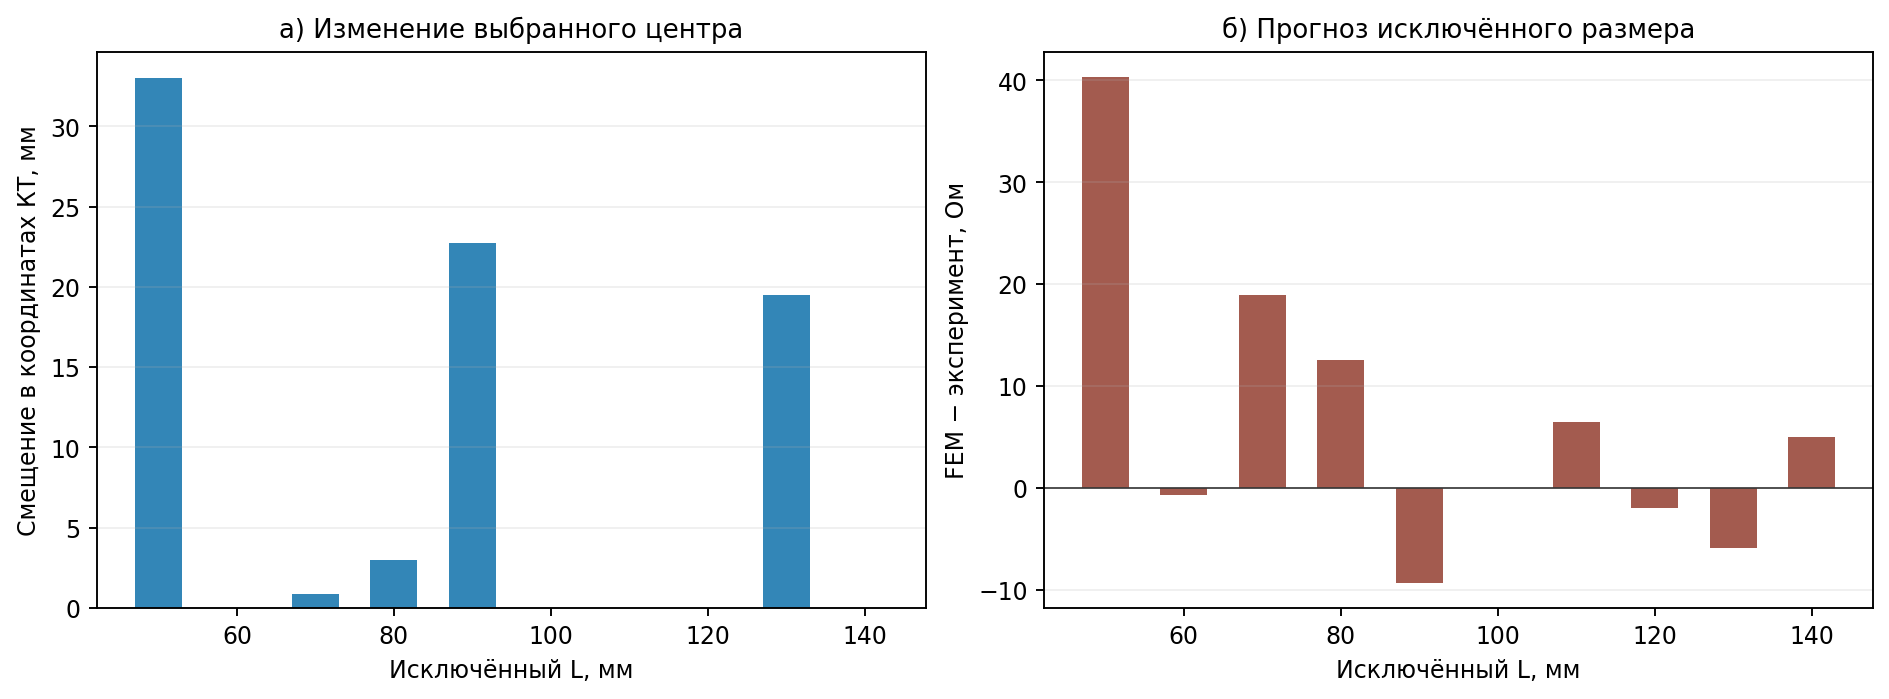

*Рисунок 20.5. Устойчивость локализации при поочерёдном исключении размера. Для каждого исключённого $L$, мм, показаны смещение выбранного проецируемого центра, мм, и подписанная ошибка прогноза исключённого импеданса, Ом. Нулевое смещение не исключает изменения угла; девять повторов используют один и тот же набор последовательных записей и не являются независимыми экспериментами. Рисунок проверяет зависимость выбора от состава размерного ряда, но не даёт статистической оценки точности установки.*

### 20.8. Роль ранее подобранных удельных сопротивлений

**В данном полном переборе сопротивления не варьировались.** Для всех центров и поворотов использовалась одна пара ρ₁, ρ₂, приведённая в разделе 20.3. Последующий подбор общей толщины также сохранял эту пару.

До этого выполнялся совместный прямой поиск пяти параметров: двух сопротивлений, двух координат центра и угла. Сохранённая история содержит 100 оценок и 24 различные пары сопротивлений; поиск завершён по лимиту вычислений. В этой истории ρ₁ изменялось приблизительно от 4,615 до 6,115 Ом·м, а ρ₂ — от 21,707 до 32 Ом·м. Это диапазоны фактически проверенных значений, а не доверительные интервалы.

Предыдущий критерий включал функцию Хьюбера от остатков, дополнительный штраф за форму размерной зависимости и априорные штрафы для глубины и сопротивления лёгкого. Он отличается от текущей равновзвешенной RMSE. Его лучший сохранённый кандидат имел RMSE около 7,288 Ом и другую позу. Перенос сопротивлений из этой подгонки делает нынешний минимум условным; ни завершённость совместной оптимизации, ни независимое восстановление сопротивлений этим не доказаны. Происхождение зафиксировано в [сводке прежнего поиска](../MATLAB_TRKG4_real_subjects/output/nik_trkg4_inverse_direct_search_summary_auditfix_20260908.json).

### 20.9. Двуслойное приближение с одной общей толщиной

Для каждой FEM-кривой подбирается только одна эффективная толщина. Верхний слой и нижнее полупространство имеют фиксированные сопротивления ρ₁ и ρ₂. Четыре точечных электрода расположены на одной прямой: I+, V+, V−, I− имеют координаты −L/2, −L/4, L/4, L/2 соответственно. Положительный передаточный импеданс задаётся разностью потенциалов V+ и V−, делённой на ток I+.

$$
\begin{aligned}
Z_{\mathrm{2L}}(h,L)&=\frac{\rho_1}{\pi}
\left[D_L(0)+2\sum_{n=1}^{\infty}q^nD_L(2nh)\right],\\
D_L(t)&=\frac{1}{\sqrt{(L/4)^2+t^2}}
-\frac{1}{\sqrt{(3L/4)^2+t^2}},\\
q&=\frac{\rho_2-\rho_1}{\rho_2+\rho_1},
\end{aligned}
$$

где $Z_{\mathrm{2L}}$ — двуслойный передаточный импеданс, Ом; $h$ — толщина верхнего слоя, м; $L$ — расстояние между внешними токовыми электродами, м; $t$ — вспомогательное расстояние, м; $D_L$ — геометрическая функция, м⁻¹; $\rho_1,\rho_2$ — удельные сопротивления, Ом·м; $q$ — безразмерный коэффициент отражения; $n$ — положительный целочисленный номер члена ряда. Перед вычислением длины из таблиц переводятся из миллиметров в метры умножением на 10⁻³.

Для каждой позы минимизируется ошибка по всем девяти размерам:

$$
\begin{aligned}
F(h;\boldsymbol\theta)&=\sqrt{\frac1N\sum_{i=1}^N
\left[Z_{\mathrm{2L}}(h,L_i)-z_i(\boldsymbol\theta)\right]^2},\\
E_{\mathrm{2L}}(\boldsymbol\theta)&=\min_{h\ge0}F(h;\boldsymbol\theta),\\
h_{\mathrm{eff}}(\boldsymbol\theta)&\in\operatorname*{arg\,min}_{h\ge0}F(h;\boldsymbol\theta),
\end{aligned}
$$

где $F$ — RMSE двуслойного приближения при заданных толщине и позе, Ом; $E_{\mathrm{2L}}$ — её минимальное значение, Ом; $h_{\mathrm{eff}}$ — выбранная общая эффективная толщина, м; $\boldsymbol\theta$ — фиксированная поза; $L_i$ — размер сборки, м; $z_i$ — FEM-импеданс, Ом; $N=9$; $Z_{\mathrm{2L}}$ — определённая выше аналитическая функция. В расчёте отдельно проверен предел при $h\to\infty$; он включён в сравнение с конечными кандидатами. Отдельные толщины для каждого размера, дополнительный масштаб и сдвиг отсутствуют.

Адаптивная аппроксимация ряда охватывает неотрицательную полуось и её предельный отклик. В используемом алгоритме оценка ошибки глобального минимума RMSE не превышает 0,001 Ом; итоговые импедансы пересчитаны исходным аналитическим рядом. Все 475 090 найденных минимумов имеют конечную толщину. Медиана $h_{\mathrm{eff}}$ составляет 25,243 мм, медиана ошибки к FEM — 8,669 Ом. Это медианы по параметрическим позам данного снимка, а не популяционные характеристики тканей.

При исключении по одному размеру дополнительно выполнены 4 275 810 подгонок толщины по восьми размерам с прогнозом девятого; медиана RMSE таких прогнозов равна 9,466 Ом. В отличие от раздела 20.7, здесь **поза фиксирована**, а повторно выбирается только толщина. Проверка оценивает воспроизведение размерной зависимости, но не анатомическую идентифицируемость толщины.

### 20.10. Совместимость двух критериев и отрицательный результат

| Критерий выбора | u; v, мм | φ, ° | FEM ↔ эксперимент, Ом | Два слоя ↔ FEM, Ом | h, мм |
| --- | --- | --- | --- | --- | --- |
| Минимум ошибки к эксперименту | 13; -55 | 14 | 2,882 | 8,649 | 24,704 |
| Минимум ошибки двуслойного приближения | 17; -26 | 13 | 10,073 | 0,530 | 29,824 |
| Минимум большей из двух ошибок | 13; -77 | -8 | 4,664 | 4,535 | 24,877 |

*Таблица 20.5. Три разных решения: минимум ошибки к эксперименту, минимум ошибки двуслойного приближения и минимум большей из этих двух ошибок. Параметры сопротивлений одинаковы во всех строках.*

Совместный критерий в каждой позе определяется как максимум двух ошибок:

$$
E_{\mathrm{joint}}(\boldsymbol\theta)=
\max\left\{E_{\mathrm{exp}}(\boldsymbol\theta),
E_{\mathrm{2L}}(\boldsymbol\theta)\right\},
$$

где $E_{\mathrm{joint}}$ — совместная ошибка, Ом; $E_{\mathrm{exp}}$ — ошибка FEM к эксперименту, Ом; $E_{\mathrm{2L}}$ — ошибка двуслойного приближения той же FEM-кривой, Ом; $\boldsymbol\theta$ — одна и та же поза. Минимумы по углу для двух ошибок по отдельности не объединяются в фиктивную общую позу.

Ошибка к эксперименту ниже 5 Ом получена для 196 поз в 132 параметрических центрах, ниже 3 Ом — для трёх поз в двух центрах. Обе ошибки одновременно ниже 5 Ом имеют только четыре позы в трёх центрах: $(u,v,\varphi)=(13,-77,-8)$, $(26,-80,9)$, $(26,-80,10)$ и $(57,-47,12)$; координаты выражены в миллиметрах, углы — в градусах. Эти пороги являются исследовательскими сценариями, а не доверительными областями или клиническими критериями пригодности.

При выбранных сопротивлениях ρ₂ > ρ₁ все дополнительные члены ряда неотрицательны. Поэтому существует нижняя граница:

$$
Z_{\mathrm{2L}}(h,L)\ge\frac{8\rho_1}{3\pi L},
$$

где $Z_{\mathrm{2L}}$ — импеданс, Ом; $h\ge0$ — толщина, м; $L$ — размер сборки, м; $\rho_1$ — сопротивление верхнего слоя, Ом·м. При L = 50 мм граница равна 94,257 Ом, тогда как FEM в лучшей экспериментальной позе даёт 83,364 Ом. Следовательно, никакая толщина при этой паре сопротивлений не воспроизведёт данный компонент FEM-вектора.

Даже непосредственный подбор общей толщины к экспериментальному вектору при тех же сопротивлениях даёт минимальную RMSE 8,378 Ом. Это отрицательный результат для выбранного упрощения и фиксированных параметров. Он не доказывает неисправность прибора и не исключает другие сопротивления или модели контакта и анатомии.

### 20.11. Эффективная толщина и геометрия КТ

В центрах с допустимыми позами выполнена трассировка луча по внутренней нормали к внешней поверхности. Первый вход в лёгкое найден для 15 977 центров; в 978 центрах пересечения не найдено в диапазоне 600 мм. Отсутствие пересечения в этом диапазоне не заменяется нулевой толщиной. Замкнутость поверхностей лёгкого и кости проверена; в одном костном луче пересечения не образовали надёжных пар, поэтому соответствующая длина кости не выдана.

Глубина первого входа доступна для 459 231 параметрической позы. При её подстановке вместо подбора толщины медиана RMSE к FEM составляет 16,652 Ом. На том же наборе подбор общей толщины даёт медиану 8,662 Ом. Медиана разности «эффективная толщина минус глубина по нормали» равна −29,070 мм.

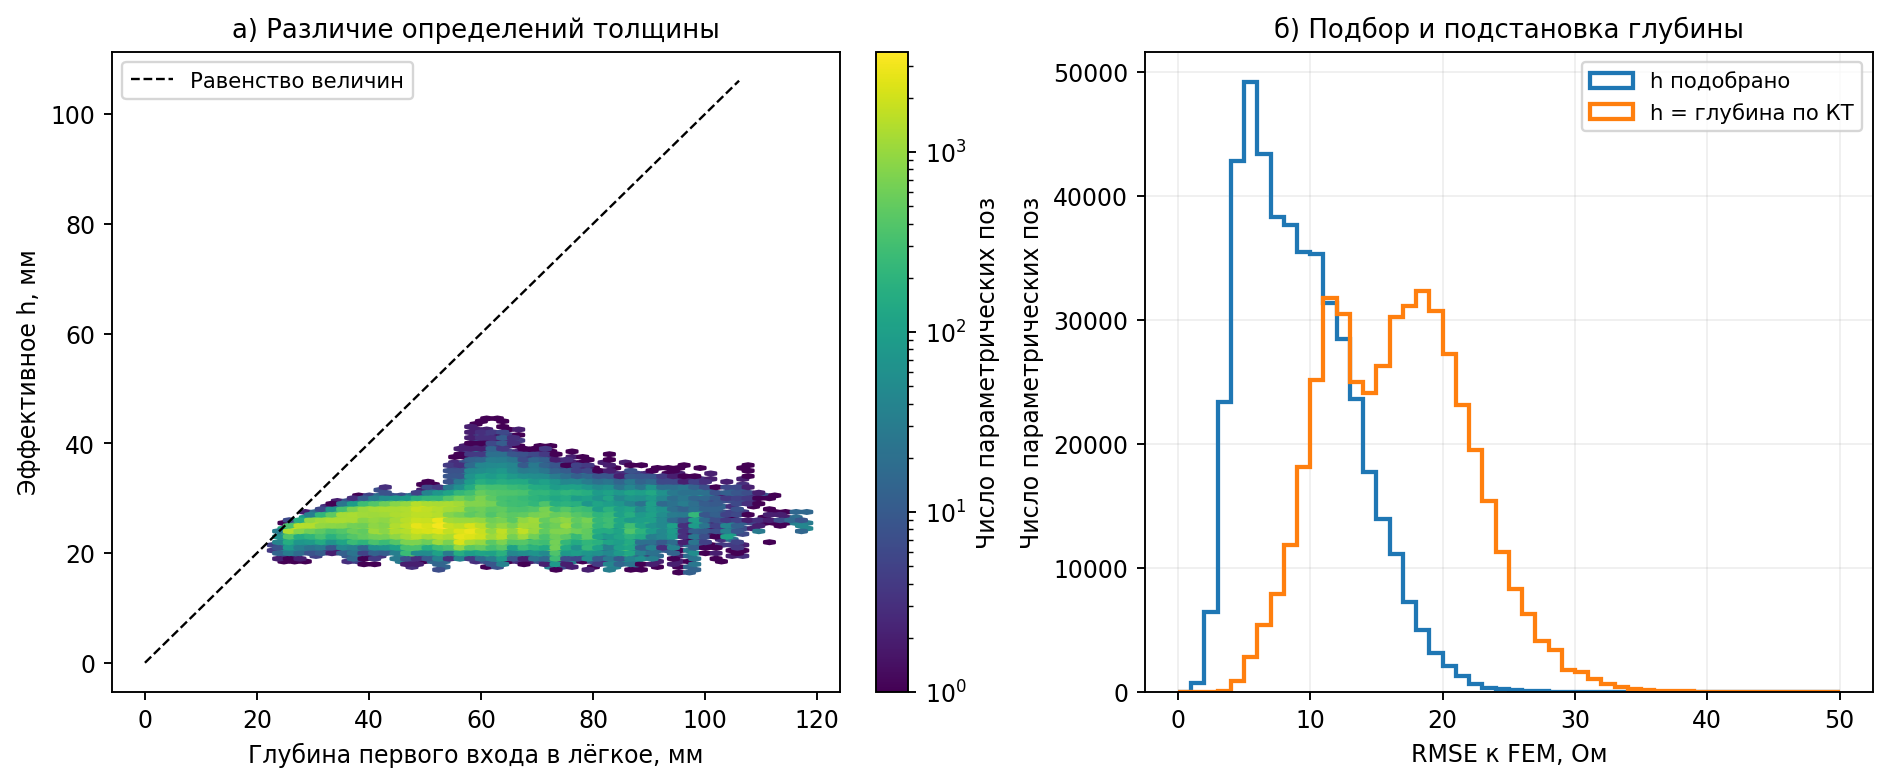

*Рисунок 20.6. Сравнение эффективной и геометрической толщины. На панели а по обеим осям отложена толщина в мм: $h_{\rm eff}$, найденная по электрическому критерию, и глубина первого входа в лёгкое по нормали КТ; штриховая линия обозначает равенство, цвет — число поз в ячейке. На панели б показаны распределения RMSE к FEM при подборе общей толщины и при прямой подстановке глубины КТ; ошибка выражена в омах, диапазон ограничен 50 Ом. Частоты относятся к элементам перебора, а не к независимым наблюдениям. Различие распределений показывает, что электрически эффективная толщина не может автоматически считаться анатомической; следующая задача — оценить её устойчивость и неопределённость отдельно от подгонки.*

Геометрический путь до лёгкого может включать мягкие ткани и кость. Он не равен отдельно измеренной толщине мягких тканей. Эффективная толщина компенсирует совокупное расхождение аналитической модели и FEM; её нельзя автоматически объявлять анатомической. Использовавшееся ранее расстояние до ближайшей вершины поверхности также имеет иное определение и не заменяет нормальную глубину.

Для кандидатов сохранены профили глубины, длина первого лёгочного интервала, длины костных участков перед лёгким и квадратичная одномерная характеристика изгиба лёгочной границы вдоль оси сборки. Последняя описывает выбранное направление и не является главной кривизной трёхмерной поверхности. Влияние кривизны, конечности лёгкого, костей, внешнего контура и конечного контакта пока не разделено причинным вычислительным экспериментом.

### 20.12. Пространственная устойчивость и вырождение параметризации

Дополнительный сценарий использует окно ±2 шага по обеим координатам и углу: 125 поз. Требуется, чтобы все они были рассчитаны и допустимы. Ни для одной области этого сценария ошибка к эксперименту во всех позах не остаётся ниже 10 Ом. У лучшей экспериментальной позы допустимы 69 из 125 поз, а ошибка среди них достигает 23,551 Ом; 56 поз отвергнуты геометрическим контролем. У компромиссной позы допустимы 79 из 125, а максимальная ошибка равна 24,153 Ом.

Проверка проекций показала, что 16 955 параметрическим центрам с допустимыми позами соответствуют только 10 908 различных координатных точек при округлении до 10⁻⁶ мм. В 92 центрах все 25 соседних проецируемых центров совпадают. Поэтому формально лучшее значение худшей ошибки 10,315 Ом не проверяет устойчивость к перемещению: центр в таком окне вообще не меняется.

После дополнительного требования 25 различных проекций и ненулевого пространственного разброса по двум направлениям минимум худшей ошибки составляет 12,679 Ом. Для этого сценария второй сингулярный показатель пространственного разброса должен превышать 0,001 мм; это численный порог отбраковки вырожденного окна, а не измеренная погрешность установки. У компромиссной позы изменение на два шага по обеим координатам может сместить центр на 6,349 мм и изменить нормаль до 18,153°.

Следовательно, рассмотренное окно — сценарий параметрической сетки. Оно не описывает равномерную ошибку наклейки ±2 мм на теле. Для такой интерпретации требуется отдельная геометрическая постановка в физических касательных координатах и проверка дискретизации контактов.

### 20.13. Выполненные проверки и границы доказательства

| Утверждение | Основание | Статус и предел вывода |
|---|---|---|
| Выбранная поза имеет минимальную RMSE в сохранённом допустимом наборе | Повторное вычисление критерия по всем 475 090 векторам; проверка соседей | Подтверждённый вычислительный факт для дискретного множества при фиксированных сопротивлениях |
| Изображённые контакты соответствуют сохранённому CEM | Повторное суммирование площадей и центров треугольников | Максимальные расхождения около 7,1·10⁻¹⁴ мм² и 5,4·10⁻¹³ мм; подтверждает экспорт геометрии, а не реальную наклейку |
| Подбор общей толщины выполнен согласованно с аналитическим рядом | Контроль граничных случаев, оценка аппроксимации и независимые повторные минимизации | На 50 реальных позах в 200 повторных поисках максимальное расхождение RMSE около 4,1·10⁻⁶ Ом; это проверка численного метода |
| Часть поз одновременно согласуется с экспериментом и двуслойным приближением при пороге 5 Ом | Совместный критерий в одной позе | Четыре кандидата; порог сценарный, устойчивость области не установлена |
| Фактическая установка восстановлена однозначно | Независимого пространственного референса нет | Нерешённый вопрос; чувствительность ранжирования и исключение размеров ограничивают такой вывод |
| Эффективная толщина заменяет измерение анатомии | Сравнение с глубиной по КТ показывает различие величин | Не подтверждено; переход к сокращённому протоколу требует отдельной проверки |

Самоконтроль кода, согласие двух реализаций и сохранность файлов не заменяют сеточной сходимости FEM, независимой метрологической проверки и повторного эксперимента. Не установлены точность непрерывной локализации, неопределённость тканевых параметров, влияние сегментации и контакта, перенос на другое дыхательное состояние или другую сессию. Значения сердца, лёгкого и мягких тканей не интерпретируются как независимо восстановленные физиологические параметры только на основании близости базовых импедансов.

**Итог данного этапа.** Получен прослеживаемый кандидат установки и доказан его дискретный минимум в сохранённой части перебора. Одновременно обнаружены малая устойчивость ранжирования к изменению данных, зависимость локализации от состава размерного ряда и различие эффективной и геометрической толщин. Поэтому результат пригоден как исходная гипотеза для следующей проверки, но пока не обосновывает исключение индивидуальной КТ или сокращение измерений до двух сборок.

### 20.14. Воспроизводимость и дополнительные материалы

В ноутбуке сохранены исходные вычислительные ячейки и их численные выходы. Настоящий раздел сформирован из существующих массивов FEM, результатов подбора толщины, геометрических таблиц и проверки минимума. Контрольные суммы связывают текст, рисунки и входные файлы; подготовка рисунков не запускает полевой расчёт.

| Материал | Назначение |
|---|---|
| [Контракт исходных массивов](../MATLAB_TRKG4_real_subjects/output/exploratory/scan_localization_20260910/input_contract.json) | Состав снимка, параметры и происхождение данных |
| [Сводка подбора толщины](../MATLAB_TRKG4_real_subjects/output/exploratory/scan_localization_20260910/fit_summary.json) | Критерий, охват и численные результаты |
| [Численная проверка](../MATLAB_TRKG4_real_subjects/output/exploratory/scan_localization_20260910/numerical_verification.json) | Сопоставление алгоритмов и контроль точности |
| [Сертификат дискретного минимума](../MATLAB_TRKG4_real_subjects/output/exploratory/scan_localization_20260910/best_pose_review/minimum_certificate.json) | Положение кандидата, полный ранг и локальные соседи |
| [Описание происхождения главы](../MATLAB_TRKG4_real_subjects/output/exploratory/scan_localization_20260910/scientific_notebook/chapter_manifest.json) | Контрольные суммы её входов, текста и рисунков |
| [Документация воспроизведения](../MATLAB_TRKG4_real_subjects/docs/PIPELINE_FOR_NOTEBOOKS.md) | Команды подготовки раздела и читательского HTML без исполнения FEM-ячеек |

Индивидуальная анатомия и локальные результаты остаются в исследовательском хранилище; включение их в научный ноутбук не означает разрешения на публикацию. Методические источники приведены в разделе 22. Они обосновывают постановки моделей, но не валидируют данный конкретный результат локализации.

## 21. Итоговые положения и границы достигнутого результата

1. **Геометрический результат.** В сечении выбранной боковой сборки существенно меняются глубина первого входа в лёгкое и толщина первого лёгочного интервала; лучи имеют несколько пересечений маски. Одно ближайшее расстояние не описывает всю эту структуру.
2. **Материальное допущение.** В отдельном сравнении упрощений раздела 11.3.1 используются ровно два сопротивления. Все нелёгочные ткани, включая поддиафрагмальные, объединены. Последовательность из трёх и более слоёв не увеличивает автоматически число материальных параметров.
3. **Выполненное сравнение.** Рассчитаны десять вариантов при одинаковых двух сопротивлениях исходного примера. Из рассмотренных простых усреднений наименьшую RMS относительно двухтканного FEM имеет исходная схема со средней глубиной по паре. Это локальное ранжирование фиксированной постановки, а не установленный оптимум семейства моделей.
4. **Отрицательный результат.** Учёт конечного первого интервала и всех пересечений через выбранные усреднения не уменьшил расхождение с трёхмерным расчётом. Это ограничение этих способов усреднения; оно не доказывает невозможности более точной модели с кривыми границами.
5. **Контролируемый геометрический эффект.** Продолжение лёгочной области после первого входа при неизменных FEM-контактах меняет импеданс на величину до 3,43 Ом. Операция затрагивает все дальние выходы вдоль одного направления; эффект купола диафрагмы отдельно не выделен.
6. **Численные проверки.** Для выполненного сравнения проверены взаимность, предельные случаи слоистых формул и устойчивость используемых квадратур. Сходимость FEM по сетке и чувствительность к внешней границе остаются открытыми.
7. **Обратная задача.** Два сопротивления и поза исходной модели являются условными оценками регуляризованного расчёта. Конечные секущие по дискретным контактам не обосновывают доверительных интервалов положения. Дыхательная линейная подгонка не разделяет тканевые и геометрические механизмы.
8. **Направление продолжения.** Выбор упрощения должен учитывать электрический отклик, его чувствительность, смещение восстановленных параметров, вычислительную стоимость и доступность геометрических входов. Критерии и порядок таких проверок сформулированы в разделе 19.

9. **Локализация по сохранённому перебору.** При фиксированной паре сопротивлений единственный минимум среди 475 090 допустимых рассчитанных поз имеет RMSE 2,882 Ом. Полностью проверенное окно ±1 шага подтверждает строгий дискретный локальный минимум. Незавершённость общей сетки и отсутствие независимых координат установки ограничивают вывод.
10. **Устойчивость результата.** Порог направленного изменения экспериментальных данных, допускающего смену первой позы, составляет 0,0774 Ом по RMS. При исключении одного размера исходная поза выбирается в трёх из девяти повторов. Устойчивая область с ошибкой ниже 10 Ом во всех 125 позах проверенного сценария не установлена.
11. **Общая толщина.** Для всех готовых FEM-кривых найдено одно общее h по девяти размерам. Медиана ошибки двуслойного приближения равна 8,669 Ом; четыре позы одновременно имеют обе ошибки ниже 5 Ом. Эффективная толщина и глубина первого входа в лёгкое по КТ различаются; анатомическая интерпретация h и сокращённый протокол ещё не валидированы.

Настоящая научная редакция сохраняет результаты выполненных расчётов и расширяет их методическое описание. Новая оптимизация сопротивлений, положения электродов или семейства упрощённых моделей при подготовке текста не проводилась. Вычислительные ячейки сохраняют результаты исходных разделов. Таблицы и рисунки раздела 20 получены из отдельно сохранённых массивов перебора и проверок; их происхождение зафиксировано в сопроводительных файлах. Предложения будущих исследований не являются выполненными численными результатами.

## 22. Методические источники и связь с основным корпусом

### 22.1. Проверенные внешние источники

Ссылки ниже используются для конкретных математических методов. Они не служат подтверждением точности данной индивидуальной модели. Библиографические сведения и заявленная область исследований проверены по страницам авторских работ и первичной реализации; полный систематический обзор литературы в рамках этой редакции не выполнялся.

1. **Staboulis S., Dardé J.** *Electrode modelling: The effect of contact impedance*. [Авторская версия](https://arxiv.org/abs/1312.4202), [DOI](https://doi.org/10.1051/m2an/2015049). Источник по влиянию контакта и различию полной и идеализированной электродных моделей; не обосновывает выбранное индивидуальное значение контактного импеданса.
2. **Hyvönen N., Mustonen L.** *Smoothened complete electrode model*, 2017. [Авторская версия](https://arxiv.org/abs/1703.08022). Источник по сглаженной контактной проводимости и регулярности решения; применение к текущей сборке требует отдельного расчёта.
3. **SimPEG.** *Simulation1DLayers*, первичная реализация прямой задачи для горизонтально-слоистой среды. [Исходный код](https://github.com/simpeg/simpeg/blob/main/simpeg/electromagnetics/static/resistivity/simulation_1d.py). Используется для проверки структуры спектральной рекурсии. Приведённый в ноутбуке тетраполярный функционал дополнительно проверяется собственными предельными тестами.
4. **Aykroyd R. G., Cattle B. A.** *A boundary-element approach for the complete-electrode model of EIT illustrated using simulated and real data*. Inverse Problems in Science and Engineering, 2007, 15(5), 441–461. [DOI](https://doi.org/10.1080/17415970600795337). Источник по гранично-элементной постановке CEM при кусочно-постоянных свойствах.
5. **Tyni T., Stinchcombe A. R., Alexakis S.** *A boundary integral equation method for the complete electrode model in electrical impedance tomography with tests on experimental data*. SIAM Journal on Imaging Sciences, 2024, 17(1), 672–705. [Авторская версия](https://arxiv.org/abs/2305.17294), [DOI](https://doi.org/10.1137/23M1585696). В просмотренной постановке рассматривается двумерная область; прямой перенос показателей на трёхмерную грудную клетку не выполняется.
6. **Lipponen A., Seppänen A., Kaipio J.** *Reduced-order model for electrical impedance tomography based on proper orthogonal decomposition*, 2012. [Авторская версия](https://arxiv.org/abs/1207.0914). Методическая основа рассмотрения моделей пониженного порядка. Приведённые авторами показатели ускорения не используются как собственный результат проекта.

### 22.2. Локальная библиотека и границы библиографической проверки

До обращения к внешним источникам проверены математическая подколлекция и подколлекция картирования поля и конечноэлементных моделей библиотеки Zotero проекта, затем выполнен поиск по всей библиотеке по полной электродной модели, граничным элементам и пониженному порядку. В указанных поисках соответствующие методические записи не обнаружены; это результат конкретных запросов, а не доказательство отсутствия всей релевантной литературы.

В тематической подколлекции имеются работы по влиянию расположения электродов на импеданс грудной клетки, в том числе статьи Wang, Haynor и Kim и Kauppinen, Hyttinen и Malmivuo. В настоящей редакции проверены их библиографические метаданные, но их частные количественные результаты в текст не переносились. Автореферат Кризского зарегистрирован в математической подколлекции; он не используется как установленный первоисточник конкретной тетраполярной формулы. При оформлении раздела 20 повторно сверены тематические библиографические метаданные в доступном резервном снимке Zotero от 8 сентября 2026 года; локальный API библиотеки не отвечал. Полные тексты этих работ повторно не анализировались, новые литературные количественные утверждения не добавлены. Записи библиотеки при подготовке отчёта не изменялись.

### 22.3. Связь с другими этапами методики

Каноническая постановка плоской прямой задачи находится в [документе о двуслойной модели боковой сборки](30.01_Прямая_двуслойная_модель_боковой_сборки.md). Тот документ определяет исходный мягкотканный слой без костей; в отдельном сравнении раздела 11.3.1 специально введено другое объединение всех нелёгочных областей. Анализ перебора в разделе 20 использует исходную четырёхматериальную FEM-модель. Совпадение алгебры формулы не делает эти материальные трактовки эквивалентными.

Задача позы зарегистрирована в [документе КТ/FEM-локализации](20.10_КТ_FEM_локализация_боковых_матриц_МГТУ.md). Его исторический статус не заменяет актуальные проверенные таблицы данного отчёта. Выбор информативной пары размеров относится к серии 32; переход к интерпретации функций сердца — к последующим этапам общей методики.

Команды воспроизведения, состав выходных файлов и проверка их происхождения описаны в [документации расчётных стадий](../MATLAB_TRKG4_real_subjects/docs/PIPELINE_FOR_NOTEBOOKS.md). Медицинские исходные данные остаются в локальном хранилище; читательская HTML-версия содержит научный текст и сохранённые результаты, а исполняемый код находится в ноутбуке и его программных зависимостях.